# Load Cached AnnData Objects

This notebook is now for working with the cached `.h5ad` files only. It does not convert Seurat `.rds` files and it should not remake AnnData files during normal analysis.

Current cached files:

- Shi 2019 paper QC: `$PROJECT_ROOT/results/python_anndata/shi_2019_paper_qc.h5ad`
- Varela DIV30: `$PROJECT_ROOT/results/python_anndata/varela_div30.h5ad`
- Varela DIV90: `$PROJECT_ROOT/results/python_anndata/varela_div90.h5ad`

If a source Seurat object changes, rebuild the cache with the Slurm template from a login-node terminal:

```bash
cd /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
cp slurm_templates/08_convert_python_anndata.sbatch.template   /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/jobs/08_convert_python_anndata.sbatch
sbatch /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/jobs/08_convert_python_anndata.sbatch
```

The Slurm job skips existing current `.h5ad` files unless the template is changed to run with overwrite.

## Analysis Goal And Contract

Main goal: recreate and extend the published Shi/Varela organoid analysis in Python, starting from the cached AnnData objects and using the published findings as the reference point.

Working contract for this notebook:

- Start from cached `.h5ad` files only; do not remake Seurat conversions here.
- Preserve original metadata columns from the Seurat objects.
- Add new harmonized or derived columns with explicit names instead of overwriting originals.
- First reproduce published-facing views: dataset summaries, published labels, UMAPs, and marker patterns.
- Then run Python-native analyses such as QC summaries, marker scoring, clustering, and cross-dataset comparisons.
- Keep exploratory helper functions in the notebook until they are stable.
- Move stable helpers into `python_notebooks/src/mge_organoid_python/` only after the notebook logic is working and useful.

The notebook should remain the analysis narrative. Python modules should hold reusable mechanics once they have stabilized.

## Kernel And Path Setup

Use the `Python (mge-organoid-python)` kernel. This cell adds the repo-local Python package under `python_notebooks/src` so imports work from the notebook without installing the package into site-packages.

In [76]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]
if len(cwd.parents) >= 2:
    candidate_roots.append(cwd.parents[1])

for root in candidate_roots:
    src = root / "python_notebooks" / "src"
    if src.exists():
        sys.path.insert(0, str(src))
        repo_root = root
        break
else:
    raise RuntimeError("Could not locate python_notebooks/src from the current notebook directory")

repo_root

PosixPath('/home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline')

In [77]:
import platform
import shutil

import matplotlib.pyplot as plt
import pandas as pd

from mge_organoid_python import (
    cached_h5ad_path,
    default_studies,
    load_cached_anndatas,
    missing_cached_h5ads,
    resolve_project_root,
    validate_source_paths,
)

project_root = resolve_project_root(os.environ.get("PROJECT_ROOT"))
studies = default_studies()
studies_by_id = {study.study_id: study for study in studies}

print("PROJECT_ROOT =", project_root)
for study in studies:
    print(f"{study.study_id}: {cached_h5ad_path(study, project_root=project_root)}")

PROJECT_ROOT = /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
shi_2019_paper_qc: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/shi_2019_paper_qc.h5ad
varela_div30: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div30.h5ad
varela_div90: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div90.h5ad


## Runtime Diagnostics

This confirms where the notebook kernel is running. Loading cached `.h5ad` files is allowed on a login node for light checks, especially with `backed="r"`. Do not run Seurat conversion from this notebook.

In [17]:
hostname = platform.node()
print("hostname:", hostname)
print("python:", sys.executable)
print("PROJECT_ROOT:", os.environ.get("PROJECT_ROOT"))
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))
print("SLURM_JOB_ID:", os.environ.get("SLURM_JOB_ID"))
print("Rscript:", shutil.which("Rscript"))

if hostname.startswith("gl-login"):
    print("NOTE: This kernel is on a login node. Keep work light and use backed='r'.")
else:
    print("NOTE: This kernel is not on a login node.")

hostname: gl3088.arc-ts.umich.edu
python: /home/elcrespo/miniconda3/envs/mge-organoid-python/bin/python
PROJECT_ROOT: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
CONDA_DEFAULT_ENV: mge-organoid-python
SLURM_JOB_ID: 50317780
Rscript: /home/elcrespo/miniconda3/envs/mge-organoid-python/bin/Rscript
NOTE: This kernel is not on a login node.


## Confirm Inputs And Cached Outputs

The Seurat source path check tells you whether the canonical `.rds` files still exist. The cached output check is the important one for this notebook: all three `.h5ad` files must exist before analysis cells run.

In [78]:
source_missing = validate_source_paths(studies)
if source_missing:
    raise FileNotFoundError(f"Missing Seurat source files: {source_missing}")

cache_missing = missing_cached_h5ads(studies, project_root=project_root)
if cache_missing:
    raise FileNotFoundError(
        "Missing cached H5AD files: {}. Rebuild them with "
        "slurm_templates/08_convert_python_anndata.sbatch.template before running analysis.".format(cache_missing)
    )

cache_table = pd.DataFrame(
    [
        {
            "study_id": study.study_id,
            "label": study.label,
            "h5ad_path": str(cached_h5ad_path(study, project_root=project_root)),
            "size_gb": round(cached_h5ad_path(study, project_root=project_root).stat().st_size / 1024**3, 2),
        }
        for study in studies
    ]
)
cache_table

,study_id,label,h5ad_path,size_gb
0,shi_2019_paper_qc,Shi 2019 paper QC,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,0.99
1,varela_div30,Varela DIV30,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,4.48
2,varela_div90,Varela DIV90,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,0.57


## Load Cached AnnData

The default is `backed="r"`, which opens each `.h5ad` read-only and avoids loading the full expression matrix into memory. This is the normal mode for inspection, metadata work, and UMAP plotting.

Use `backed=None` only when you intentionally need full in-memory AnnData for downstream methods that require modifying or densifying data.

In [19]:
adatas, reports = load_cached_anndatas(studies, project_root=project_root, backed="r")
reports_df = pd.DataFrame([report.as_dict() for report in reports])
reports_df

,study_id,label,h5ad_path,n_obs,n_vars,has_umap,n_obs_columns,n_var_columns
0,shi_2019_paper_qc,Shi 2019 paper QC,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,56136,21191,True,14,1
1,varela_div30,Varela DIV30,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,90631,18082,True,12,1
2,varela_div90,Varela DIV90,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,22338,18082,True,14,1


## Analysis Roadmap

Initial notebook-first analysis sections:

1. AnnData inventory: shapes, layers, `.obs`, `.var`, `.obsm`, and available metadata.
2. Metadata harmonization: identify equivalent columns across Shi, DIV30, and DIV90 without overwriting originals.
3. QC and composition summaries: cells per dataset, sample, condition, and cluster label.
4. UMAP reproduction: original embeddings colored by published labels and key metadata.
5. Marker validation: known MGE/organoid marker genes on UMAPs, dot plots, and grouped summaries.
6. Python-native reanalysis: PCA/neighbors/Leiden/UMAP when needed, compared back to published labels.
7. Cross-dataset comparison: Shi vs Varela DIV30 vs Varela DIV90 using shared labels and marker programs.

Start by inspecting what metadata columns actually exist in each AnnData object before assuming a label name.

## AnnData Inventory Helpers

These helper functions stay in the notebook for now. Their job is to summarize what is actually present in each cached AnnData object before we harmonize metadata or reproduce published figures.

In [79]:
def adata_inventory(adatas):
    rows = []
    for study_id, adata in adatas.items():
        rows.append(
            {
                "study_id": study_id,
                "n_obs": adata.n_obs,
                "n_vars": adata.n_vars,
                "n_obs_columns": adata.obs.shape[1],
                "n_var_columns": adata.var.shape[1],
                "layers": ", ".join(adata.layers.keys()) if adata.layers else "",
                "obsm": ", ".join(adata.obsm.keys()) if adata.obsm else "",
                "has_X_umap": "X_umap" in adata.obsm,
            }
        )
    return pd.DataFrame(rows)


def obs_column_inventory(adatas):
    all_columns = sorted({column for adata in adatas.values() for column in adata.obs.columns})
    rows = []
    for column in all_columns:
        row = {"obs_column": column}
        for study_id, adata in adatas.items():
            row[study_id] = column in adata.obs.columns
        rows.append(row)
    return pd.DataFrame(rows)


def var_column_inventory(adatas):
    all_columns = sorted({column for adata in adatas.values() for column in adata.var.columns})
    rows = []
    for column in all_columns:
        row = {"var_column": column}
        for study_id, adata in adatas.items():
            row[study_id] = column in adata.var.columns
        rows.append(row)
    return pd.DataFrame(rows)


def categorical_obs_summary(adata, columns=None, max_unique=30):
    if columns is None:
        columns = list(adata.obs.columns)
    rows = []
    for column in columns:
        if column not in adata.obs.columns:
            continue
        series = adata.obs[column]
        nunique = int(series.nunique(dropna=True))
        if nunique <= max_unique or str(series.dtype) == "category":
            counts = series.astype("string").fillna("<NA>").value_counts(dropna=False)
            rows.append(
                {
                    "column": column,
                    "dtype": str(series.dtype),
                    "n_unique": nunique,
                    "top_values": "; ".join(f"{idx}: {value}" for idx, value in counts.head(10).items()),
                }
            )
    return pd.DataFrame(rows)


def numeric_obs_summary(adata, columns=None):
    if columns is None:
        columns = list(adata.obs.columns)
    rows = []
    for column in columns:
        if column not in adata.obs.columns:
            continue
        values = pd.to_numeric(adata.obs[column], errors="coerce")
        if values.notna().sum() == 0:
            continue
        rows.append(
            {
                "column": column,
                "n_non_missing": int(values.notna().sum()),
                "mean": float(values.mean()),
                "median": float(values.median()),
                "min": float(values.min()),
                "max": float(values.max()),
            }
        )
    return pd.DataFrame(rows)

## AnnData Inventory

This table confirms the basic object structure loaded from each cached `.h5ad` file.

In [80]:
inventory_df = adata_inventory(adatas)
inventory_df

,study_id,n_obs,n_vars,n_obs_columns,n_var_columns,layers,obsm,has_X_umap
0,shi_2019_paper_qc,56136,21191,21,1,,X_umap,True
1,varela_div30,90631,18082,12,1,,X_umap,True
2,varela_div90,22338,18082,14,1,,X_umap,True


## Metadata Column Comparison

This table shows which `.obs` columns are shared across studies and which are study-specific. It is the starting point for metadata harmonization.

In [81]:
obs_columns_df = obs_column_inventory(adatas)
obs_columns_df

,obs_column,shi_2019_paper_qc,varela_div30,varela_div90
0,CC.Difference,False,True,True
1,G2M.Score,False,True,True
2,Phase,False,True,True
3,RNA_snn_res.0.2,False,True,False
4,RNA_snn_res.0.5,False,False,True
5,RNA_snn_res.0.8,True,False,False
6,S.Score,False,True,True
7,barcode,True,False,False
8,cell_id,True,True,True
9,cluster_id,False,False,True


## Feature Metadata Columns

This checks `.var` columns. At this stage the converted objects keep feature IDs in `.var["feature_id"]`.

In [82]:
var_columns_df = var_column_inventory(adatas)
var_columns_df

,var_column,shi_2019_paper_qc,varela_div30,varela_div90
0,feature_id,True,True,True


## Categorical Metadata Summaries

These summaries identify cluster labels, sample labels, cell-cycle labels, and other low-cardinality metadata that can be used for published-figure reproduction.

In [83]:
for study_id, adata in adatas.items():
    print(f"\n## {study_id}")
    display(categorical_obs_summary(adata))


## shi_2019_paper_qc


,column,dtype,n_unique,top_values
0,orig.ident,category,1,Shi2019: 56136
1,nCount_RNA,category,8555,2170: 35; 2031: 35; 2092: 34; 2286: 33; 1903: ...
2,nFeature_RNA,category,2914,1053: 88; 1014: 86; 1032: 82; 1048: 81; 1061: ...
3,raw_cell_id,category,56090,GATCGATCAATTGCTG-GW12_02: 2; TGCCCTATCACATGCA-...
4,has_duplicated_raw_cell_id,category,2,FALSE: 56044; TRUE: 92
5,study_id,category,1,shi_2019: 56136
6,week_label,category,6,<NA>: 16905; GW12_02: 10854; GW12_01: 6704; GW...
7,week_numeric,category,5,12: 17558; <NA>: 16905; 16: 6179; 13: 5426; 9:...
8,barcode,category,55251,GAAATGACACTATCTT: 3; GCGACCAGTGACTCAT: 3; TTGC...
9,percent.mt,category,1,0: 56136



## varela_div30


,column,dtype,n_unique,top_values
0,orig.ident,category,6,9583-MW-6: 22528; 9583-MW-5: 22230; 9583-MW-3:...
1,nCount_RNA,category,19508,7553: 25; 7071: 25; 7173: 24; 6948: 24; 6563: ...
2,nFeature_RNA,category,6542,3926: 52; 3867: 51; 3963: 51; 3917: 51; 3821: ...
3,percent.mt,category,69076,0: 861; 0.127226463104326: 14; 0.1226993865030...
4,Phase,category,3,G1: 61396; S: 18707; G2M: 10528
5,old.ident,category,8,9583-MW-6: 22528; 9583-MW-5: 22230; 9583-MW-3:...
6,RNA_snn_res.0.2,category,7,0: 19148; 1: 18907; 2: 17287; 3: 15932; 4: 137...
7,seurat_clusters,category,7,0: 19148; 1: 18907; 2: 17287; 3: 15932; 4: 137...



## varela_div90


,column,dtype,n_unique,top_values
0,orig.ident,category,6,10496-MW-4: 6314; 10496-MW-6: 4850; 10496-MW-2...
1,nCount_RNA,category,7315,1540: 19; 1448: 17; 1443: 16; 1812: 16; 1437: ...
2,nFeature_RNA,category,4287,1251: 23; 1125: 23; 1242: 22; 1109: 22; 1166: ...
3,percent.mt,category,14978,0: 2265; 0.301204819277108: 11; 0.161290322580...
4,S.Score,category,22336,-0.065849128465105: 2; -0.00842015694178003: 2...
5,Phase,category,3,G1: 9845; S: 7422; G2M: 5071
6,old.ident,category,6,10496-MW-4: 6314; 10496-MW-6: 4850; 10496-MW-2...
7,RNA_snn_res.0.5,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...
8,seurat_clusters,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...
9,cluster_id,category,13,0: 3601; 1: 3548; 2: 3503; 3: 2283; 4: 1987; 5...


## Numeric Metadata Summaries

These summaries check available QC-like numeric columns such as counts, detected features, mitochondrial percentage, and cell-cycle scores.

In [84]:
for study_id, adata in adatas.items():
    print(f"\n## {study_id}")
    display(numeric_obs_summary(adata))


## shi_2019_paper_qc


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,56136,3764.017921,3013.0,1086.0,14782.00000
1,nFeature_RNA,56136,1545.567194,1344.0,801.0,3987.00000
2,week_numeric,39231,13.103490,12.0,9.0,18.00000
3,percent.mt,56136,0.000000,0.0,0.0,0.00000
4,percent.hb,56136,0.004214,0.0,0.0,0.18018
5,RNA_snn_res.0.8,56136,5.635813,4.0,0.0,24.00000
6,seurat_clusters,56136,5.635813,4.0,0.0,24.00000
7,shi_gestational_week,56136,14.578043,13.0,9.0,18.00000



## varela_div30


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,90631,9447.091591,7971.000000,1819.000000,29980.000000
1,nFeature_RNA,90631,4391.538977,4169.000000,1501.000000,8508.000000
2,percent.mt,90631,0.298288,0.174246,0.000000,4.954128
3,S.Score,90631,-0.012011,-0.077673,-0.392306,1.242907
4,G2M.Score,90631,-0.029538,-0.128385,-0.403523,2.000255
5,CC.Difference,90631,0.017527,0.040634,-2.022335,1.103949
6,RNA_snn_res.0.2,90631,2.116605,2.000000,0.000000,7.000000
7,seurat_clusters,90631,2.116605,2.000000,0.000000,7.000000



## varela_div90


,column,n_non_missing,mean,median,min,max
0,nCount_RNA,22338,3476.726430,2724.000000,547.000000,12317.000000
1,nFeature_RNA,22338,2246.493733,1990.000000,501.000000,4999.000000
2,percent.mt,22338,0.356753,0.223913,0.000000,4.887218
3,S.Score,22338,-0.004669,-0.017039,-0.193447,1.258934
4,G2M.Score,22338,-0.011870,-0.026421,-0.177718,2.199600
5,CC.Difference,22338,0.007201,0.008860,-2.133667,0.969127
6,RNA_snn_res.0.5,22338,3.589399,3.000000,0.000000,12.000000
7,seurat_clusters,22338,3.589399,3.000000,0.000000,12.000000
8,cluster_id,22338,3.589399,3.000000,0.000000,12.000000


## Shi 2019 Figure Reproduction Track

This section focuses only on the Shi dataset. The immediate goal is to recreate the figure ingredients available in the cached AnnData object: original UMAP coordinates, gestational-week metadata, Seurat clusters, and marker-gene expression.

Current limitation: this cached Shi object has numeric clusters but does not yet include a published cell-type label column. Until we import or reconstruct those labels, cluster-number UMAPs and marker expression are the most faithful starting point.

In [85]:
shi = adatas["shi_2019_paper_qc"]
shi_cluster_col = "seurat_clusters"
shi_sample_col = "shi_sample_id"
shi_week_col = "shi_gestational_week"
shi_region_col = "shi_region"
shi_original_week_col = "week_label"
shi_original_week_numeric_col = "week_numeric"

# Reconstruct the 9-sample design explicitly. These are derived columns;
# original columns such as week_label and week_numeric are preserved.
sample_ids = shi.obs_names.astype("string").str.extract(
    r"-(GW09|GW12_01|GW12_02|GW13|GW16|GW18_01|GW18_02_MGE|GW18_02_CGE|GW18_02_LGE)(?:_dup\d+)?$"
)[0]
shi.obs[shi_sample_col] = pd.Series(sample_ids.to_numpy(), index=shi.obs_names).astype("category")
shi.obs[shi_week_col] = shi.obs[shi_sample_col].astype("string").str.extract(r"GW(\d+)")[0].astype("float").astype("Int64")
shi.obs[shi_region_col] = shi.obs[shi_sample_col].astype("string").str.extract(r"GW18_02_(MGE|CGE|LGE)$")[0].fillna("not_split").astype("category")

print(shi)
print("obs columns:", list(shi.obs.columns))
print("var columns:", list(shi.var.columns))


AnnData object with n_obs × n_vars = 56136 × 21191 backed at '/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/shi_2019_paper_qc.h5ad'
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'raw_cell_id', 'has_duplicated_raw_cell_id', 'study_id', 'week_label', 'week_numeric', 'barcode', 'percent.mt', 'percent.hb', 'RNA_snn_res.0.8', 'seurat_clusters', 'shi_sample_id', 'shi_gestational_week', 'shi_region', 'shi_published_major_type', 'shi_published_major_type_status', 'shi_major_type_plot', 'shi_major_type_display'
    var: 'feature_id'
    uns: 'conversion_manifest', 'seurat_assay', 'seurat_reduction', 'source_seurat_path'
    obsm: 'X_umap'
obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'raw_cell_id', 'has_duplicated_raw_cell_id', 'study_id', 'week_label', 'week_numeric', 'barcode', 'percent.mt', 'percent.hb', 'RNA_snn_res.0.8', 'seurat_clusters', 'shi_sample_id', 'shi_gestational_week', 'shi_region', 'shi_published_major_

### Shi Metadata Counts

These tables show the developmental time points and cluster sizes available for reproducing Shi-facing UMAP and composition panels.

In [86]:
shi_sample_counts = shi.obs[shi_sample_col].astype("string").fillna("<NA>").value_counts().rename_axis(shi_sample_col).reset_index(name="n_cells")
shi_week_counts = shi.obs[shi_week_col].astype("string").fillna("<NA>").value_counts().rename_axis(shi_week_col).reset_index(name="n_cells")
shi_region_counts = shi.obs[shi_region_col].astype("string").fillna("<NA>").value_counts().rename_axis(shi_region_col).reset_index(name="n_cells")
shi_cluster_counts = shi.obs[shi_cluster_col].astype("string").value_counts().rename_axis(shi_cluster_col).reset_index(name="n_cells")

display(shi_sample_counts)
display(shi_week_counts)
display(shi_region_counts)
display(shi_cluster_counts)


,shi_sample_id,n_cells
0,GW12_02,10854
1,GW12_01,6704
2,GW18_02_LGE,6504
3,GW16,6179
4,GW18_02_CGE,5972
5,GW13,5426
6,GW09,5251
7,GW18_01,4817
8,GW18_02_MGE,4429


,shi_gestational_week,n_cells
0,18,21722
1,12,17558
2,16,6179
3,13,5426
4,9,5251


,shi_region,n_cells
0,not_split,39231
1,LGE,6504
2,CGE,5972
3,MGE,4429


,seurat_clusters,n_cells
0,0,8399
1,1,6262
2,2,6082
3,3,4818
4,4,3717
5,5,3645
6,6,3394
7,7,2787
8,8,2587
9,9,2414


### Shi Cluster By Sample Composition

This table asks whether clusters are evenly distributed across the 9 samples or enriched in particular samples. The separate gestational-week and region columns remain available for broader summaries.


In [87]:
shi_cluster_sample_counts = pd.crosstab(
    shi.obs[shi_cluster_col].astype("string"),
    shi.obs[shi_sample_col].astype("string").fillna("<NA>"),
)
shi_cluster_sample_fraction = shi_cluster_sample_counts.div(shi_cluster_sample_counts.sum(axis=1), axis=0)

shi_cluster_sample_counts


shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
seurat_clusters,,,,,,,,,
0,3,544,65,623,1670,1615,2068,1662,149
1,335,970,938,1859,1463,479,93,62,63
10,1257,196,515,4,1,0,0,1,5
11,8,116,21,136,371,167,207,456,72
12,131,179,244,227,103,74,136,161,198
13,255,171,644,72,22,0,19,10,17
14,0,4,0,1,596,130,2,397,39
15,251,1,850,2,0,0,0,0,0
16,38,65,37,57,161,247,161,32,105


In [88]:
shi_cluster_sample_fraction.round(3)


shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
seurat_clusters,,,,,,,,,
0,0.000,0.065,0.008,0.074,0.199,0.192,0.246,0.198,0.018
1,0.053,0.155,0.150,0.297,0.234,0.076,0.015,0.010,0.010
10,0.635,0.099,0.260,0.002,0.001,0.000,0.000,0.001,0.003
11,0.005,0.075,0.014,0.088,0.239,0.107,0.133,0.293,0.046
12,0.090,0.123,0.168,0.156,0.071,0.051,0.094,0.111,0.136
13,0.211,0.141,0.532,0.060,0.018,0.000,0.016,0.008,0.014
14,0.000,0.003,0.000,0.001,0.510,0.111,0.002,0.340,0.033
15,0.227,0.001,0.770,0.002,0.000,0.000,0.000,0.000,0.000
16,0.042,0.072,0.041,0.063,0.178,0.274,0.178,0.035,0.116


### Shi Supplemental Tables

The downloaded Shi et al. supplemental tables are stored under `PROJECT_ROOT/reference/shi_2021_tables_s2_to_s9`. Table S2 contains published UMAP coordinates and major cell-type labels for Fig. 1B. Table S3 contains differentially expressed genes among major cell types and is immediately useful for marker-based figure recreation.

Important: Table S2 cell IDs are not directly identical to this cached Shi AnnData object, so do not merge the major-type labels into `.obs` until we define and validate a safe join strategy.

In [89]:
shi_reference_dir = project_root / "reference" / "shi_2021_tables_s2_to_s9"
shi_table_s2_path = shi_reference_dir / "science.abj6641_table_s2.xlsx"
shi_table_s3_path = shi_reference_dir / "science.abj6641_table_s3.xlsx"

print("Table S2 exists:", shi_table_s2_path.exists(), shi_table_s2_path)
print("Table S3 exists:", shi_table_s3_path.exists(), shi_table_s3_path)

Table S2 exists: True /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s2.xlsx
Table S3 exists: True /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s3.xlsx


In [90]:
shi_s2 = pd.read_excel(shi_table_s2_path, sheet_name="UMAP coordinates", header=1)
shi_s3 = pd.read_excel(shi_table_s3_path, sheet_name="Major type DEGs", header=1)

print("Table S2 shape:", shi_s2.shape)
print("Table S2 columns:", list(shi_s2.columns))
print("Table S3 shape:", shi_s3.shape)
print("Table S3 columns:", list(shi_s3.columns))

display(shi_s2.head())
display(shi_s3.head())

Table S2 shape: (56412, 5)
Table S2 columns: ['Cells', 'UMAP-X', 'UMAP-Y', 'UMAP-Z', 'Major types']
Table S3 shape: (999, 8)
Table S3 columns: ['order', 'p_val', 'avg_logFC', 'pct.1', 'pct.2', 'p_val_adj', 'cluster', 'gene']


,Cells,UMAP-X,UMAP-Y,UMAP-Z,Major types
0,AAACCTGAGATGTAAC-1,-5.634853,1.208610,1.548897,MGE
1,AAACCTGAGCTCAACT-1,-5.361302,0.218759,-0.070487,MGE
2,AAACCTGAGTACTTGC-1,6.327639,4.551618,-1.106218,progenitor
3,AAACCTGAGTAGCGGT-1,6.287843,1.988571,5.438268,Excitatory IPC
4,AAACCTGAGTGCTGCC-1,-5.237712,1.046611,2.226487,Thalamic neurons


,order,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
0,1,0.0,1.420564,0.233,0.074,0.0,MGE,SST
1,2,0.0,1.251286,0.698,0.226,0.0,MGE,PLS3
2,3,0.0,0.942155,0.341,0.036,0.0,MGE,LHX6
3,4,0.0,0.931069,0.566,0.255,0.0,MGE,CXCR4
4,5,0.0,0.880867,0.600,0.308,0.0,MGE,ARL4D


### Published Major Types And Marker Genes

Use these as the first published reference for reproducing Shi marker panels and for assigning biological meaning to our numeric clusters.

In [91]:
shi_s2_major_type_counts = shi_s2["Major types"].astype("string").value_counts().rename_axis("major_type").reset_index(name="n_cells")
shi_s3_top_markers = (
    shi_s3.sort_values(["cluster", "p_val_adj", "avg_logFC"], ascending=[True, True, False])
    .groupby("cluster", observed=True)
    .head(10)
    .loc[:, ["cluster", "gene", "avg_logFC", "pct.1", "pct.2", "p_val_adj"]]
)

display(shi_s2_major_type_counts)
display(shi_s3_top_markers)

,major_type,n_cells
0,MGE,15472
1,LGE,11866
2,progenitor,8036
3,CGE,7196
4,Thalamic neurons,4430
5,progenitor,4082
6,Excitatory neuron,3795
7,Excitatory IPC,1086
8,Microglia,244
9,OPC,166


,cluster,gene,avg_logFC,pct.1,pct.2,p_val_adj
100,CGE,SCGN,1.229646,0.428,0.048,0.0
101,CGE,CALB2,1.142435,0.375,0.069,0.0
102,CGE,DLX6-AS1,0.963749,0.990,0.700,0.0
103,CGE,TCF4,0.867985,0.940,0.663,0.0
104,CGE,PDZRN3,0.866416,0.419,0.140,0.0
...,...,...,...,...,...,...
303,progenitor,NUSAP1,1.657564,0.655,0.054,0.0
304,progenitor,UBE2C,1.618539,0.609,0.101,0.0
305,progenitor,PTTG1,1.575050,0.649,0.099,0.0
306,progenitor,TUBA1B,1.531987,0.993,0.892,0.0


### Table S2 Join Status

This diagnostic checks whether Table S2 cell IDs can be directly mapped onto the cached Shi AnnData object. At present, the answer is no: Table S2 uses IDs such as `AAAC...-1`, while the cached AnnData object uses sample-suffixed IDs such as `AAAC...-GW09`. A partial barcode match exists, but it is not enough for a safe full merge.

In [92]:
shi_s2_barcodes = shi_s2["Cells"].astype("string").str.replace(r"-1$", "", regex=True)
join_diagnostics = pd.DataFrame(
    [
        {
            "comparison": "Table S2 Cells vs adata.obs['cell_id']",
            "n_matches": len(set(shi_s2["Cells"].astype(str)) & set(shi.obs["cell_id"].astype(str))),
        },
        {
            "comparison": "Table S2 Cells vs adata.obs['raw_cell_id']",
            "n_matches": len(set(shi_s2["Cells"].astype(str)) & set(shi.obs["raw_cell_id"].astype(str))),
        },
        {
            "comparison": "Table S2 barcode prefix vs adata.obs['barcode']",
            "n_matches": len(set(shi_s2_barcodes.astype(str)) & set(shi.obs["barcode"].astype(str))),
        },
    ]
)
join_diagnostics

,comparison,n_matches
0,Table S2 Cells vs adata.obs['cell_id'],0
1,Table S2 Cells vs adata.obs['raw_cell_id'],0
2,Table S2 barcode prefix vs adata.obs['barcode'],5251


### Shi Plotting Helpers

These are notebook-local plotting helpers for reproducing Shi UMAP panels. If they remain useful after a few iterations, move them into a Python module.

In [93]:
import numpy as np
from scipy import sparse


def gene_lookup(adata):
    return {str(gene).upper(): str(gene) for gene in adata.var_names}


def gene_expression_vector(adata, gene):
    lookup = gene_lookup(adata)
    resolved = lookup.get(gene.upper())
    if resolved is None:
        raise KeyError(f"{gene} not found in adata.var_names")
    x = adata[:, resolved].X
    if sparse.issparse(x):
        x = x.toarray()
    return np.asarray(x).reshape(-1), resolved


def plot_shi_umap_by_obs(column, title=None, s=2, alpha=0.65, legend=True):
    if column not in shi.obs:
        raise KeyError(f"{column} not found in shi.obs")
    umap = shi.obsm["X_umap"]
    values = shi.obs[column].astype("string").fillna("<NA>")
    categories = pd.Categorical(values)
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(umap[:, 0], umap[:, 1], c=categories.codes, s=s, alpha=alpha, cmap="tab20")
    ax.set_title(title or f"Shi 2019: {column}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    if legend:
        handles, _ = scatter.legend_elements(num=None)
        labels = list(categories.categories)
        ax.legend(handles[: len(labels)], labels, title=column, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=4)
    return fig, ax


def plot_shi_gene_umap(gene, s=2, alpha=0.75, cmap="viridis"):
    expr, resolved = gene_expression_vector(shi, gene)
    umap = shi.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(umap[:, 0], umap[:, 1], c=expr, s=s, alpha=alpha, cmap=cmap)
    ax.set_title(f"Shi 2019: {resolved}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(scatter, ax=ax, label="expression")
    return fig, ax

### Safe Table S2 Major-Type Mapping

The Table S2 numeric suffixes can be translated to the 9-sample IDs in this AnnData object. This recovers nearly all published major-type labels. A small set of duplicated GW12_02 barcodes is ambiguous because multiple Table S2 rows map to the same base cell ID with different major-type labels. Those cells are flagged and left unassigned rather than guessed.


In [94]:
shi_s2_suffix_to_sample_id = {
    "1": "GW09",
    "2": "GW12_01",
    "3": "GW13",
    "4": "GW16",
    "5": "GW18_01",
    "6": "GW18_02_CGE",
    "7": "GW18_02_LGE",
    "8": "GW18_02_MGE",
    "9": "GW12_02",
    "10": "GW12_02",
    "11": "GW12_02",
}

shi_s2_mapped = shi_s2.copy()
shi_s2_mapped["barcode"] = shi_s2_mapped["Cells"].astype("string").str.replace(r"-\d+$", "", regex=True)
shi_s2_mapped["s2_suffix"] = shi_s2_mapped["Cells"].astype("string").str.extract(r"-(\d+)$")[0]
shi_s2_mapped["shi_sample_id"] = shi_s2_mapped["s2_suffix"].map(shi_s2_suffix_to_sample_id)
shi_s2_mapped["candidate_cell_id"] = shi_s2_mapped["barcode"] + "-" + shi_s2_mapped["shi_sample_id"]
shi_s2_mapped["published_major_type_clean"] = shi_s2_mapped["Major types"].astype("string").str.strip()

candidate_counts = shi_s2_mapped["candidate_cell_id"].value_counts(dropna=False)
shi_s2_mapped["candidate_is_unique"] = shi_s2_mapped["candidate_cell_id"].map(candidate_counts).eq(1)
shi_obs_ids = pd.Index(shi.obs_names.astype("string"))
shi_s2_mapped["candidate_in_adata"] = shi_s2_mapped["candidate_cell_id"].isin(set(shi_obs_ids.astype(str)))

safe_major_type_map = (
    shi_s2_mapped.loc[shi_s2_mapped["candidate_is_unique"] & shi_s2_mapped["candidate_in_adata"]]
    .set_index("candidate_cell_id")["published_major_type_clean"]
)

shi.obs["shi_published_major_type"] = pd.Series(shi.obs_names.astype("string"), index=shi.obs_names).map(safe_major_type_map).astype("category")
shi.obs["shi_published_major_type_status"] = "unmapped"
shi.obs.loc[shi.obs["shi_published_major_type"].notna(), "shi_published_major_type_status"] = "mapped_unique"
shi.obs.loc[shi.obs["has_duplicated_raw_cell_id"].astype("string").eq("TRUE"), "shi_published_major_type_status"] = "ambiguous_duplicate_barcode"
shi.obs["shi_published_major_type_status"] = shi.obs["shi_published_major_type_status"].astype("category")

mapping_summary = pd.DataFrame(
    [
        {"metric": "Table S2 rows", "value": len(shi_s2_mapped)},
        {"metric": "AnnData cells", "value": shi.n_obs},
        {"metric": "unique mapped AnnData cells", "value": int(shi.obs["shi_published_major_type"].notna().sum())},
        {"metric": "ambiguous duplicate-barcode cells", "value": int((shi.obs["shi_published_major_type_status"] == "ambiguous_duplicate_barcode").sum())},
        {"metric": "unmapped non-duplicate cells", "value": int((shi.obs["shi_published_major_type_status"] == "unmapped").sum())},
    ]
)

mapping_summary


,metric,value
0,Table S2 rows,56412
1,AnnData cells,56136
2,unique mapped AnnData cells,56044
3,ambiguous duplicate-barcode cells,92
4,unmapped non-duplicate cells,0


In [95]:
shi_published_major_type_counts = (
    shi.obs["shi_published_major_type"]
    .astype("string")
    .fillna("<unassigned>")
    .value_counts()
    .rename_axis("shi_published_major_type")
    .reset_index(name="n_cells")
)
shi_published_major_type_counts

,shi_published_major_type,n_cells
0,MGE,15335
1,progenitor,12095
2,LGE,11780
3,CGE,7126
4,Thalamic neurons,4400
5,Excitatory neuron,3779
6,Excitatory IPC,1085
7,Microglia,240
8,OPC,165
9,<unassigned>,92


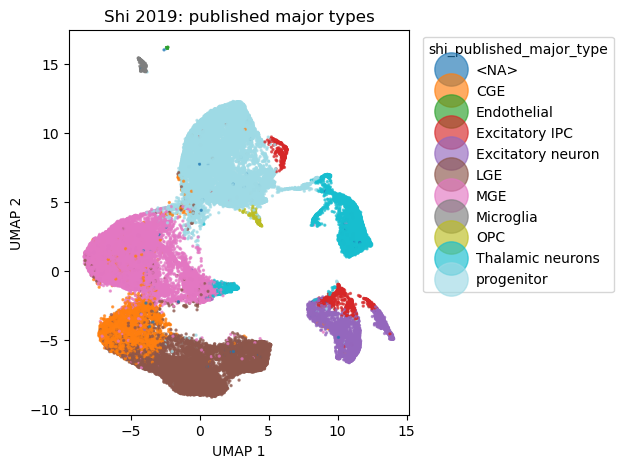

In [96]:
plot_shi_umap_by_obs("shi_published_major_type", title="Shi 2019: published major types", s=2, alpha=0.65)
plt.show()

### Recreate Shi Major Cell-Class UMAP

This is the first target published-style panel: the Shi UMAP colored by the major cell classes from Table S2. Labels are cleaned by stripping leading spaces, but the original Table S2 labels remain in `shi_s2`.

In [97]:
shi_major_type_order = [
    "MGE",
    "LGE",
    "CGE",
    "progenitor",
    "Thalamic neurons",
    "Excitatory neuron",
    "Excitatory IPC",
    "OPC",
    "Microglia",
    "Endothelial",
    "<unassigned>",
]

shi_major_type_palette = {
    "MGE": "#1f77b4",
    "LGE": "#ff7f0e",
    "CGE": "#2ca02c",
    "progenitor": "#9467bd",
    "Thalamic neurons": "#8c564b",
    "Excitatory neuron": "#d62728",
    "Excitatory IPC": "#e377c2",
    "OPC": "#17becf",
    "Microglia": "#7f7f7f",
    "Endothelial": "#bcbd22",
    "<unassigned>": "#d9d9d9",
}

shi.obs["shi_major_type_plot"] = (
    shi.obs["shi_published_major_type"]
    .astype("string")
    .fillna("<unassigned>")
)
shi.obs["shi_major_type_plot"] = pd.Categorical(
    shi.obs["shi_major_type_plot"],
    categories=[label for label in shi_major_type_order if label in set(shi.obs["shi_major_type_plot"].astype(str))],
    ordered=True,
)

shi_major_type_counts = (
    shi.obs["shi_major_type_plot"]
    .astype("string")
    .value_counts()
    .rename_axis("major_cell_class")
    .reset_index(name="n_cells")
)
shi_major_type_counts["fraction"] = shi_major_type_counts["n_cells"] / shi.n_obs
shi_major_type_counts

,major_cell_class,n_cells,fraction
0,MGE,15335,0.273176
1,progenitor,12095,0.215459
2,LGE,11780,0.209848
3,CGE,7126,0.126942
4,Thalamic neurons,4400,0.078381
5,Excitatory neuron,3779,0.067319
6,Excitatory IPC,1085,0.019328
7,Microglia,240,0.004275
8,OPC,165,0.002939
9,<unassigned>,92,0.001639


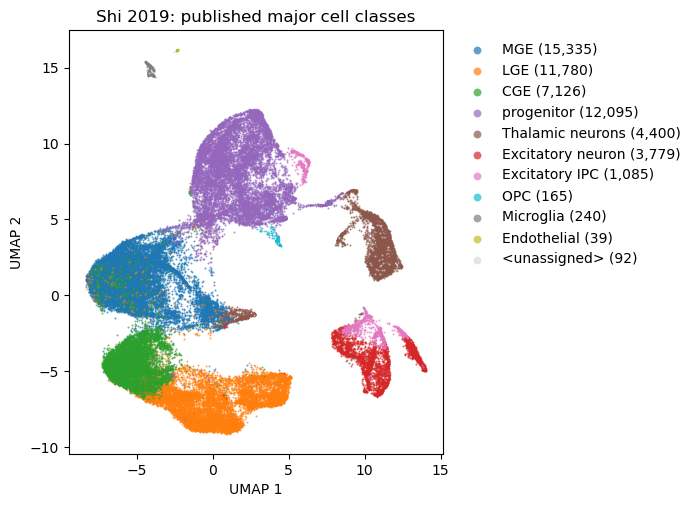

In [98]:
def plot_shi_major_type_umap(s=2, alpha=0.7):
    umap = shi.obsm["X_umap"]
    labels = shi.obs["shi_major_type_plot"].astype("string").fillna("<unassigned>")
    present_labels = [label for label in shi_major_type_order if label in set(labels)]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    for label in present_labels:
        mask = labels.eq(label).to_numpy()
        ax.scatter(
            umap[mask, 0],
            umap[mask, 1],
            s=s,
            alpha=alpha,
            c=shi_major_type_palette.get(label, "#333333"),
            label=f"{label} ({mask.sum():,})",
            linewidths=0,
        )
    ax.set_title("Shi 2019: published major cell classes")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, markerscale=4)
    return fig, ax

plot_shi_major_type_umap()
plt.show()

### Major Cell-Class Composition By Sample

This table supports the next figure style: how each major cell class is distributed across the 9 Shi samples.

In [99]:
shi_major_type_by_sample_counts = pd.crosstab(
    shi.obs["shi_major_type_plot"].astype("string"),
    shi.obs[shi_sample_col].astype("string"),
).reindex(index=[label for label in shi_major_type_order if label in set(shi.obs["shi_major_type_plot"].astype("string"))])

shi_major_type_by_sample_fraction = shi_major_type_by_sample_counts.div(
    shi_major_type_by_sample_counts.sum(axis=1), axis=0
)

shi_major_type_by_sample_counts

shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
shi_major_type_plot,,,,,,,,,
MGE,1564,1310,1518,1947,2110,2002,2165,1309,1410
LGE,1025,1425,1488,1063,1359,523,1008,2726,1163
CGE,86,477,463,532,1317,1439,1788,943,81
progenitor,1112,1333,2693,1828,713,647,1005,1053,1711
Thalamic neurons,205,1086,3108,0,1,0,0,0,0
Excitatory neuron,916,831,1020,3,553,107,1,305,43
Excitatory IPC,313,172,370,2,68,32,2,123,3
OPC,6,35,26,17,40,13,2,18,8
Microglia,17,27,71,22,14,53,0,27,9


In [100]:
shi_major_type_by_sample_fraction.round(3)

shi_sample_id,GW09,GW12_01,GW12_02,GW13,GW16,GW18_01,GW18_02_CGE,GW18_02_LGE,GW18_02_MGE
shi_major_type_plot,,,,,,,,,
MGE,0.102,0.085,0.099,0.127,0.138,0.131,0.141,0.085,0.092
LGE,0.087,0.121,0.126,0.090,0.115,0.044,0.086,0.231,0.099
CGE,0.012,0.067,0.065,0.075,0.185,0.202,0.251,0.132,0.011
progenitor,0.092,0.110,0.223,0.151,0.059,0.053,0.083,0.087,0.141
Thalamic neurons,0.047,0.247,0.706,0.000,0.000,0.000,0.000,0.000,0.000
Excitatory neuron,0.242,0.220,0.270,0.001,0.146,0.028,0.000,0.081,0.011
Excitatory IPC,0.288,0.159,0.341,0.002,0.063,0.029,0.002,0.113,0.003
OPC,0.036,0.212,0.158,0.103,0.242,0.079,0.012,0.109,0.048
Microglia,0.071,0.112,0.296,0.092,0.058,0.221,0.000,0.112,0.038


### Shi UMAP Reproduction Panels

These use the original UMAP coordinates from the converted Seurat object.

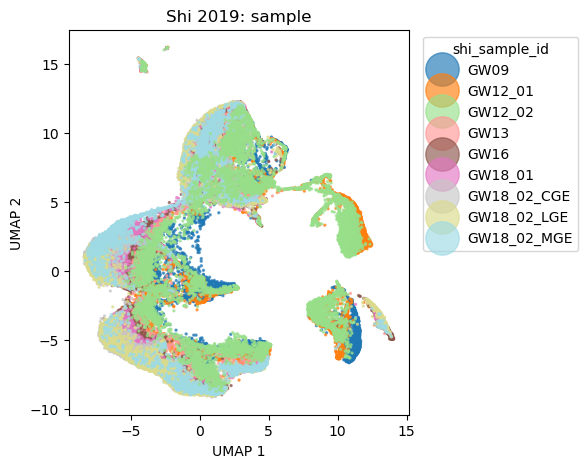

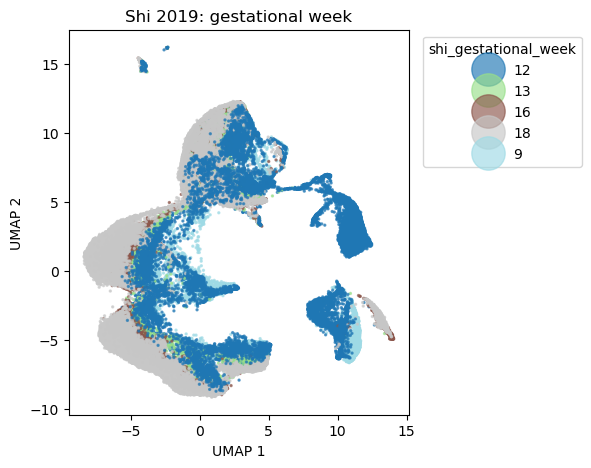

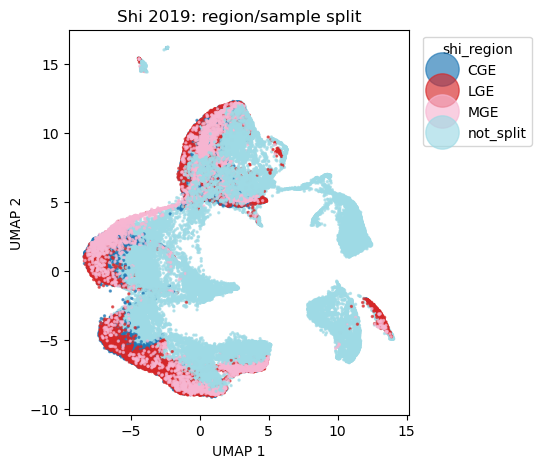

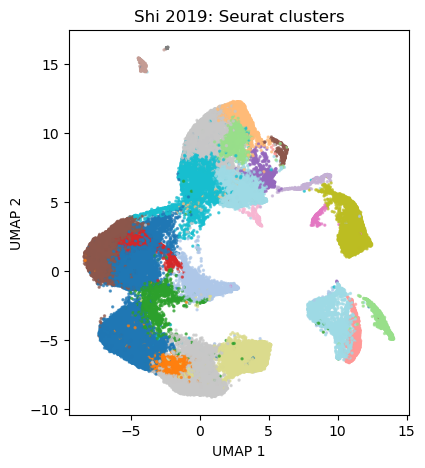

In [101]:
plot_shi_umap_by_obs(shi_sample_col, title="Shi 2019: sample")
plot_shi_umap_by_obs(shi_week_col, title="Shi 2019: gestational week")
plot_shi_umap_by_obs(shi_region_col, title="Shi 2019: region/sample split")
plot_shi_umap_by_obs(shi_cluster_col, title="Shi 2019: Seurat clusters", legend=False)
plt.show()


### Shi Marker Gene Panels

Candidate marker sets for early reproduction. These are starting points for matching published panels; refine the list once we anchor to the exact Shi figure panels and any published cluster annotations.

In [102]:
shi_marker_sets = {
    "regional_identity": ["FOXG1", "NKX2-1", "DLX1", "DLX2", "LHX6", "LHX8"],
    "gabaergic_neuron": ["GAD1", "GAD2", "SLC32A1", "DCX", "STMN2"],
    "progenitor_cell_cycle": ["SOX2", "VIM", "MKI67", "TOP2A", "EOMES"],
    "interneuron_subtype_candidates": ["SST", "NPY", "PVALB", "CRABP1", "ERBB4", "CXCR4"],
}

available_shi_markers = []
missing_shi_markers = []
lookup = gene_lookup(shi)
for group, genes in shi_marker_sets.items():
    for gene in genes:
        if gene.upper() in lookup:
            available_shi_markers.append({"group": group, "gene": gene, "resolved_gene": lookup[gene.upper()]})
        else:
            missing_shi_markers.append({"group": group, "gene": gene})

available_shi_markers_df = pd.DataFrame(available_shi_markers)
missing_shi_markers_df = pd.DataFrame(missing_shi_markers)

display(available_shi_markers_df)
display(missing_shi_markers_df)

,group,gene,resolved_gene
0,regional_identity,FOXG1,FOXG1
1,regional_identity,NKX2-1,NKX2-1
2,regional_identity,DLX1,DLX1
3,regional_identity,DLX2,DLX2
4,regional_identity,LHX6,LHX6
5,regional_identity,LHX8,LHX8
6,gabaergic_neuron,GAD1,GAD1
7,gabaergic_neuron,GAD2,GAD2
8,gabaergic_neuron,SLC32A1,SLC32A1
9,gabaergic_neuron,DCX,DCX


""


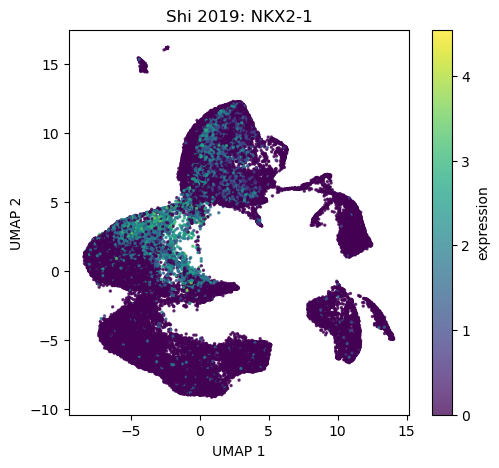

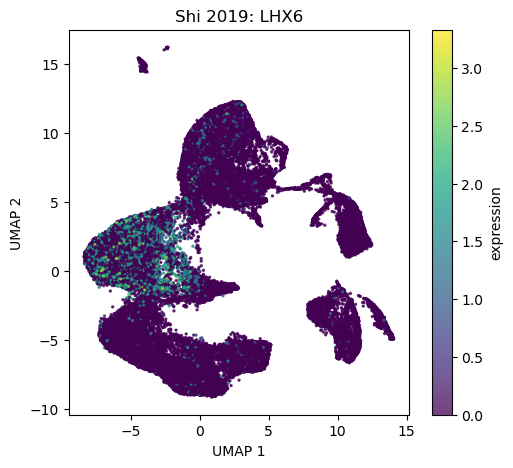

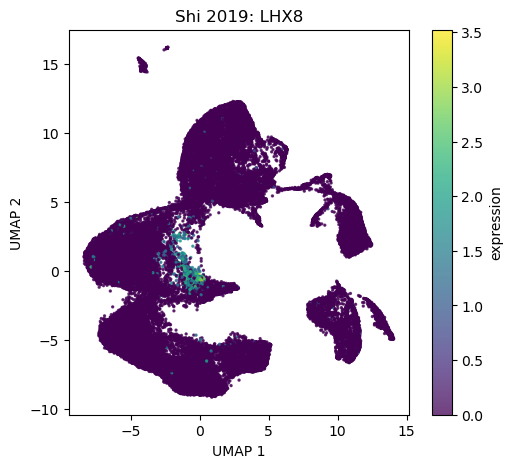

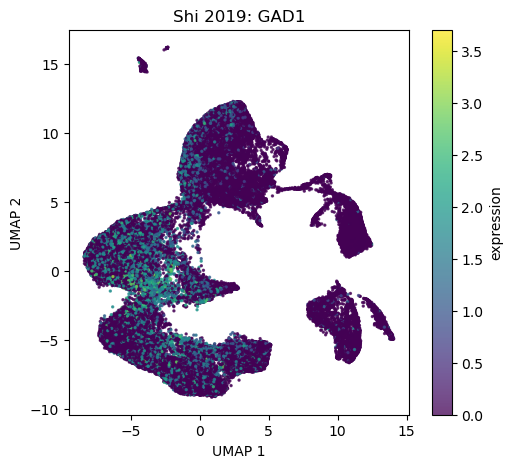

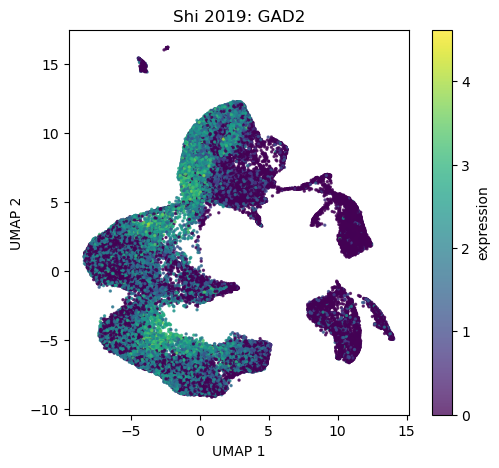

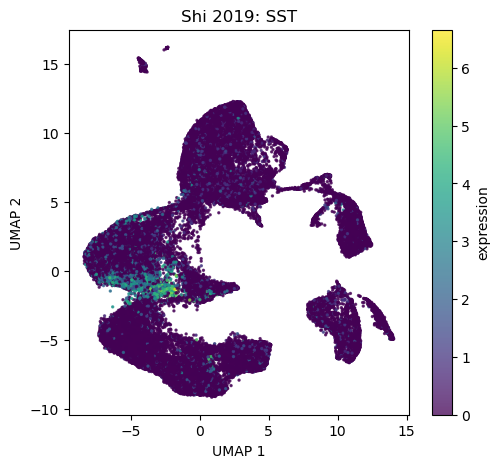

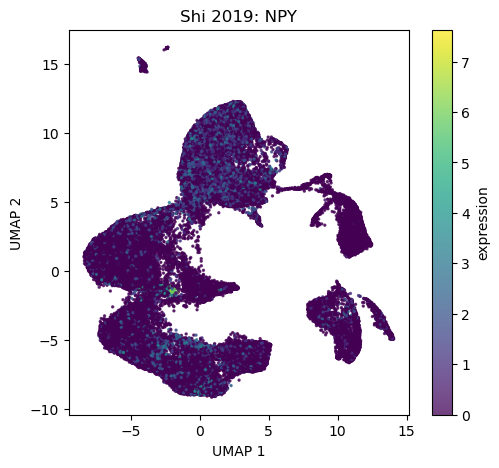

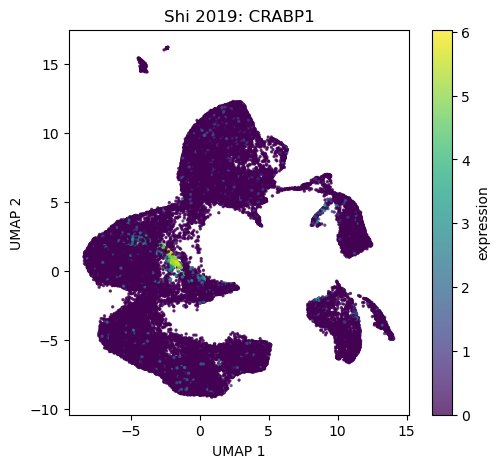

In [103]:
# Start with a small marker set so plots render quickly.
for gene in ["NKX2-1", "LHX6", "LHX8", "GAD1", "GAD2", "SST", "NPY", "CRABP1"]:
    if gene.upper() in gene_lookup(shi):
        plot_shi_gene_umap(gene)
plt.show()

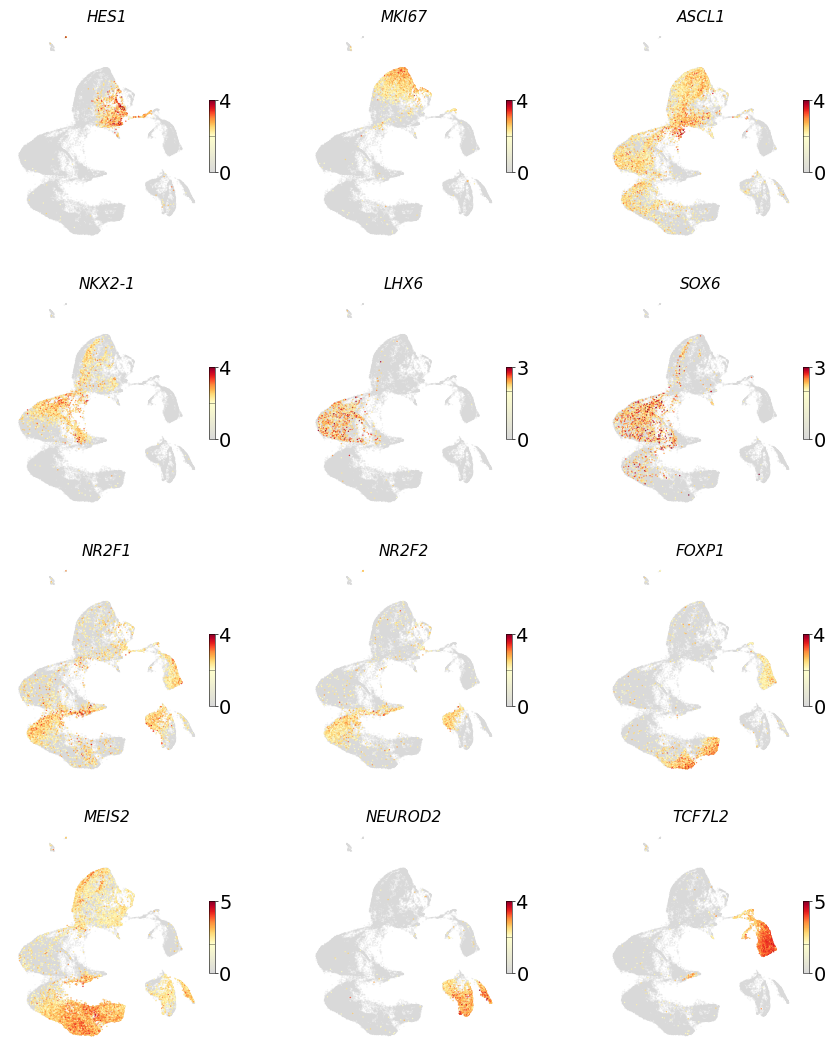

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import sparse
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


genes_to_plot = [
    "HES1", "MKI67", "ASCL1",
    "NKX2-1", "LHX6", "SOX6",
    "NR2F1", "NR2F2", "FOXP1",
    "MEIS2", "NEUROD2", "TCF7L2",
]


# This is the visual lower bound for colored expression.
# Increase it to suppress more weak log-normalized signal.
# Decrease it to show more low-level expression.
feature_vmin_expression = 2.0


def get_gene_expression(adata, gene):
    """Return expression vector for one gene from AnnData."""
    gene_lookup = {str(g).upper(): str(g) for g in adata.var_names}
    resolved_gene = gene_lookup.get(gene.upper())

    if resolved_gene is None:
        raise KeyError(f"{gene} not found in adata.var_names")

    x = adata[:, resolved_gene].X
    if sparse.issparse(x):
        x = x.toarray()

    return np.asarray(x).reshape(-1), resolved_gene


def rounded_vmax(expr, percentile=99, minimum=1):
    """Compute percentile-based vmax and round up to a whole number."""
    finite_expr = expr[np.isfinite(expr)]
    positive_expr = finite_expr[finite_expr > 0]

    if positive_expr.size == 0:
        return float(minimum)

    vmax = np.percentile(positive_expr, percentile)
    vmax = np.ceil(vmax)

    if vmax < minimum:
        vmax = minimum

    return float(vmax)


def make_thresholded_colorbar_cmap(
    expression_cmap,
    background_color="#d9d9d9",
    n_colors=256,
    gray_fraction=0.18,
):
    """
    Build a smooth colorbar colormap matching thresholded feature plotting.

    The UMAP treats values below vmin_expression as gray background. The
    colorbar begins gray and smoothly transitions into the expression colormap.
    """
    background_rgba = mpl.colors.to_rgba(background_color)
    colors = []

    gray_fraction = min(max(gray_fraction, 0.0), 0.95)

    for i in range(n_colors):
        t = i / (n_colors - 1)

        if t < gray_fraction and gray_fraction > 0:
            local_t = t / gray_fraction
            expr_color = expression_cmap(0.0)
            color = tuple(
                (1 - local_t) * background_rgba[j] + local_t * expr_color[j]
                for j in range(4)
            )
        else:
            if gray_fraction < 1:
                expr_t = (t - gray_fraction) / (1 - gray_fraction)
            else:
                expr_t = 1.0
            expr_t = min(max(expr_t, 0.0), 1.0)
            color = expression_cmap(expr_t)

        colors.append(color)

    return mpl.colors.ListedColormap(colors)


def plot_umap_feature_grid(
    adata,
    genes,
    umap_key="X_umap",
    ncols=3,
    vmax_percentile=99,
    vmin_expression=2.0,
    cmap="YlOrRd",
    background_color="#d9d9d9",
    point_size_background=0.8,
    point_size_expression=1.0,
    background_alpha=0.35,
    expression_alpha=0.9,
    figsize_per_panel=(3.0, 2.8),
    colorbar_height="33%",
    colorbar_width="3%",
    colorbar_labelsize=14,
    show_threshold_line=True,
):
    """
    Publication-style multi-panel UMAP feature plot.

    `vmin_expression` is a VISUALIZATION threshold only. It does not modify the
    expression matrix. Cells below this threshold stay gray.
    """
    if umap_key not in adata.obsm:
        raise KeyError(f'adata.obsm["{umap_key}"] not found')

    if vmin_expression < 0:
        raise ValueError("vmin_expression must be >= 0")

    umap = adata.obsm[umap_key]
    n_genes = len(genes)
    nrows = int(np.ceil(n_genes / ncols))
    expression_cmap = plt.get_cmap(cmap)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        facecolor="white",
        constrained_layout=False,
    )

    axes = np.asarray(axes).reshape(-1)

    for ax in axes[n_genes:]:
        ax.axis("off")

    for ax, gene in zip(axes, genes):
        expr, resolved_gene = get_gene_expression(adata, gene)

        vmax = rounded_vmax(
            expr,
            percentile=vmax_percentile,
            minimum=max(1, vmin_expression),
        )

        if vmax <= vmin_expression:
            vmax = float(np.ceil(vmin_expression + 1))

        expression_norm = mpl.colors.Normalize(vmin=vmin_expression, vmax=vmax)

        ax.scatter(
            umap[:, 0],
            umap[:, 1],
            s=point_size_background,
            c=background_color,
            alpha=background_alpha,
            linewidths=0,
            edgecolors="none",
            rasterized=True,
        )

        expressing = expr >= vmin_expression

        if expressing.any():
            ax.scatter(
                umap[expressing, 0],
                umap[expressing, 1],
                s=point_size_expression,
                c=expr[expressing],
                cmap=expression_cmap,
                norm=expression_norm,
                alpha=expression_alpha,
                linewidths=0,
                edgecolors="none",
                rasterized=True,
            )

        ax.set_title(
            resolved_gene.upper(),
            fontstyle="italic",
            fontweight="normal",
            fontsize=11,
            pad=4,
        )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

        threshold_fraction = min(max(vmin_expression / vmax, 0.0), 0.95)

        colorbar_cmap = make_thresholded_colorbar_cmap(
            expression_cmap,
            background_color=background_color,
            gray_fraction=threshold_fraction,
        )

        colorbar_norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
        sm = mpl.cm.ScalarMappable(norm=colorbar_norm, cmap=colorbar_cmap)
        sm.set_array([])

        cax = inset_axes(
            ax,
            width=colorbar_width,
            height=colorbar_height,
            loc="center right",
            bbox_to_anchor=(0.06, 0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )

        cbar = fig.colorbar(
            sm,
            cax=cax,
            orientation="vertical",
        )

        cbar.set_ticks([0, vmax])
        cbar.set_ticklabels(["0", f"{int(vmax)}"])
        cbar.ax.tick_params(
            labelsize=colorbar_labelsize,
            length=2,
            width=0.5,
            pad=1,
        )
        cbar.outline.set_linewidth(0.4)

        if show_threshold_line:
            cbar.ax.axhline(
                vmin_expression,
                color="black",
                linewidth=0.4,
                alpha=0.6,
            )

    fig.subplots_adjust(
        left=0.02,
        right=0.96,
        top=0.94,
        bottom=0.03,
        wspace=0.18,
        hspace=0.22,
    )

    return fig, axes


shi = adatas["shi_2019_paper_qc"]

fig, axes = plot_umap_feature_grid(
    shi,
    genes_to_plot,
    umap_key="X_umap",
    ncols=3,
    vmax_percentile=99,
    vmin_expression=feature_vmin_expression,
    cmap="YlOrRd",
    point_size_background=0.8,
    point_size_expression=1.0,
    background_alpha=0.35,
    expression_alpha=0.9,
    figsize_per_panel=(3.0, 2.8),
    colorbar_height="33%",
    colorbar_width="3%",
    colorbar_labelsize=14,
    show_threshold_line=True,
)

plt.show()

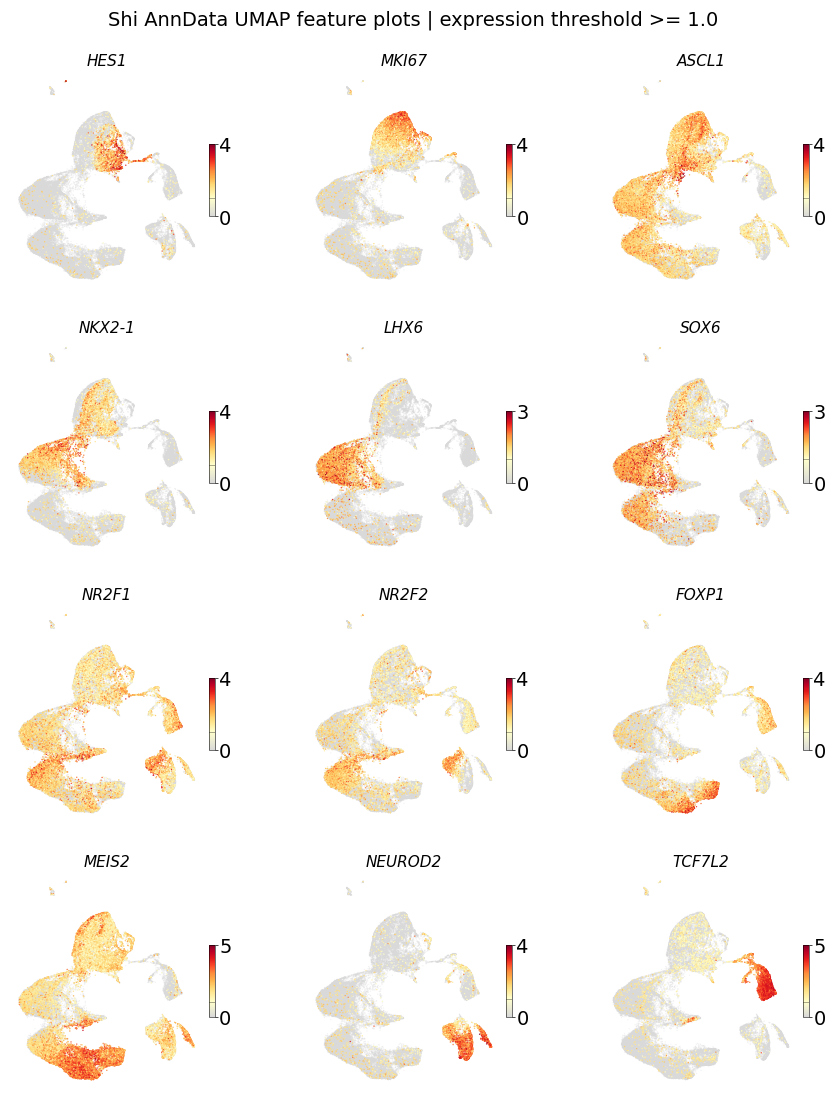

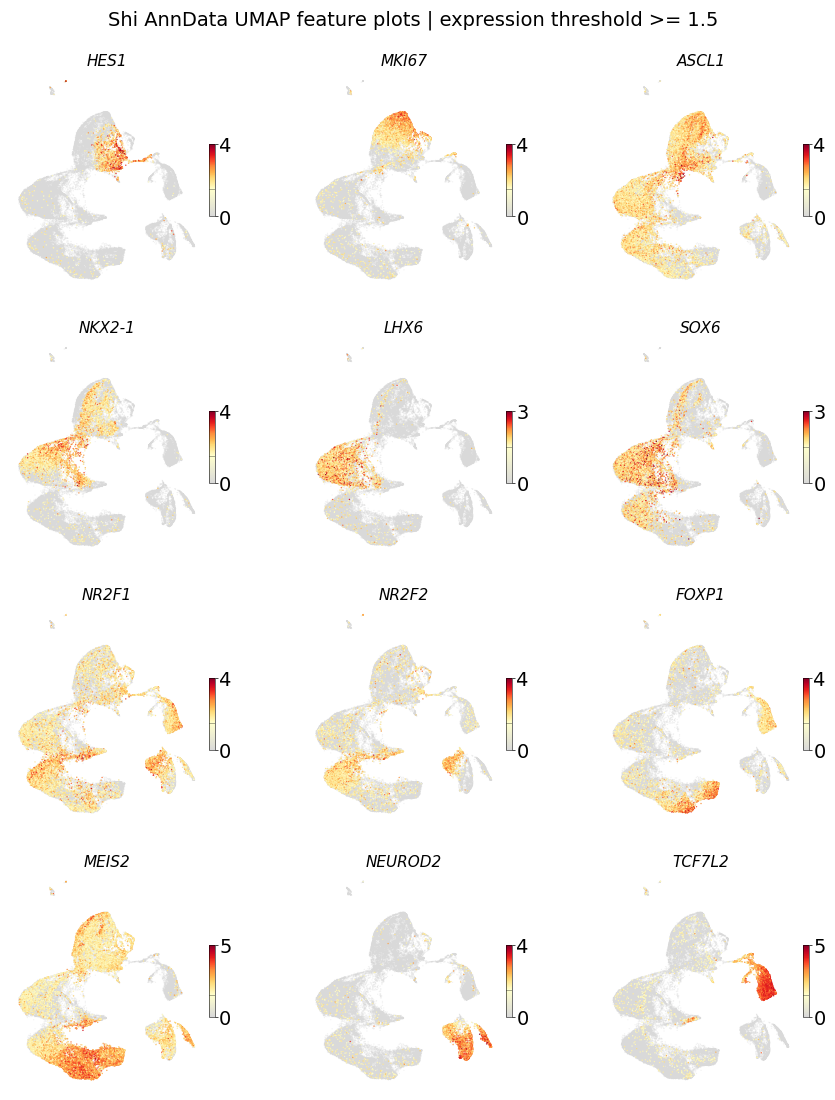

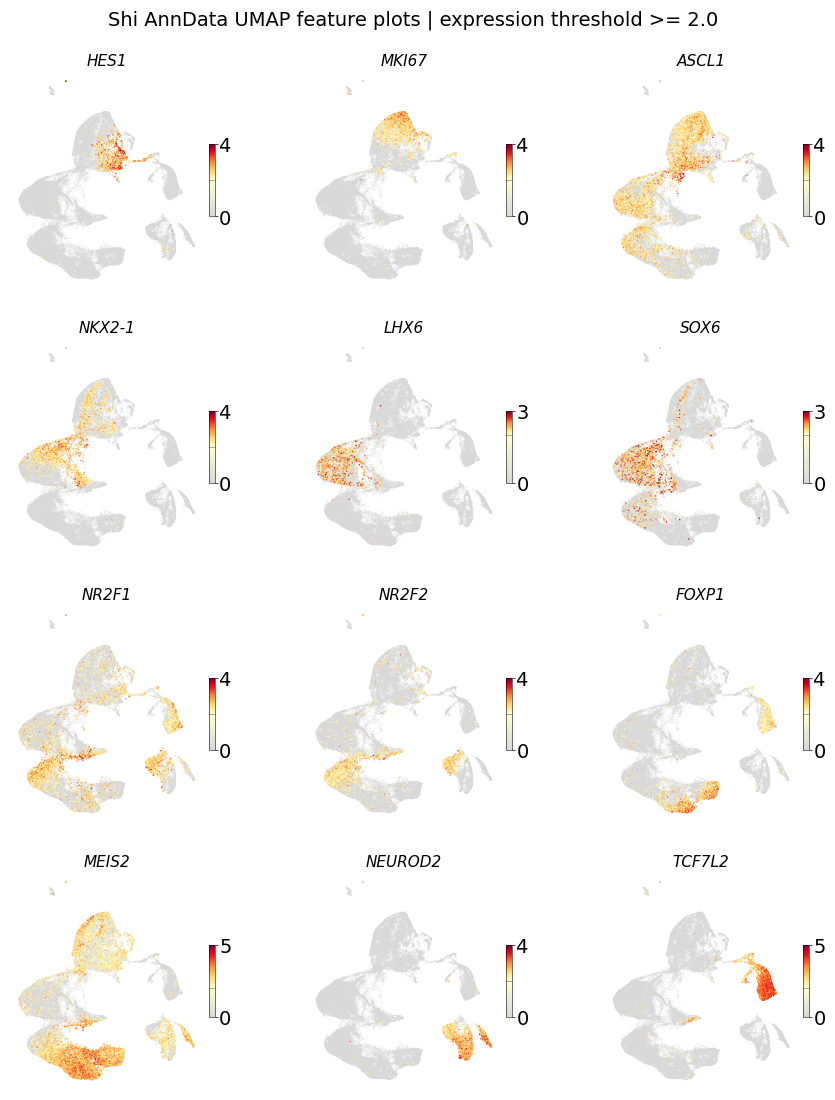

In [105]:
for threshold in [1.0, 1.5, 2.0]:
    fig, axes = plot_umap_feature_grid(
        shi,
        genes_to_plot,
        umap_key="X_umap",
        ncols=3,
        vmax_percentile=99,
        vmin_expression=threshold,
        cmap="YlOrRd",
        point_size_background=0.8,
        point_size_expression=1.0,
        background_alpha=0.35,
        expression_alpha=0.9,
        figsize_per_panel=(3.0, 2.8),
        colorbar_height="33%",
        colorbar_width="3%",
        colorbar_labelsize=14,
        show_threshold_line=True,
    )

    fig.suptitle(
        f"Shi AnnData UMAP feature plots | expression threshold >= {threshold}",
        fontsize=14,
        y=0.995,
    )

    plt.show()

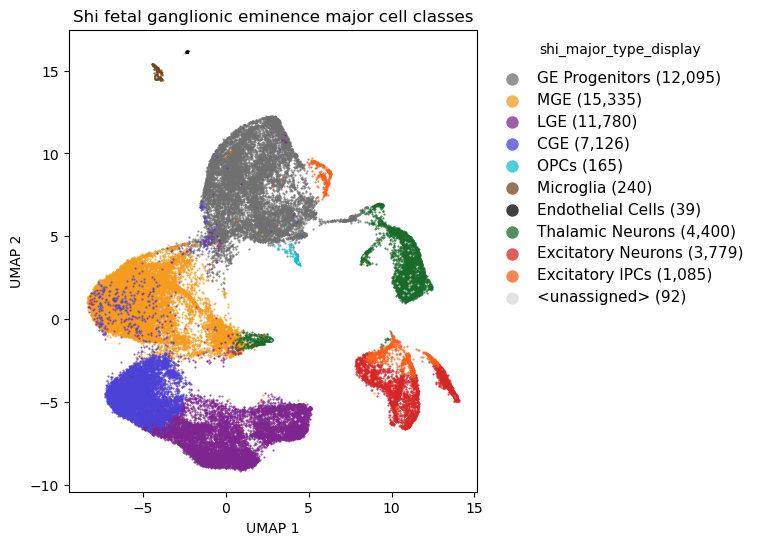

,display_label,color,n_cells
0,GE Progenitors,#707070,12095
1,MGE,#f59b1e,15335
2,LGE,#7F258F,11780
3,CGE,#4c42d8,7126
4,OPCs,#17becf,165
5,Microglia,#74461c,240
6,Endothelial Cells,#000000,39
7,Thalamic Neurons,#196b29,4400
8,Excitatory Neurons,#d62728,3779
9,Excitatory IPCs,#ff5e18,1085


,mapping_status,n_cells
0,mapped_unique,56044
1,ambiguous_duplicate_barcode,92


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def add_shi_major_type_from_table_s2(adata, shi_s2):
    """
    Add published Shi major cell type labels from Table S2 into AnnData.obs.

    Uses Table S2 Cells like AAAC...-1 and maps them to AnnData IDs like
    AAAC...-GW09. Ambiguous duplicated GW12_02 barcodes are left unassigned.
    """

    out = adata

    suffix_to_sample = {
        "1": "GW09",
        "2": "GW12_01",
        "3": "GW13",
        "4": "GW16",
        "5": "GW18_01",
        "6": "GW18_02_CGE",
        "7": "GW18_02_LGE",
        "8": "GW18_02_MGE",
        "9": "GW12_02",
        "10": "GW12_02",
        "11": "GW12_02",
    }

    mapped = shi_s2.copy()

    mapped["barcode"] = (
        mapped["Cells"]
        .astype("string")
        .str.replace(r"-\d+$", "", regex=True)
    )

    mapped["s2_suffix"] = (
        mapped["Cells"]
        .astype("string")
        .str.extract(r"-(\d+)$")[0]
    )

    mapped["shi_sample_id"] = mapped["s2_suffix"].map(suffix_to_sample)

    mapped["candidate_cell_id"] = (
        mapped["barcode"] + "-" + mapped["shi_sample_id"]
    )

    mapped["published_major_type_clean"] = (
        mapped["Major types"]
        .astype("string")
        .str.strip()
    )

    candidate_counts = mapped["candidate_cell_id"].value_counts(dropna=False)

    mapped["candidate_is_unique"] = (
        mapped["candidate_cell_id"]
        .map(candidate_counts)
        .eq(1)
    )

    mapped["candidate_in_adata"] = (
        mapped["candidate_cell_id"]
        .isin(set(out.obs_names.astype(str)))
    )

    safe_major_type_map = (
        mapped.loc[
            mapped["candidate_is_unique"]
            & mapped["candidate_in_adata"]
        ]
        .set_index("candidate_cell_id")["published_major_type_clean"]
    )

    out.obs["shi_published_major_type"] = (
        pd.Series(
            out.obs_names.astype("string"),
            index=out.obs_names,
        )
        .map(safe_major_type_map)
        .astype("category")
    )

    out.obs["shi_published_major_type_status"] = "unmapped"

    out.obs.loc[
        out.obs["shi_published_major_type"].notna(),
        "shi_published_major_type_status",
    ] = "mapped_unique"

    if "has_duplicated_raw_cell_id" in out.obs:

        out.obs.loc[
            out.obs["has_duplicated_raw_cell_id"]
            .astype("string")
            .eq("TRUE"),
            "shi_published_major_type_status",
        ] = "ambiguous_duplicate_barcode"

    out.obs["shi_published_major_type_status"] = (
        out.obs["shi_published_major_type_status"]
        .astype("category")
    )

    return out, mapped


def add_shi_major_type_display_labels(adata):
    """
    Add cleaner publication-style display labels while preserving
    original Table S2 labels.
    """

    display_names = {
        "progenitor": "GE Progenitors",
        "MGE": "MGE",
        "LGE": "LGE",
        "CGE": "CGE",
        "OPC": "OPCs",
        "Microglia": "Microglia",
        "Endothelial": "Endothelial Cells",
        "Thalamic neurons": "Thalamic Neurons",
        "Excitatory neuron": "Excitatory Neurons",
        "Excitatory IPC": "Excitatory IPCs",
        "<unassigned>": "<unassigned>",
    }

    out = adata

    out.obs["shi_major_type_plot"] = (
        out.obs["shi_published_major_type"]
        .astype("string")
        .fillna("<unassigned>")
    )

    out.obs["shi_major_type_display"] = (
        out.obs["shi_major_type_plot"]
        .map(display_names)
        .fillna(out.obs["shi_major_type_plot"])
    )

    return out


# ------------------------------------------------------------------
# Load Shi AnnData
# ------------------------------------------------------------------

shi = adatas["shi_2019_paper_qc"]


# ------------------------------------------------------------------
# Load Table S2
# ------------------------------------------------------------------

shi_table_s2_path = (
    project_root
    / "reference"
    / "shi_2021_tables_s2_to_s9"
    / "science.abj6641_table_s2.xlsx"
)

shi_s2 = pd.read_excel(
    shi_table_s2_path,
    sheet_name="UMAP coordinates",
    header=1,
)


# ------------------------------------------------------------------
# Add published major type labels
# ------------------------------------------------------------------

shi, shi_s2_mapped = add_shi_major_type_from_table_s2(
    shi,
    shi_s2,
)

shi = add_shi_major_type_display_labels(shi)


# ------------------------------------------------------------------
# Plot ordering
# ------------------------------------------------------------------

major_type_display_order = [
    "GE Progenitors",
    "MGE",
    "LGE",
    "CGE",
    "OPCs",
    "Microglia",
    "Endothelial Cells",
    "Thalamic Neurons",
    "Excitatory Neurons",
    "Excitatory IPCs",
    "<unassigned>",
]


# ------------------------------------------------------------------
# Publication-style colors
# ------------------------------------------------------------------

major_type_display_colors = {
    "GE Progenitors": "#707070",
    "MGE": "#f59b1e",
    "LGE": "#7F258F",
    "CGE": "#4c42d8",
    "OPCs": "#17becf",
    "Microglia": "#74461c",
    "Endothelial Cells": "#000000",
    "Thalamic Neurons": "#196b29",
    "Excitatory Neurons": "#d62728",
    "Excitatory IPCs": "#ff5e18",
    "<unassigned>": "#d9d9d9",
}


# ------------------------------------------------------------------
# Set ordered categories
# ------------------------------------------------------------------

shi.obs["shi_major_type_display"] = pd.Categorical(
    shi.obs["shi_major_type_display"],
    categories=[
        label
        for label in major_type_display_order
        if label in set(
            shi.obs["shi_major_type_display"].astype(str)
        )
    ],
    ordered=True,
)


# ------------------------------------------------------------------
# Plot UMAP
# ------------------------------------------------------------------

fig, ax = plot_adata_umap_by_category(
    shi,
    category="shi_major_type_display",
    color_map=major_type_display_colors,
    order=major_type_display_order,

    # Cleaner title
    title="Shi fetal ganglionic eminence major cell classes",

    # Slightly larger points
    s=2.5,

    # Slight transparency
    alpha=0.75,

    # Wider figure
    figsize=(11, 6),
)


# ------------------------------------------------------------------
# Improve legend aesthetics
# ------------------------------------------------------------------

legend = ax.get_legend()

if legend is not None:

    # Increase spacing between legend entries
    legend._legend_box.sep = 10

    # Make legend markers larger
    for handle in legend.legend_handles:

        try:
            handle.set_sizes([80])

        except Exception:
            pass

    # Slightly larger legend text
    for text in legend.get_texts():
        text.set_fontsize(11)

    # Move legend higher and farther right
    legend.set_bbox_to_anchor((1.02, 1.0))
    legend.set_loc("upper left")


plt.show()


# ------------------------------------------------------------------
# QC tables
# ------------------------------------------------------------------

major_type_color_check = pd.DataFrame(
    {
        "display_label": major_type_display_order,
        "color": [
            major_type_display_colors[label]
            for label in major_type_display_order
        ],
        "n_cells": [
            int(
                (
                    shi.obs["shi_major_type_display"]
                    .astype("string")
                    == label
                ).sum()
            )
            for label in major_type_display_order
        ],
    }
)

mapping_status_check = (
    shi.obs["shi_published_major_type_status"]
    .astype("string")
    .value_counts()
    .rename_axis("mapping_status")
    .reset_index(name="n_cells")
)

display(major_type_color_check)
display(mapping_status_check)

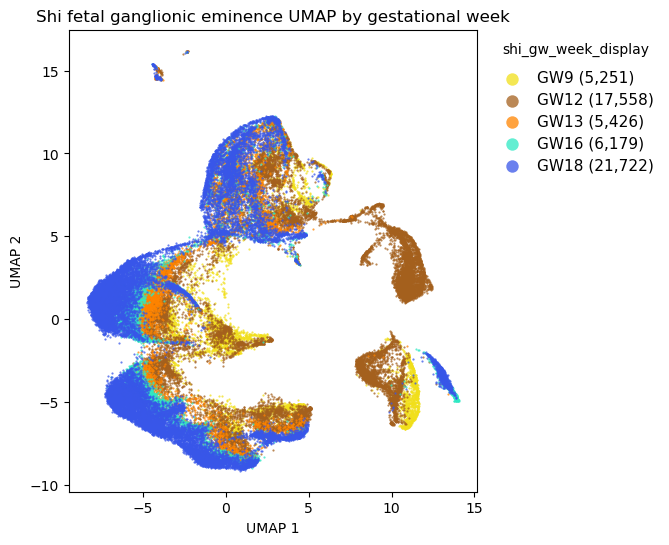

,display_label,color,n_cells
0,GW9,#f1df1a,5251
1,GW12,#a4601d,17558
2,GW13,#ff8400,5426
3,GW16,#2FE9C4,6179
4,GW18,#3856e9,21722


In [115]:
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Add GW week labels
# ------------------------------------------------------------------

shi.obs["shi_gw_week"] = (
    shi.obs_names
    .astype("string")
    .str.extract(r"-(GW\d+)", expand=False)
)

# Collapse sample-specific IDs into week-level labels
shi.obs["shi_gw_week"] = (
    shi.obs["shi_gw_week"]
    .astype("string")
    .str.replace(r"_.*$", "", regex=True)
)

gw_week_order = [
    "GW09",
    "GW12",
    "GW13",
    "GW16",
    "GW18",
]

gw_week_display_names = {
    "GW09": "GW9",
    "GW12": "GW12",
    "GW13": "GW13",
    "GW16": "GW16",
    "GW18": "GW18",
}

shi.obs["shi_gw_week_display"] = (
    shi.obs["shi_gw_week"]
    .map(gw_week_display_names)
    .fillna(shi.obs["shi_gw_week"])
)

gw_week_display_order = [
    "GW9",
    "GW12",
    "GW13",
    "GW16",
    "GW18",
]

gw_week_colors = {
    "GW9": "#f1df1a",
    "GW12": "#a4601d",
    "GW13": "#ff8400",
    "GW16": "#2FE9C4",
    "GW18": "#3856e9",
}

shi.obs["shi_gw_week_display"] = pd.Categorical(
    shi.obs["shi_gw_week_display"],
    categories=[
        label
        for label in gw_week_display_order
        if label in set(shi.obs["shi_gw_week_display"].astype(str))
    ],
    ordered=True,
)


# ------------------------------------------------------------------
# Plot UMAP by GW week
# ------------------------------------------------------------------

fig, ax = plot_adata_umap_by_category(
    shi,
    category="shi_gw_week_display",
    color_map=gw_week_colors,
    order=gw_week_display_order,
    title="Shi fetal ganglionic eminence UMAP by gestational week",
    s=2.5,
    alpha=0.75,
    figsize=(11, 6),
)


# ------------------------------------------------------------------
# Improve legend aesthetics
# ------------------------------------------------------------------

legend = ax.get_legend()

if legend is not None:

    legend._legend_box.sep = 10

    for handle in legend.legend_handles:
        try:
            handle.set_sizes([80])
        except Exception:
            pass

    for text in legend.get_texts():
        text.set_fontsize(11)

    legend.set_bbox_to_anchor((1.02, 1.0))
    legend.set_loc("upper left")


plt.show()


# ------------------------------------------------------------------
# QC table
# ------------------------------------------------------------------

gw_week_color_check = pd.DataFrame(
    {
        "display_label": gw_week_display_order,
        "color": [
            gw_week_colors[label]
            for label in gw_week_display_order
        ],
        "n_cells": [
            int(
                (
                    shi.obs["shi_gw_week_display"]
                    .astype("string")
                    == label
                ).sum()
            )
            for label in gw_week_display_order
        ],
    }
)

display(gw_week_color_check)

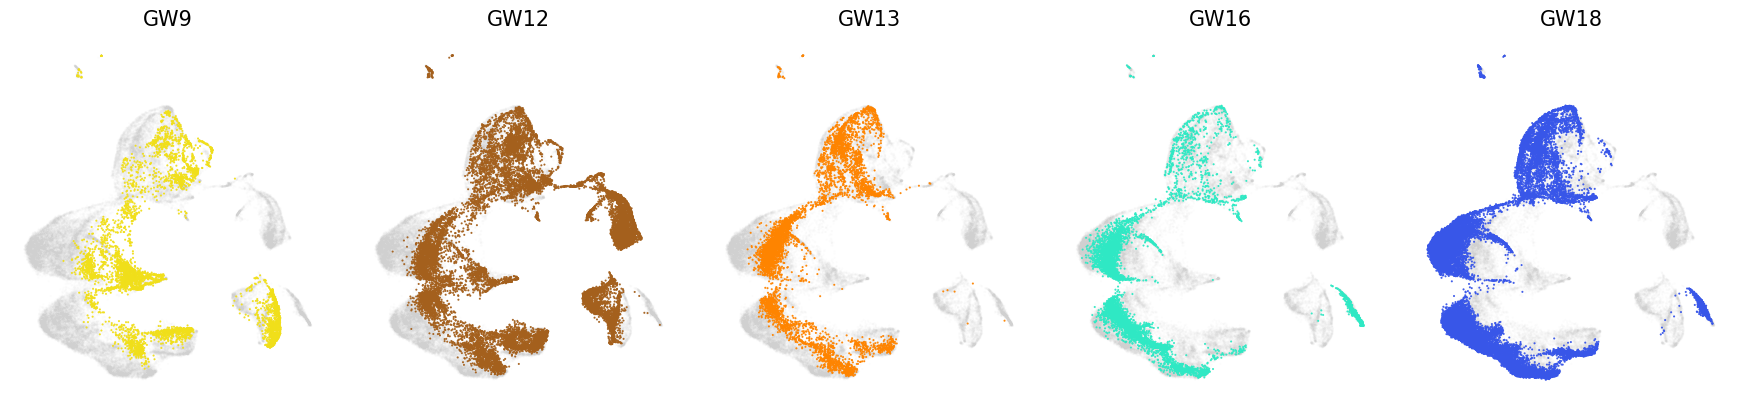

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Publication-style GW subplot UMAPs
# ------------------------------------------------------------------

def plot_gw_week_umap_subplots(
    adata,
    category="shi_gw_week_display",
    umap_key="X_umap",
    order=None,
    color_map=None,
    ncols=None,
    figsize_per_panel=(3.5, 3.8),
    point_size=2.0,
    alpha_background=0.08,
    alpha_foreground=0.90,
    background_color="#d9d9d9",
    title_fontsize=14,
):
    """
    Create publication-style UMAP subplots for each GW week.

    Each panel:
    - shows all cells in faint gray background
    - highlights one GW week in color
    - preserves identical UMAP coordinates
    - removes axes and clutter
    """

    if umap_key not in adata.obsm:
        raise KeyError(f'adata.obsm["{umap_key}"] not found')

    if category not in adata.obs:
        raise KeyError(f'adata.obs["{category}"] not found')

    labels = adata.obs[category].astype("string")
    umap = adata.obsm[umap_key]

    if order is None:
        order = list(labels.dropna().unique())

    if color_map is None:
        raise ValueError("color_map must be provided")

    n_panels = len(order)

    if ncols is None:
        ncols = n_panels

    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            figsize_per_panel[0] * ncols,
            figsize_per_panel[1] * nrows,
        ),
        facecolor="white",
    )

    axes = np.asarray(axes).reshape(-1)

    for ax in axes[n_panels:]:
        ax.axis("off")

    for ax, label in zip(axes, order):

        mask = labels.eq(label).to_numpy()

        # ----------------------------------------------------------
        # Plot all cells faintly in gray
        # ----------------------------------------------------------

        ax.scatter(
            umap[:, 0],
            umap[:, 1],
            s=point_size,
            c=background_color,
            alpha=alpha_background,
            linewidths=0,
            edgecolors="none",
            rasterized=True,
        )

        # ----------------------------------------------------------
        # Overlay highlighted GW week
        # ----------------------------------------------------------

        ax.scatter(
            umap[mask, 0],
            umap[mask, 1],
            s=point_size,
            c=color_map[label],
            alpha=alpha_foreground,
            linewidths=0,
            edgecolors="none",
            rasterized=True,
        )

        # ----------------------------------------------------------
        # Styling
        # ----------------------------------------------------------

        ax.set_title(
            label,
            fontsize=title_fontsize,
            fontweight="normal",
            pad=10,
        )

        ax.set_aspect("equal", adjustable="box")

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.90,
        bottom=0.05,
        wspace=0.08,
        hspace=0.08,
    )

    return fig, axes


# ------------------------------------------------------------------
# GW colors
# ------------------------------------------------------------------

gw_week_colors = {
    "GW9": "#f1df1a",
    "GW12": "#a4601d",
    "GW13": "#ff8400",
    "GW16": "#2FE9C4",
    "GW18": "#3856e9",
}


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, axes = plot_gw_week_umap_subplots(
    shi,
    category="shi_gw_week_display",
    order=["GW9", "GW12", "GW13", "GW16", "GW18"],
    color_map=gw_week_colors,

    # aesthetics
    figsize_per_panel=(3.6, 4.2),
    point_size=2.2,

    # subtle gray background
    alpha_background=0.05,

    # strong foreground emphasis
    alpha_foreground=0.95,

    background_color="#d0d0d0",

    title_fontsize=15,
)

plt.show()

UMI column used: nCount_RNA
Gene-number column used: nFeature_RNA


,sample,sex,published_filtered_cells,published_mean_genes,observed_cells,observed_mean_genes,observed_mean_umis,cell_count_delta,mean_gene_delta
0,GW09,male,5257,1961,5251,1962.419920,4864.159017,-6,1.419920
1,GW12-01,male,6712,1596,6704,1597.095615,3744.784755,-8,1.095615
2,GW12-02,male,10855,1997,10854,1997.505528,5305.840243,-1,0.505528
3,GW13,male,5455,1439,5426,1442.630483,3532.001474,-29,3.630483
4,GW16,female,6187,1419,6179,1420.768409,3375.965043,-8,1.768409
5,GW18-01,female,4852,1234,4817,1237.918622,2876.344405,-35,3.918622
6,GW18-02-MGE,female,4470,1375,4429,1380.703319,3245.006774,-41,5.703319
7,GW18-02-LGE,female,6570,1252,6504,1256.892374,2799.776753,-66,4.892374
8,GW18-02-CGE,female,6054,1201,5972,1207.264066,2779.407569,-82,6.264066


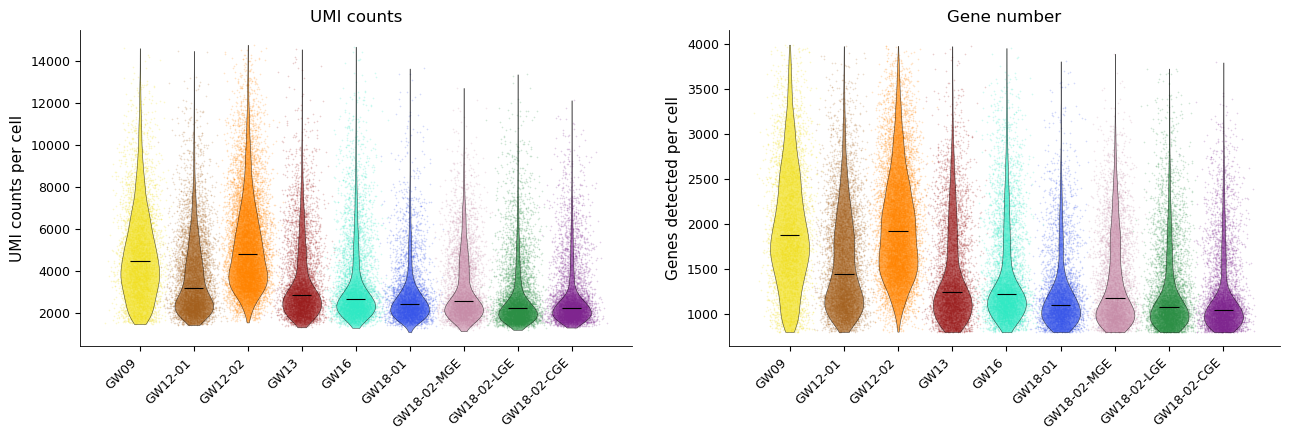

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


shi = adatas["shi_2019_paper_qc"]


shi_sample_order = [
    "GW09",
    "GW12-01",
    "GW12-02",
    "GW13",
    "GW16",
    "GW18-01",
    "GW18-02-MGE",
    "GW18-02-LGE",
    "GW18-02-CGE",
]

shi_sample_colors = {
    "GW09": "#f1df1a",
    "GW12-01": "#a4601d",
    "GW12-02": "#ff8400",
    "GW13": "#9b1d1d",
    "GW16": "#2FE9C4",
    "GW18-01": "#3856e9",
    "GW18-02-MGE": "#c78ca8",
    "GW18-02-LGE": "#2c8f45",
    "GW18-02-CGE": "#7F258F",
}

published_qc = pd.DataFrame(
    [
        {"sample": "GW09", "sex": "male", "published_filtered_cells": 5257, "published_mean_genes": 1961},
        {"sample": "GW12-01", "sex": "male", "published_filtered_cells": 6712, "published_mean_genes": 1596},
        {"sample": "GW12-02", "sex": "male", "published_filtered_cells": 10855, "published_mean_genes": 1997},
        {"sample": "GW13", "sex": "male", "published_filtered_cells": 5455, "published_mean_genes": 1439},
        {"sample": "GW16", "sex": "female", "published_filtered_cells": 6187, "published_mean_genes": 1419},
        {"sample": "GW18-01", "sex": "female", "published_filtered_cells": 4852, "published_mean_genes": 1234},
        {"sample": "GW18-02-MGE", "sex": "female", "published_filtered_cells": 4470, "published_mean_genes": 1375},
        {"sample": "GW18-02-LGE", "sex": "female", "published_filtered_cells": 6570, "published_mean_genes": 1252},
        {"sample": "GW18-02-CGE", "sex": "female", "published_filtered_cells": 6054, "published_mean_genes": 1201},
    ]
)


def infer_shi_sample_id_from_obs_names(adata):
    """
    Infer Shi sample ID from AnnData obs_names.

    AnnData IDs use underscore-style sample suffixes, while the paper uses
    hyphen-style labels. This returns paper-style labels.
    """
    sample = adata.obs_names.astype("string").str.extract(
        r"-(GW09|GW12_01|GW12_02|GW13|GW16|GW18_01|GW18_02_MGE|GW18_02_LGE|GW18_02_CGE)(?:_dup\d+)?$"
    )[0]

    sample = sample.str.replace("_", "-", regex=False)

    return pd.Series(sample.to_numpy(), index=adata.obs_names, name="sample")


def get_qc_metric_columns(adata):
    """
    Resolve QC metric columns.

    UMI counts per cell measure total captured transcript molecules per cell.
    Gene number per cell measures transcriptome complexity, i.e. how many genes
    were detected in that cell.

    Prefer standard Scanpy-style columns if present; otherwise use converted
    Seurat columns.
    """
    if "total_counts" in adata.obs:
        umi_col = "total_counts"
    elif "nCount_RNA" in adata.obs:
        umi_col = "nCount_RNA"
    else:
        raise KeyError("Could not find total_counts or nCount_RNA in adata.obs")

    if "n_genes_by_counts" in adata.obs:
        gene_col = "n_genes_by_counts"
    elif "nFeature_RNA" in adata.obs:
        gene_col = "nFeature_RNA"
    else:
        raise KeyError("Could not find n_genes_by_counts or nFeature_RNA in adata.obs")

    return umi_col, gene_col


def build_shi_qc_dataframe(adata):
    """
    Build a long-form QC dataframe from AnnData.

    Distributions are shown per sample because scRNA-seq capture efficiency,
    tissue handling, sequencing depth, and developmental stage can all affect
    UMI counts and detected genes per cell.
    """
    umi_col, gene_col = get_qc_metric_columns(adata)

    qc = pd.DataFrame(
        {
            "sample": infer_shi_sample_id_from_obs_names(adata),
            "umi_counts": pd.to_numeric(adata.obs[umi_col], errors="coerce"),
            "gene_number": pd.to_numeric(adata.obs[gene_col], errors="coerce"),
        },
        index=adata.obs_names,
    )

    qc["sample"] = pd.Categorical(qc["sample"], categories=shi_sample_order, ordered=True)
    qc = qc.dropna(subset=["sample", "umi_counts", "gene_number"])

    return qc, umi_col, gene_col


def validation_summary_against_published(qc, published):
    """Compare observed AnnData QC summaries against published sample statistics."""
    observed = (
        qc.groupby("sample", observed=True)
        .agg(
            observed_cells=("sample", "size"),
            observed_mean_genes=("gene_number", "mean"),
            observed_mean_umis=("umi_counts", "mean"),
        )
        .reset_index()
    )

    summary = published.merge(observed, on="sample", how="left")
    summary["cell_count_delta"] = summary["observed_cells"] - summary["published_filtered_cells"]
    summary["mean_gene_delta"] = summary["observed_mean_genes"] - summary["published_mean_genes"]

    return summary


def plot_violin_with_jitter(
    ax,
    qc,
    value_col,
    ylabel,
    title,
    sample_order,
    sample_colors,
    jitter_width=0.18,
    point_size=1.4,
    point_alpha=0.22,
    violin_alpha=0.68,
    random_seed=1,
):
    """
    Plot a violin with visible jittered points.

    Violin plots are useful for scRNA-seq QC because they show the full
    distribution, not just a mean or median. This makes low-quality tails,
    depth differences, and sample-specific shifts easier to detect.
    """
    rng = np.random.default_rng(random_seed)

    data = [
        qc.loc[qc["sample"].astype("string") == sample, value_col].dropna().to_numpy()
        for sample in sample_order
    ]

    positions = np.arange(len(sample_order))

    # Jittered points behind violins.
    for i, sample in enumerate(sample_order):
        values = data[i]
        if values.size == 0:
            continue

        x = rng.normal(loc=positions[i], scale=jitter_width, size=values.size)

        ax.scatter(
            x,
            values,
            s=point_size,
            color=sample_colors[sample],
            alpha=point_alpha,
            linewidths=0,
            rasterized=True,
            zorder=1,
        )

    # Violin bodies.
    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.72,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    for body, sample in zip(parts["bodies"], sample_order):
        body.set_facecolor(sample_colors[sample])
        body.set_edgecolor("black")
        body.set_linewidth(0.4)
        body.set_alpha(violin_alpha)
        body.set_zorder(2)

    if "cmedians" in parts:
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(0.8)
        parts["cmedians"].set_zorder(3)

    ax.set_title(title, fontsize=12, fontweight="normal")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(positions)
    ax.set_xticklabels(sample_order, rotation=45, ha="right", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

    ax.set_facecolor("white")
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)

    return ax


def plot_shi_qc_violins(
    qc,
    sample_order,
    sample_colors,
    figsize=(13, 4.5),
    point_size=1.4,
    point_alpha=0.22,
):
    """Create side-by-side Shi QC violin plots."""
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=figsize,
        facecolor="white",
    )

    plot_violin_with_jitter(
        axes[0],
        qc,
        value_col="umi_counts",
        ylabel="UMI counts per cell",
        title="UMI counts",
        sample_order=sample_order,
        sample_colors=sample_colors,
        point_size=point_size,
        point_alpha=point_alpha,
        random_seed=1,
    )

    plot_violin_with_jitter(
        axes[1],
        qc,
        value_col="gene_number",
        ylabel="Genes detected per cell",
        title="Gene number",
        sample_order=sample_order,
        sample_colors=sample_colors,
        point_size=point_size,
        point_alpha=point_alpha,
        random_seed=2,
    )

    fig.tight_layout(w_pad=2.5)
    return fig, axes


shi_qc, umi_col_used, gene_col_used = build_shi_qc_dataframe(shi)

print("UMI column used:", umi_col_used)
print("Gene-number column used:", gene_col_used)

shi_qc_validation = validation_summary_against_published(shi_qc, published_qc)
display(shi_qc_validation)

fig, axes = plot_shi_qc_violins(
    shi_qc,
    sample_order=shi_sample_order,
    sample_colors=shi_sample_colors,
    point_size=1.4,
    point_alpha=0.22,
)

plt.show()

LEFT PANEL
Groups: ['GE Progenitors', 'Postmitotic cells']
Cells available: {'GE Progenitors': 12095, 'Postmitotic cells': 34241}
Cells used: {'GE Progenitors': 1200, 'Postmitotic cells': 1200}
Genes selected: ['VIM', 'TOP2A', 'NUSAP1', 'PTTG1', 'HES1', 'FABP7', 'DCX', 'SST', 'ERBB4', 'MEF2C', 'GPM6A']
Missing genes: []
Scaling range: (-2, 2)
Subsampling applied: True

RIGHT PANEL
Groups: ['MGE', 'LGE', 'CGE']
Cells available: {'MGE': 15335, 'LGE': 11780, 'CGE': 7126}
Cells used: {'MGE': 1200, 'LGE': 1200, 'CGE': 1200}
Genes selected: ['NKX2-1', 'LHX6', 'SOX6', 'SFTA3', 'MEIS2', 'FOXP1', 'ISL1', 'SCGN', 'CALB2', 'NR2F2', 'NR2F1']
Missing genes: []
Scaling range: (-2, 2)
Subsampling applied: True


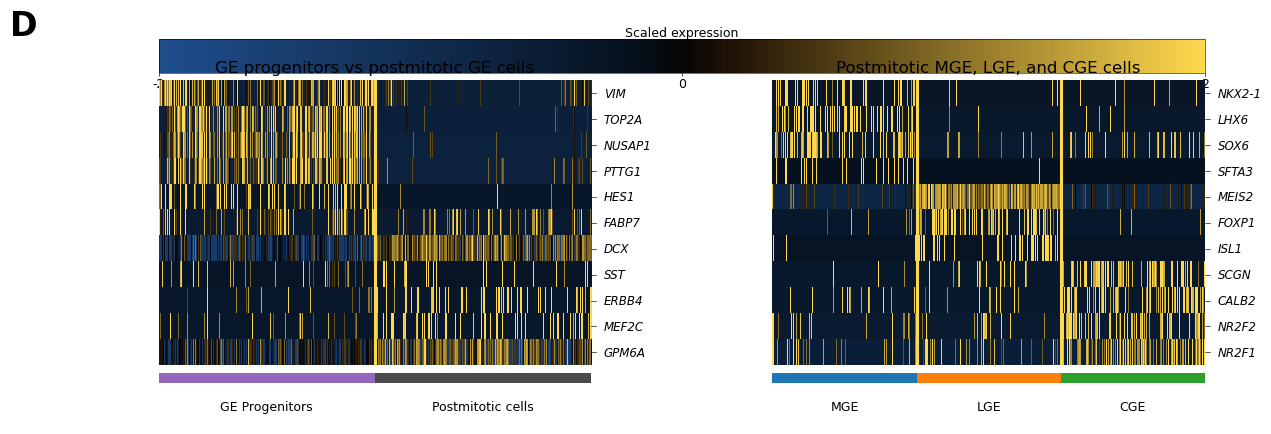

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse


# ============================================================
# Shi Fig. 1D-style DEG heatmaps
# ============================================================

left_panel_genes = [
    "VIM", "TOP2A", "NUSAP1", "PTTG1", "HES1", "FABP7",
    "DCX", "SST", "ERBB4", "MEF2C", "GPM6A",
]

right_panel_genes = [
    "NKX2-1", "LHX6", "SOX6", "SFTA3",
    "MEIS2", "FOXP1", "ISL1",
    "SCGN", "CALB2", "NR2F2", "NR2F1",
]

left_group_order = [
    "GE Progenitors",
    "Postmitotic cells",
]

right_group_order = [
    "MGE",
    "LGE",
    "CGE",
]

group_colors = {
    "GE Progenitors": "#9467bd",
    "Postmitotic cells": "#4a4a4a",
    "MGE": "#1f77b4",
    "LGE": "#ff7f0e",
    "CGE": "#2ca02c",
}


# ============================================================
# Helpers
# ============================================================

def resolve_gene_names(adata, genes):
    """Resolve requested gene symbols against adata.var_names, case-insensitively."""
    lookup = {str(g).upper(): str(g) for g in adata.var_names}
    resolved = []
    missing = []

    for gene in genes:
        match = lookup.get(gene.upper())
        if match is None:
            missing.append(gene)
        else:
            resolved.append(match)

    return resolved, missing


def zscore_genes_across_cells(x, clip=(-2, 2)):
    """
    Z-score each gene independently across cells.

    Input matrix is cells x genes.
    Output matrix is genes x cells, ready for heatmap rows = genes.
    """
    mean = np.nanmean(x, axis=0, keepdims=True)
    std = np.nanstd(x, axis=0, keepdims=True)
    std[std == 0] = 1.0

    z = (x - mean) / std
    z = np.clip(z, clip[0], clip[1])

    return z.T


def build_grouped_cell_index(
    obs,
    group_col,
    group_order,
    max_cells_per_group=1200,
    random_seed=1,
):
    """
    Build a biologically ordered cell index.

    Missing group labels are ignored. Cells are ordered by `group_order`.
    Within each group, current AnnData order is preserved unless subsampling is
    needed.

    This is useful for publication-style heatmaps because columns should follow
    biological order, not hierarchical clustering.
    """
    rng = np.random.default_rng(random_seed)

    selected_indices = []
    group_sizes_full = {}
    group_sizes_used = {}
    subsampled = False

    # Fill missing values before comparison; pd.NA cannot be used in boolean
    # masks safely.
    group_values = obs[group_col].astype("string").fillna("__missing__").to_numpy()

    for group in group_order:
        mask = group_values == group
        idx = np.flatnonzero(mask)

        group_sizes_full[group] = int(len(idx))

        if max_cells_per_group is not None and len(idx) > max_cells_per_group:
            idx = np.sort(rng.choice(idx, size=max_cells_per_group, replace=False))
            subsampled = True

        selected_indices.extend(idx.tolist())
        group_sizes_used[group] = int(len(idx))

    return np.asarray(selected_indices, dtype=int), group_sizes_full, group_sizes_used, subsampled


def make_de_heatmap_cmap():
    """
    Custom heatmap colormap:
    blue low relative expression -> black/dark center -> gold high expression.
    """
    return LinearSegmentedColormap.from_list(
        "blue_black_gold",
        [
            (0.00, "#1f4e8c"),
            (0.45, "#06111f"),
            (0.50, "#050505"),
            (0.55, "#211305"),
            (1.00, "#ffd84d"),
        ],
    )


def prepare_heatmap_data(
    adata,
    genes,
    group_col,
    group_order,
    max_cells_per_group=1200,
    random_seed=1,
    clip=(-2, 2),
):
    """
    Prepare z-scored expression matrix and metadata for one heatmap panel.

    Important for backed AnnData:
    Backed AnnData cannot create a view of a view. Therefore cells and genes are
    sliced together in one operation.
    """
    resolved_genes, missing_genes = resolve_gene_names(adata, genes)

    cell_idx, group_sizes_full, group_sizes_used, subsampled = build_grouped_cell_index(
        adata.obs,
        group_col=group_col,
        group_order=group_order,
        max_cells_per_group=max_cells_per_group,
        random_seed=random_seed,
    )

    if len(cell_idx) == 0:
        raise ValueError(f"No cells found for groups {group_order} in {group_col}")

    if len(resolved_genes) == 0:
        raise ValueError("None of the requested genes were found in adata.var_names")

    # One-step slice avoids backed AnnData view-of-view errors.
    x = adata[cell_idx, resolved_genes].X

    if sparse.issparse(x):
        x = x.toarray()

    x = np.asarray(x, dtype=float)
    z = zscore_genes_across_cells(x, clip=clip)

    return {
        "matrix": z,
        "genes": resolved_genes,
        "missing_genes": missing_genes,
        "cell_idx": cell_idx,
        "group_sizes_full": group_sizes_full,
        "group_sizes_used": group_sizes_used,
        "subsampled": subsampled,
        "clip": clip,
    }


def add_group_dividers(
    ax,
    group_sizes,
    group_order,
    color="#ffd84d",
    linewidth=2.2,
):
    """Add thick yellow divider lines between biological groups."""
    running = 0

    for group in group_order[:-1]:
        running += group_sizes[group]
        ax.axvline(
            running - 0.5,
            color=color,
            linewidth=linewidth,
            zorder=5,
        )


def add_group_annotation_bar(
    ax,
    group_sizes,
    group_order,
    group_colors,
):
    """Draw bottom group annotation bars under a heatmap."""
    total = sum(group_sizes[group] for group in group_order)
    start = 0

    for group in group_order:
        width = group_sizes[group]
        if width <= 0:
            continue

        ax.add_patch(
            mpl.patches.Rectangle(
                (start, 0),
                width,
                1,
                facecolor=group_colors[group],
                edgecolor="none",
            )
        )
        start += width

    ax.set_xlim(0, total)
    ax.set_ylim(0, 1)
    ax.axis("off")


def add_group_labels(
    ax,
    group_sizes,
    group_order,
):
    """Add group labels underneath the annotation bar."""
    total = sum(group_sizes[group] for group in group_order)
    start = 0

    for group in group_order:
        width = group_sizes[group]
        if width <= 0:
            continue

        center = start + width / 2
        ax.text(
            center,
            0.5,
            group,
            ha="center",
            va="center",
            fontsize=9,
            color="black",
        )
        start += width

    ax.set_xlim(0, total)
    ax.set_ylim(0, 1)
    ax.axis("off")


def add_gene_labels_right(
    ax,
    genes,
    label_x_offset=0.018,
    line_length_fraction=0.012,
):
    """
    Put italic gene labels on the right side with short connector lines.

    Labels are placed at row centers using axis coordinates.
    """
    n_genes = len(genes)

    for i, gene in enumerate(genes):
        y = 1 - ((i + 0.5) / n_genes)

        ax.plot(
            [1.0, 1.0 + line_length_fraction],
            [y, y],
            transform=ax.transAxes,
            color="black",
            linewidth=0.45,
            clip_on=False,
        )

        ax.text(
            1.0 + line_length_fraction + label_x_offset,
            y,
            gene.upper(),
            transform=ax.transAxes,
            ha="left",
            va="center",
            fontsize=8.5,
            fontstyle="italic",
            color="black",
            clip_on=False,
        )


def plot_de_heatmap_panel(
    ax_heatmap,
    ax_bar,
    ax_labels,
    heatmap_data,
    group_order,
    group_colors,
    title,
    cmap,
    vmin=-2,
    vmax=2,
):
    """Plot one manually organized DEG heatmap panel."""
    matrix = heatmap_data["matrix"]
    genes = heatmap_data["genes"]
    group_sizes = heatmap_data["group_sizes_used"]

    im = ax_heatmap.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
    )

    ax_heatmap.set_title(title, fontsize=12, fontweight="normal", pad=6)
    ax_heatmap.set_xticks([])
    ax_heatmap.set_yticks([])
    ax_heatmap.set_xlabel("")
    ax_heatmap.set_ylabel("")
    ax_heatmap.grid(False)

    for spine in ax_heatmap.spines.values():
        spine.set_visible(False)

    add_group_dividers(ax_heatmap, group_sizes, group_order)
    add_gene_labels_right(ax_heatmap, genes)
    add_group_annotation_bar(ax_bar, group_sizes, group_order, group_colors)
    add_group_labels(ax_labels, group_sizes, group_order)

    return im


# ============================================================
# Build biological groups
# ============================================================

shi = adatas["shi_2019_paper_qc"]

if "shi_major_type_display" not in shi.obs:
    raise KeyError(
        "shi.obs['shi_major_type_display'] not found. "
        "Run the Shi major cell-type mapping block first."
    )

# Left panel: GE Progenitors vs postmitotic GE cells.
shi.obs["deg_left_group"] = pd.NA

shi.obs.loc[
    shi.obs["shi_major_type_display"].astype("string").eq("GE Progenitors"),
    "deg_left_group",
] = "GE Progenitors"

shi.obs.loc[
    shi.obs["shi_major_type_display"].astype("string").isin(["MGE", "LGE", "CGE"]),
    "deg_left_group",
] = "Postmitotic cells"

shi.obs["deg_left_group"] = pd.Categorical(
    shi.obs["deg_left_group"],
    categories=left_group_order,
    ordered=True,
)

# Right panel: postmitotic MGE, LGE, CGE only.
shi.obs["deg_right_group"] = pd.NA

for group in right_group_order:
    shi.obs.loc[
        shi.obs["shi_major_type_display"].astype("string").eq(group),
        "deg_right_group",
    ] = group

shi.obs["deg_right_group"] = pd.Categorical(
    shi.obs["deg_right_group"],
    categories=right_group_order,
    ordered=True,
)


# ============================================================
# Prepare heatmap matrices
# ============================================================

heatmap_clip = (-2, 2)
max_cells_per_group = 1200

left_heatmap = prepare_heatmap_data(
    shi,
    genes=left_panel_genes,
    group_col="deg_left_group",
    group_order=left_group_order,
    max_cells_per_group=max_cells_per_group,
    random_seed=11,
    clip=heatmap_clip,
)

right_heatmap = prepare_heatmap_data(
    shi,
    genes=right_panel_genes,
    group_col="deg_right_group",
    group_order=right_group_order,
    max_cells_per_group=max_cells_per_group,
    random_seed=12,
    clip=heatmap_clip,
)


# ============================================================
# Validation output
# ============================================================

print("LEFT PANEL")
print("Groups:", left_group_order)
print("Cells available:", left_heatmap["group_sizes_full"])
print("Cells used:", left_heatmap["group_sizes_used"])
print("Genes selected:", left_heatmap["genes"])
print("Missing genes:", left_heatmap["missing_genes"])
print("Scaling range:", left_heatmap["clip"])
print("Subsampling applied:", left_heatmap["subsampled"])

print("\nRIGHT PANEL")
print("Groups:", right_group_order)
print("Cells available:", right_heatmap["group_sizes_full"])
print("Cells used:", right_heatmap["group_sizes_used"])
print("Genes selected:", right_heatmap["genes"])
print("Missing genes:", right_heatmap["missing_genes"])
print("Scaling range:", right_heatmap["clip"])
print("Subsampling applied:", right_heatmap["subsampled"])


# ============================================================
# Plot
# ============================================================

heatmap_cmap = make_de_heatmap_cmap()

fig = plt.figure(figsize=(13.5, 5.0), facecolor="white")

outer = fig.add_gridspec(
    nrows=4,
    ncols=2,
    height_ratios=[0.12, 1.0, 0.035, 0.12],
    width_ratios=[1.0, 1.0],
    wspace=0.42,
    hspace=0.08,
)

ax_cbar = fig.add_subplot(outer[0, :])
ax_left = fig.add_subplot(outer[1, 0])
ax_right = fig.add_subplot(outer[1, 1])
ax_left_bar = fig.add_subplot(outer[2, 0])
ax_right_bar = fig.add_subplot(outer[2, 1])
ax_left_labels = fig.add_subplot(outer[3, 0])
ax_right_labels = fig.add_subplot(outer[3, 1])

plot_de_heatmap_panel(
    ax_left,
    ax_left_bar,
    ax_left_labels,
    left_heatmap,
    group_order=left_group_order,
    group_colors=group_colors,
    title="GE progenitors vs postmitotic GE cells",
    cmap=heatmap_cmap,
    vmin=-2,
    vmax=2,
)

plot_de_heatmap_panel(
    ax_right,
    ax_right_bar,
    ax_right_labels,
    right_heatmap,
    group_order=right_group_order,
    group_colors=group_colors,
    title="Postmitotic MGE, LGE, and CGE cells",
    cmap=heatmap_cmap,
    vmin=-2,
    vmax=2,
)

norm = mpl.colors.Normalize(vmin=-2, vmax=2)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=heatmap_cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=ax_cbar,
    orientation="horizontal",
)
cbar.set_ticks([-2, 0, 2])
cbar.set_ticklabels(["-2", "0", "2"])
cbar.ax.tick_params(labelsize=9, length=2, width=0.5, pad=1)
cbar.outline.set_linewidth(0.4)
ax_cbar.set_title("Scaled expression", fontsize=9, pad=2)

fig.text(
    0.015,
    0.94,
    "D",
    fontsize=24,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
)

plt.show()

In [125]:
import sys
!{sys.executable} -m pip install scanpy

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 61.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 76.8 MB/s  0:00:00s eta 0:00:010:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 47.4 MB/s  0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13

In [126]:
import importlib
import scanpy as sc

print("scanpy", sc.__version__)

scanpy 1.11.5


/tmp/ipykernel_4118200/1936032866.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


DEG heatmap validation
----------------------
Left top_n per group: 60
Right top_n per group: 60
Left heatmap rows: 126
Right heatmap rows: 172
Scaling range: (-2, 2)

Left DEG cell counts used for DE:
GE Progenitors       5000
Postmitotic cells    5000
dtype: int64
Left DEG subsampled: True

Right DEG cell counts used for DE:
MGE    5000
LGE    5000
CGE    5000
dtype: int64
Right DEG subsampled: True

Left heatmap cell counts used:
GE Progenitors       1200
Postmitotic cells    1200
dtype: int64
Left heatmap subsampled: True

Right heatmap cell counts used:
MGE    1200
LGE    1200
CGE    1200
dtype: int64
Right heatmap subsampled: True

Left representative labels included:
['VIM', 'TOP2A', 'NUSAP1', 'PTTG1', 'HES1', 'FABP7', 'DCX', 'SST', 'ERBB4', 'MEF2C', 'GPM6A']
Left missing representative labels:
[]
Left forced-included labels:
['VIM', 'HES1', 'FABP7', 'SST', 'ERBB4', 'MEF2C']

Right representative labels included:
['NKX2-1', 'LHX6', 'SOX6', 'SFTA3', 'MEIS2', 'FOXP1', 'ISL1', 'SCG

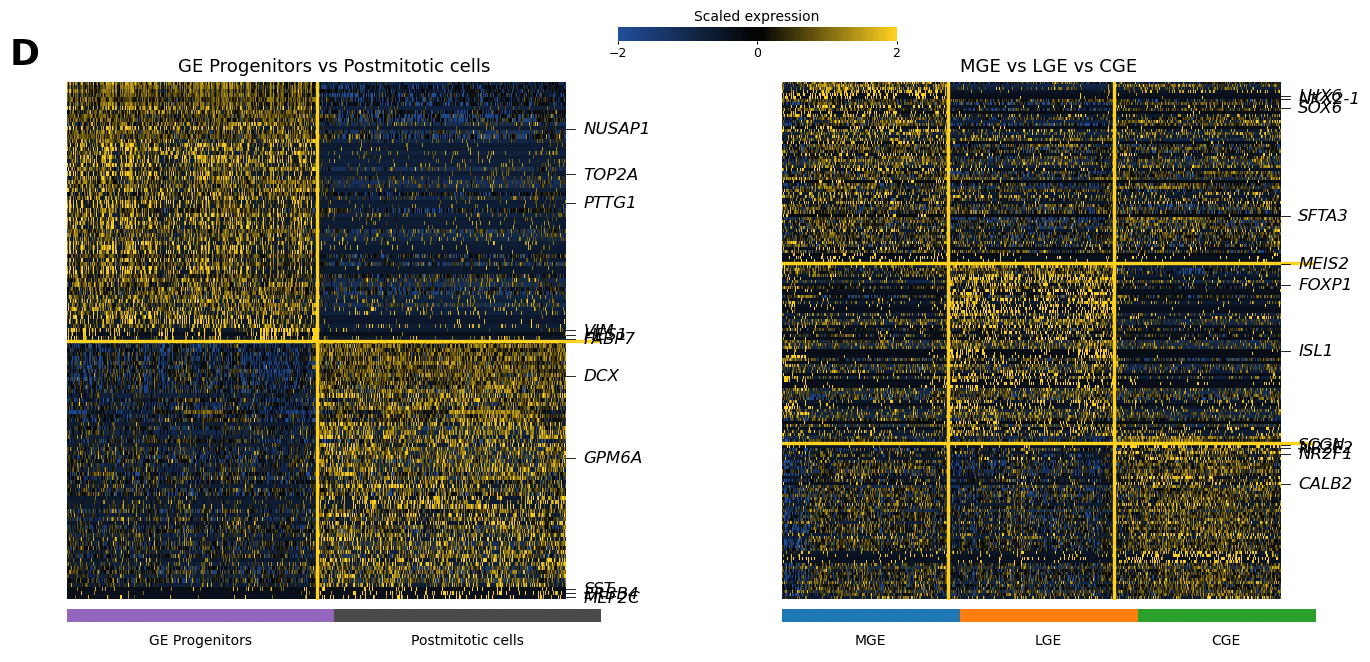

In [127]:
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse

try:
    import scanpy as sc
except ImportError as exc:
    raise ImportError(
        "scanpy is required for this DEG heatmap block. "
        "Install it in the mge-organoid-python environment if needed."
    ) from exc


# -----------------------------
# User controls
# -----------------------------

top_n_left = 60          # top DEGs per left-panel group
top_n_right = 60         # top DEGs per right-panel group
max_cells_per_group_heatmap = 1200
max_cells_per_group_deg = 5000
random_seed = 7
z_clip = (-2, 2)

LEFT_LABEL_GENES = [
    "VIM", "TOP2A", "NUSAP1", "PTTG1", "HES1", "FABP7",
    "DCX", "SST", "ERBB4", "MEF2C", "GPM6A",
]

RIGHT_LABEL_GENES = [
    "NKX2-1", "LHX6", "SOX6", "SFTA3",
    "MEIS2", "FOXP1", "ISL1",
    "SCGN", "CALB2", "NR2F2", "NR2F1",
]


# -----------------------------
# Biological group definitions
# -----------------------------

if "shi_major_type_display" not in shi.obs.columns:
    raise KeyError(
        "shi.obs['shi_major_type_display'] is missing. "
        "Run the Shi major cell type mapping block before this heatmap block."
    )

shi.obs["deg_left_group"] = pd.NA
shi.obs.loc[
    shi.obs["shi_major_type_display"] == "GE Progenitors",
    "deg_left_group",
] = "GE Progenitors"
shi.obs.loc[
    shi.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"]),
    "deg_left_group",
] = "Postmitotic cells"

shi.obs["deg_right_group"] = pd.NA
shi.obs.loc[
    shi.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"]),
    "deg_right_group",
] = shi.obs.loc[
    shi.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"]),
    "shi_major_type_display",
].astype(str)

LEFT_GROUP_ORDER = ["GE Progenitors", "Postmitotic cells"]
RIGHT_GROUP_ORDER = ["MGE", "LGE", "CGE"]

GROUP_COLORS = {
    "GE Progenitors": "#9467bd",
    "Postmitotic cells": "#4a4a4a",
    "MGE": "#1f77b4",
    "LGE": "#ff7f0e",
    "CGE": "#2ca02c",
}

LEFT_LABEL_TO_BLOCK = {
    "VIM": "GE Progenitors",
    "TOP2A": "GE Progenitors",
    "NUSAP1": "GE Progenitors",
    "PTTG1": "GE Progenitors",
    "HES1": "GE Progenitors",
    "FABP7": "GE Progenitors",
    "DCX": "Postmitotic cells",
    "SST": "Postmitotic cells",
    "ERBB4": "Postmitotic cells",
    "MEF2C": "Postmitotic cells",
    "GPM6A": "Postmitotic cells",
}

RIGHT_LABEL_TO_BLOCK = {
    "NKX2-1": "MGE",
    "LHX6": "MGE",
    "SOX6": "MGE",
    "SFTA3": "MGE",
    "MEIS2": "LGE",
    "FOXP1": "LGE",
    "ISL1": "LGE",
    "SCGN": "CGE",
    "CALB2": "CGE",
    "NR2F2": "CGE",
    "NR2F1": "CGE",
}


# -----------------------------
# Helpers
# -----------------------------

def make_de_heatmap_cmap():
    """Blue/black/gold colormap for scaled expression centered at zero."""
    return LinearSegmentedColormap.from_list(
        "blue_black_gold",
        [
            (0.00, "#214f9a"),
            (0.48, "#050505"),
            (0.52, "#050505"),
            (1.00, "#ffd21f"),
        ],
    )


def resolve_gene_names(adata, genes):
    """Resolve requested gene symbols against adata.var_names."""
    var_names = pd.Index(adata.var_names.astype(str))
    upper_to_actual = {}
    for gene in var_names:
        upper_to_actual.setdefault(gene.upper(), gene)

    resolved = []
    missing = []

    for gene in genes:
        gene = str(gene)
        if gene in var_names:
            resolved.append(gene)
        elif gene.upper() in upper_to_actual:
            resolved.append(upper_to_actual[gene.upper()])
        else:
            missing.append(gene)

    return resolved, missing


def unique_preserve_order(items):
    """Remove duplicates while preserving order."""
    return list(OrderedDict.fromkeys(items))


def valid_gene_name(gene):
    """Exclude blank or invalid gene names from DEG selections."""
    if gene is None:
        return False
    gene = str(gene).strip()
    if gene == "":
        return False
    if gene.lower() in {"nan", "none", "na"}:
        return False
    return True


def get_group_cell_indices(obs, group_col, group_order, max_cells_per_group=None, random_seed=7):
    """Return cell indices grouped in biological order."""
    rng = np.random.default_rng(random_seed)

    group_values = (
        obs[group_col]
        .astype("string")
        .fillna("__missing__")
        .to_numpy()
    )

    selected = []
    full_counts = {}
    used_counts = {}
    subsampled = False

    for group in group_order:
        idx = np.flatnonzero(group_values == group)
        full_counts[group] = int(len(idx))

        if max_cells_per_group is not None and len(idx) > max_cells_per_group:
            idx = np.sort(rng.choice(idx, size=max_cells_per_group, replace=False))
            subsampled = True

        used_counts[group] = int(len(idx))
        selected.append(idx)

    if selected:
        selected = np.concatenate(selected)
    else:
        selected = np.array([], dtype=int)

    return selected, full_counts, used_counts, subsampled


def make_in_memory_subset_for_deg(
    adata,
    group_col,
    group_order,
    max_cells_per_group=5000,
    random_seed=7,
):
    """
    Build an in-memory AnnData subset for DEG.

    This avoids backed AnnData view-of-view errors and keeps DEG manageable.
    The original AnnData object is not modified.
    """
    cell_idx, full_counts, used_counts, subsampled = get_group_cell_indices(
        adata.obs,
        group_col=group_col,
        group_order=group_order,
        max_cells_per_group=max_cells_per_group,
        random_seed=random_seed,
    )

    if len(cell_idx) == 0:
        raise ValueError(f"No cells found for {group_col} with groups {group_order}")

    subset = adata[cell_idx, :].to_memory()
    subset.obs[group_col] = pd.Categorical(
        subset.obs[group_col].astype(str),
        categories=group_order,
        ordered=True,
    )

    return subset, full_counts, used_counts, subsampled


def run_rank_genes_groups(
    adata,
    group_col,
    group_order,
    max_cells_per_group=5000,
    random_seed=7,
):
    """
    Run Wilcoxon DEG with scanpy.

    The heatmap body comes from these ranked DEGs, not from manual marker lists.
    """
    deg_adata, full_counts, used_counts, subsampled = make_in_memory_subset_for_deg(
        adata,
        group_col=group_col,
        group_order=group_order,
        max_cells_per_group=max_cells_per_group,
        random_seed=random_seed,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sc.tl.rank_genes_groups(
            deg_adata,
            groupby=group_col,
            groups=group_order,
            reference="rest",
            method="wilcoxon",
            use_raw=False,
            n_genes=deg_adata.n_vars,
        )

    return deg_adata, full_counts, used_counts, subsampled


def extract_top_degs_for_group(deg_adata, group, top_n=60, padj_cutoff=0.05):
    """
    Select top positively enriched genes for one group.

    Prefer adjusted p-value < 0.05 when available. If that filter is too strict,
    fall back to positive-score genes so the heatmap remains populated.
    """
    result = deg_adata.uns["rank_genes_groups"]

    names = pd.Series(result["names"][group]).astype(str)
    scores = pd.Series(result["scores"][group]).astype(float)

    if "logfoldchanges" in result:
        logfc = pd.Series(result["logfoldchanges"][group]).astype(float)
    else:
        logfc = pd.Series(np.nan, index=names.index)

    if "pvals_adj" in result:
        padj = pd.Series(result["pvals_adj"][group]).astype(float)
    else:
        padj = pd.Series(np.nan, index=names.index)

    df = pd.DataFrame(
        {
            "gene": names,
            "score": scores,
            "logfoldchange": logfc,
            "pvals_adj": padj,
        }
    )

    df = df[df["gene"].map(valid_gene_name)]
    df = df.replace([np.inf, -np.inf], np.nan)

    positive = df[
        (df["score"] > 0)
        & (df["logfoldchange"].isna() | (df["logfoldchange"] > 0))
    ].copy()

    significant = positive[
        positive["pvals_adj"].isna() | (positive["pvals_adj"] < padj_cutoff)
    ].copy()

    if len(significant) >= top_n:
        selected = significant
    else:
        selected = positive

    selected = selected.sort_values(
        by=["score", "logfoldchange"],
        ascending=False,
        na_position="last",
    )

    return unique_preserve_order(selected["gene"].head(top_n).tolist())


def build_deg_gene_blocks(
    deg_adata,
    group_order,
    top_n,
    label_genes,
    label_to_block,
):
    """
    Build heatmap row blocks.

    Manual label genes are force-included in their biological block if present,
    but they are not used as the full heatmap body.
    """
    label_resolved, missing_label_genes = resolve_gene_names(deg_adata, label_genes)
    label_upper_to_actual = {gene.upper(): gene for gene in label_resolved}

    blocks = OrderedDict()
    forced_labels = []

    for group in group_order:
        top_genes = extract_top_degs_for_group(
            deg_adata,
            group=group,
            top_n=top_n,
            padj_cutoff=0.05,
        )

        for label_gene, target_group in label_to_block.items():
            if target_group != group:
                continue

            resolved_label = label_upper_to_actual.get(label_gene.upper())
            if resolved_label is not None and resolved_label not in top_genes:
                top_genes.append(resolved_label)
                forced_labels.append(resolved_label)

        blocks[group] = unique_preserve_order(top_genes)

    all_genes = []
    block_boundaries = []
    cursor = 0

    for group, genes in blocks.items():
        all_genes.extend(genes)
        cursor += len(genes)
        block_boundaries.append(cursor)

    all_genes = unique_preserve_order(all_genes)

    included_label_genes = [gene for gene in label_resolved if gene in all_genes]
    missing_after_include = [gene for gene in label_genes if gene.upper() not in {g.upper() for g in included_label_genes}]

    return {
        "blocks": blocks,
        "genes": all_genes,
        "block_boundaries": block_boundaries[:-1],
        "label_genes": included_label_genes,
        "missing_label_genes": missing_after_include,
        "forced_label_genes": forced_labels,
    }


def get_expression_matrix(adata, cell_idx, genes):
    """
    Return dense cells x genes expression matrix.

    Slicing is done in one step to avoid backed AnnData view-of-view errors.
    """
    x = adata[cell_idx, genes].X
    if sparse.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=float)


def zscore_by_gene(x, clip=(-2, 2)):
    """Gene-wise z-score across selected cells, then clip for visualization."""
    mean = np.nanmean(x, axis=0, keepdims=True)
    std = np.nanstd(x, axis=0, keepdims=True)
    std[std == 0] = 1.0

    z = (x - mean) / std
    z = np.clip(z, clip[0], clip[1])
    return z


def prepare_heatmap_data(
    adata,
    genes,
    group_col,
    group_order,
    max_cells_per_group=1200,
    random_seed=7,
    clip=(-2, 2),
):
    """Prepare rows = genes, columns = grouped cells heatmap matrix."""
    resolved_genes, missing_genes = resolve_gene_names(adata, genes)

    cell_idx, full_counts, used_counts, subsampled = get_group_cell_indices(
        adata.obs,
        group_col=group_col,
        group_order=group_order,
        max_cells_per_group=max_cells_per_group,
        random_seed=random_seed,
    )

    x = get_expression_matrix(adata, cell_idx, resolved_genes)
    z = zscore_by_gene(x, clip=clip)

    return {
        "matrix": z.T,
        "genes": resolved_genes,
        "missing_genes": missing_genes,
        "cell_idx": cell_idx,
        "full_counts": full_counts,
        "used_counts": used_counts,
        "subsampled": subsampled,
        "group_order": group_order,
        "group_col": group_col,
        "clip": clip,
    }


def add_vertical_group_dividers(ax, used_counts, group_order, color="#ffd21f", linewidth=2.4):
    """Yellow vertical dividers between cell groups."""
    cursor = 0
    for group in group_order[:-1]:
        cursor += used_counts[group]
        ax.axvline(cursor - 0.5, color=color, linewidth=linewidth)


def add_horizontal_gene_block_dividers(ax, block_boundaries, color="#ffd21f", linewidth=2.4):
    """Yellow horizontal dividers between DEG gene blocks."""
    for boundary in block_boundaries:
        ax.axhline(boundary - 0.5, color=color, linewidth=linewidth)


def add_group_annotation_bar(fig, ax, used_counts, group_order, group_colors):
    """Add colored group identity bar below heatmap."""
    bbox = ax.get_position()
    bar_height = 0.018

    bar_ax = fig.add_axes([bbox.x0, bbox.y0 - 0.030, bbox.width, bar_height])
    total = sum(used_counts[g] for g in group_order)

    bar = np.zeros((1, total, 3))
    cursor = 0

    for group in group_order:
        n = used_counts[group]
        rgb = mpl.colors.to_rgb(group_colors[group])
        bar[:, cursor:cursor + n, :] = rgb
        cursor += n

    bar_ax.imshow(bar, aspect="auto")
    bar_ax.set_axis_off()

    label_ax = fig.add_axes([bbox.x0, bbox.y0 - 0.070, bbox.width, 0.035])
    label_ax.set_xlim(0, total)
    label_ax.set_ylim(0, 1)
    label_ax.set_axis_off()

    cursor = 0
    for group in group_order:
        n = used_counts[group]
        label_ax.text(
            cursor + n / 2,
            0.45,
            group,
            ha="center",
            va="center",
            fontsize=10,
            color="black",
        )
        cursor += n


def add_marker_gene_labels(ax, heatmap_data, label_genes, fontsize=12):
    """
    Label only representative marker genes on the right side.

    These labels point into a larger DEG heatmap body.
    """
    genes = heatmap_data["genes"]
    gene_to_row = {gene.upper(): i for i, gene in enumerate(genes)}

    rows = []
    labels = []

    for gene in label_genes:
        key = gene.upper()
        if key in gene_to_row:
            rows.append(gene_to_row[key])
            labels.append(gene)

    if not rows:
        return

    n_rows = len(genes)
    x0 = heatmap_data["matrix"].shape[1] - 0.5
    x1 = heatmap_data["matrix"].shape[1] + heatmap_data["matrix"].shape[1] * 0.018
    x_text = heatmap_data["matrix"].shape[1] + heatmap_data["matrix"].shape[1] * 0.035

    for row, label in zip(rows, labels):
        y = row
        ax.plot(
            [x0, x1],
            [y, y],
            color="black",
            linewidth=0.6,
            clip_on=False,
        )
        ax.text(
            x_text,
            y,
            label.upper(),
            ha="left",
            va="center",
            fontsize=fontsize,
            fontstyle="italic",
            fontweight="normal",
            color="black",
            clip_on=False,
        )


def plot_de_heatmap_panel(
    fig,
    ax,
    heatmap_data,
    gene_block_boundaries,
    label_genes,
    title,
    cmap,
    norm,
):
    """Plot one publication-style DEG heatmap panel."""
    matrix = heatmap_data["matrix"]

    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )

    ax.set_title(title, fontsize=13, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(False)

    add_vertical_group_dividers(
        ax,
        heatmap_data["used_counts"],
        heatmap_data["group_order"],
    )

    add_horizontal_gene_block_dividers(
        ax,
        gene_block_boundaries,
    )

    add_group_annotation_bar(
        fig,
        ax,
        heatmap_data["used_counts"],
        heatmap_data["group_order"],
        GROUP_COLORS,
    )

    add_marker_gene_labels(
        ax,
        heatmap_data,
        label_genes=label_genes,
        fontsize=12,
    )

    return im


# -----------------------------
# Run DEG
# -----------------------------

left_deg_adata, left_deg_full_counts, left_deg_used_counts, left_deg_subsampled = run_rank_genes_groups(
    shi,
    group_col="deg_left_group",
    group_order=LEFT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_deg,
    random_seed=random_seed,
)

right_deg_adata, right_deg_full_counts, right_deg_used_counts, right_deg_subsampled = run_rank_genes_groups(
    shi,
    group_col="deg_right_group",
    group_order=RIGHT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_deg,
    random_seed=random_seed,
)


# -----------------------------
# Build DEG-backed row lists
# -----------------------------

left_gene_selection = build_deg_gene_blocks(
    left_deg_adata,
    group_order=LEFT_GROUP_ORDER,
    top_n=top_n_left,
    label_genes=LEFT_LABEL_GENES,
    label_to_block=LEFT_LABEL_TO_BLOCK,
)

right_gene_selection = build_deg_gene_blocks(
    right_deg_adata,
    group_order=RIGHT_GROUP_ORDER,
    top_n=top_n_right,
    label_genes=RIGHT_LABEL_GENES,
    label_to_block=RIGHT_LABEL_TO_BLOCK,
)


# -----------------------------
# Prepare heatmap matrices
# -----------------------------

left_heatmap = prepare_heatmap_data(
    shi,
    genes=left_gene_selection["genes"],
    group_col="deg_left_group",
    group_order=LEFT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_heatmap,
    random_seed=random_seed,
    clip=z_clip,
)

right_heatmap = prepare_heatmap_data(
    shi,
    genes=right_gene_selection["genes"],
    group_col="deg_right_group",
    group_order=RIGHT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_heatmap,
    random_seed=random_seed,
    clip=z_clip,
)


# -----------------------------
# Validation output
# -----------------------------

print("DEG heatmap validation")
print("----------------------")
print(f"Left top_n per group: {top_n_left}")
print(f"Right top_n per group: {top_n_right}")
print(f"Left heatmap rows: {len(left_heatmap['genes'])}")
print(f"Right heatmap rows: {len(right_heatmap['genes'])}")
print(f"Scaling range: {z_clip}")

print("\nLeft DEG cell counts used for DE:")
print(pd.Series(left_deg_used_counts))
print("Left DEG subsampled:", left_deg_subsampled)

print("\nRight DEG cell counts used for DE:")
print(pd.Series(right_deg_used_counts))
print("Right DEG subsampled:", right_deg_subsampled)

print("\nLeft heatmap cell counts used:")
print(pd.Series(left_heatmap["used_counts"]))
print("Left heatmap subsampled:", left_heatmap["subsampled"])

print("\nRight heatmap cell counts used:")
print(pd.Series(right_heatmap["used_counts"]))
print("Right heatmap subsampled:", right_heatmap["subsampled"])

print("\nLeft representative labels included:")
print(left_gene_selection["label_genes"])
print("Left missing representative labels:")
print(left_gene_selection["missing_label_genes"])
print("Left forced-included labels:")
print(left_gene_selection["forced_label_genes"])

print("\nRight representative labels included:")
print(right_gene_selection["label_genes"])
print("Right missing representative labels:")
print(right_gene_selection["missing_label_genes"])
print("Right forced-included labels:")
print(right_gene_selection["forced_label_genes"])


# -----------------------------
# Plot
# -----------------------------

cmap = make_de_heatmap_cmap()
norm = mpl.colors.TwoSlopeNorm(vmin=z_clip[0], vcenter=0, vmax=z_clip[1])

fig = plt.figure(figsize=(15.5, 7.5), facecolor="white")

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.055,
    right=0.86,
    bottom=0.15,
    top=0.84,
    wspace=0.34,
)

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

im_left = plot_de_heatmap_panel(
    fig,
    ax_left,
    left_heatmap,
    gene_block_boundaries=left_gene_selection["block_boundaries"],
    label_genes=LEFT_LABEL_GENES,
    title="GE Progenitors vs Postmitotic cells",
    cmap=cmap,
    norm=norm,
)

im_right = plot_de_heatmap_panel(
    fig,
    ax_right,
    right_heatmap,
    gene_block_boundaries=right_gene_selection["block_boundaries"],
    label_genes=RIGHT_LABEL_GENES,
    title="MGE vs LGE vs CGE",
    cmap=cmap,
    norm=norm,
)

# Shared compact colorbar above panels
cbar_ax = fig.add_axes([0.41, 0.895, 0.18, 0.018])
cbar = fig.colorbar(
    im_left,
    cax=cbar_ax,
    orientation="horizontal",
    ticks=[-2, 0, 2],
)
cbar.ax.tick_params(labelsize=9, length=2, pad=2)
cbar.outline.set_visible(False)
cbar_ax.set_title("Scaled expression", fontsize=10, pad=5)

# Panel label
fig.text(
    0.018,
    0.90,
    "D",
    fontsize=26,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
)

plt.show()

DEG heatmap validation
----------------------
Left top_n per group: 60
Right top_n per group: 60
Left heatmap rows: 126
Right heatmap rows: 172
Scaling range: (-2, 2)

Left DEG cell counts used for DE:
GE Progenitors       5000
Postmitotic cells    5000
dtype: int64
Left DEG subsampled: True

Right DEG cell counts used for DE:
MGE    5000
LGE    5000
CGE    5000
dtype: int64
Right DEG subsampled: True

Left heatmap cell counts used:
GE Progenitors       1200
Postmitotic cells    1200
dtype: int64
Left heatmap subsampled: True

Right heatmap cell counts used:
MGE    1200
LGE    1200
CGE    1200
dtype: int64
Right heatmap subsampled: True

Left representative labels included:
['VIM', 'TOP2A', 'NUSAP1', 'PTTG1', 'HES1', 'FABP7', 'DCX', 'SST', 'ERBB4', 'MEF2C', 'GPM6A']
Left missing representative labels:
[]
Left forced-included labels:
['VIM', 'HES1', 'FABP7', 'SST', 'ERBB4', 'MEF2C']

Right representative labels included:
['NKX2-1', 'LHX6', 'SOX6', 'SFTA3', 'MEIS2', 'FOXP1', 'ISL1', 'SCG

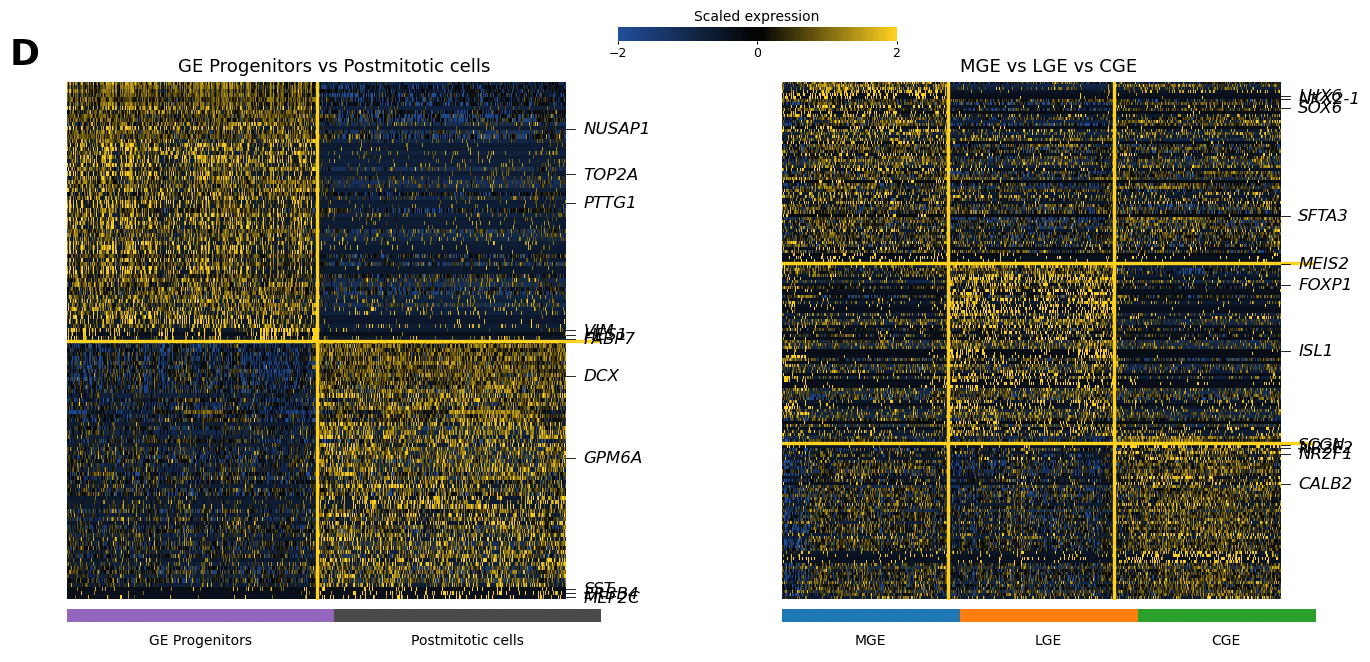

In [128]:
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse

try:
    import scanpy as sc
except ImportError as exc:
    raise ImportError(
        "scanpy is required for this DEG heatmap block. "
        "Install it in the mge-organoid-python environment if needed."
    ) from exc


# -----------------------------
# User controls
# -----------------------------

top_n_left = 60          # top DEGs per left-panel group
top_n_right = 60         # top DEGs per right-panel group
max_cells_per_group_heatmap = 1200
max_cells_per_group_deg = 5000
random_seed = 7
z_clip = (-2, 2)

LEFT_LABEL_GENES = [
    "VIM", "TOP2A", "NUSAP1", "PTTG1", "HES1", "FABP7",
    "DCX", "SST", "ERBB4", "MEF2C", "GPM6A",
]

RIGHT_LABEL_GENES = [
    "NKX2-1", "LHX6", "SOX6", "SFTA3",
    "MEIS2", "FOXP1", "ISL1",
    "SCGN", "CALB2", "NR2F2", "NR2F1",
]


# -----------------------------
# Biological group definitions
# -----------------------------

if "shi_major_type_display" not in shi.obs.columns:
    raise KeyError(
        "shi.obs['shi_major_type_display'] is missing. "
        "Run the Shi major cell type mapping block before this heatmap block."
    )

shi.obs["deg_left_group"] = pd.NA
shi.obs.loc[
    shi.obs["shi_major_type_display"] == "GE Progenitors",
    "deg_left_group",
] = "GE Progenitors"
shi.obs.loc[
    shi.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"]),
    "deg_left_group",
] = "Postmitotic cells"

shi.obs["deg_right_group"] = pd.NA
shi.obs.loc[
    shi.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"]),
    "deg_right_group",
] = shi.obs.loc[
    shi.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"]),
    "shi_major_type_display",
].astype(str)

LEFT_GROUP_ORDER = ["GE Progenitors", "Postmitotic cells"]
RIGHT_GROUP_ORDER = ["MGE", "LGE", "CGE"]

GROUP_COLORS = {
    "GE Progenitors": "#9467bd",
    "Postmitotic cells": "#4a4a4a",
    "MGE": "#1f77b4",
    "LGE": "#ff7f0e",
    "CGE": "#2ca02c",
}

LEFT_LABEL_TO_BLOCK = {
    "VIM": "GE Progenitors",
    "TOP2A": "GE Progenitors",
    "NUSAP1": "GE Progenitors",
    "PTTG1": "GE Progenitors",
    "HES1": "GE Progenitors",
    "FABP7": "GE Progenitors",
    "DCX": "Postmitotic cells",
    "SST": "Postmitotic cells",
    "ERBB4": "Postmitotic cells",
    "MEF2C": "Postmitotic cells",
    "GPM6A": "Postmitotic cells",
}

RIGHT_LABEL_TO_BLOCK = {
    "NKX2-1": "MGE",
    "LHX6": "MGE",
    "SOX6": "MGE",
    "SFTA3": "MGE",
    "MEIS2": "LGE",
    "FOXP1": "LGE",
    "ISL1": "LGE",
    "SCGN": "CGE",
    "CALB2": "CGE",
    "NR2F2": "CGE",
    "NR2F1": "CGE",
}


# -----------------------------
# Helpers
# -----------------------------

def make_de_heatmap_cmap():
    """Blue/black/gold colormap for scaled expression centered at zero."""
    return LinearSegmentedColormap.from_list(
        "blue_black_gold",
        [
            (0.00, "#214f9a"),
            (0.48, "#050505"),
            (0.52, "#050505"),
            (1.00, "#ffd21f"),
        ],
    )


def resolve_gene_names(adata, genes):
    """Resolve requested gene symbols against adata.var_names."""
    var_names = pd.Index(adata.var_names.astype(str))
    upper_to_actual = {}
    for gene in var_names:
        upper_to_actual.setdefault(gene.upper(), gene)

    resolved = []
    missing = []

    for gene in genes:
        gene = str(gene)
        if gene in var_names:
            resolved.append(gene)
        elif gene.upper() in upper_to_actual:
            resolved.append(upper_to_actual[gene.upper()])
        else:
            missing.append(gene)

    return resolved, missing


def unique_preserve_order(items):
    """Remove duplicates while preserving order."""
    return list(OrderedDict.fromkeys(items))


def valid_gene_name(gene):
    """Exclude blank or invalid gene names from DEG selections."""
    if gene is None:
        return False
    gene = str(gene).strip()
    if gene == "":
        return False
    if gene.lower() in {"nan", "none", "na"}:
        return False
    return True


def get_group_cell_indices(obs, group_col, group_order, max_cells_per_group=None, random_seed=7):
    """Return cell indices grouped in biological order."""
    rng = np.random.default_rng(random_seed)

    group_values = (
        obs[group_col]
        .astype("string")
        .fillna("__missing__")
        .to_numpy()
    )

    selected = []
    full_counts = {}
    used_counts = {}
    subsampled = False

    for group in group_order:
        idx = np.flatnonzero(group_values == group)
        full_counts[group] = int(len(idx))

        if max_cells_per_group is not None and len(idx) > max_cells_per_group:
            idx = np.sort(rng.choice(idx, size=max_cells_per_group, replace=False))
            subsampled = True

        used_counts[group] = int(len(idx))
        selected.append(idx)

    if selected:
        selected = np.concatenate(selected)
    else:
        selected = np.array([], dtype=int)

    return selected, full_counts, used_counts, subsampled


def make_in_memory_subset_for_deg(
    adata,
    group_col,
    group_order,
    max_cells_per_group=5000,
    random_seed=7,
):
    """
    Build an in-memory AnnData subset for DEG.

    This avoids backed AnnData view-of-view errors and keeps DEG manageable.
    The original AnnData object is not modified.
    """
    cell_idx, full_counts, used_counts, subsampled = get_group_cell_indices(
        adata.obs,
        group_col=group_col,
        group_order=group_order,
        max_cells_per_group=max_cells_per_group,
        random_seed=random_seed,
    )

    if len(cell_idx) == 0:
        raise ValueError(f"No cells found for {group_col} with groups {group_order}")

    subset = adata[cell_idx, :].to_memory()
    subset.obs[group_col] = pd.Categorical(
        subset.obs[group_col].astype(str),
        categories=group_order,
        ordered=True,
    )

    return subset, full_counts, used_counts, subsampled


def run_rank_genes_groups(
    adata,
    group_col,
    group_order,
    max_cells_per_group=5000,
    random_seed=7,
):
    """
    Run Wilcoxon DEG with scanpy.

    The heatmap body comes from these ranked DEGs, not from manual marker lists.
    """
    deg_adata, full_counts, used_counts, subsampled = make_in_memory_subset_for_deg(
        adata,
        group_col=group_col,
        group_order=group_order,
        max_cells_per_group=max_cells_per_group,
        random_seed=random_seed,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sc.tl.rank_genes_groups(
            deg_adata,
            groupby=group_col,
            groups=group_order,
            reference="rest",
            method="wilcoxon",
            use_raw=False,
            n_genes=deg_adata.n_vars,
        )

    return deg_adata, full_counts, used_counts, subsampled


def extract_top_degs_for_group(deg_adata, group, top_n=60, padj_cutoff=0.05):
    """
    Select top positively enriched genes for one group.

    Prefer adjusted p-value < 0.05 when available. If that filter is too strict,
    fall back to positive-score genes so the heatmap remains populated.
    """
    result = deg_adata.uns["rank_genes_groups"]

    names = pd.Series(result["names"][group]).astype(str)
    scores = pd.Series(result["scores"][group]).astype(float)

    if "logfoldchanges" in result:
        logfc = pd.Series(result["logfoldchanges"][group]).astype(float)
    else:
        logfc = pd.Series(np.nan, index=names.index)

    if "pvals_adj" in result:
        padj = pd.Series(result["pvals_adj"][group]).astype(float)
    else:
        padj = pd.Series(np.nan, index=names.index)

    df = pd.DataFrame(
        {
            "gene": names,
            "score": scores,
            "logfoldchange": logfc,
            "pvals_adj": padj,
        }
    )

    df = df[df["gene"].map(valid_gene_name)]
    df = df.replace([np.inf, -np.inf], np.nan)

    positive = df[
        (df["score"] > 0)
        & (df["logfoldchange"].isna() | (df["logfoldchange"] > 0))
    ].copy()

    significant = positive[
        positive["pvals_adj"].isna() | (positive["pvals_adj"] < padj_cutoff)
    ].copy()

    if len(significant) >= top_n:
        selected = significant
    else:
        selected = positive

    selected = selected.sort_values(
        by=["score", "logfoldchange"],
        ascending=False,
        na_position="last",
    )

    return unique_preserve_order(selected["gene"].head(top_n).tolist())


def build_deg_gene_blocks(
    deg_adata,
    group_order,
    top_n,
    label_genes,
    label_to_block,
):
    """
    Build heatmap row blocks.

    Manual label genes are force-included in their biological block if present,
    but they are not used as the full heatmap body.
    """
    label_resolved, missing_label_genes = resolve_gene_names(deg_adata, label_genes)
    label_upper_to_actual = {gene.upper(): gene for gene in label_resolved}

    blocks = OrderedDict()
    forced_labels = []

    for group in group_order:
        top_genes = extract_top_degs_for_group(
            deg_adata,
            group=group,
            top_n=top_n,
            padj_cutoff=0.05,
        )

        for label_gene, target_group in label_to_block.items():
            if target_group != group:
                continue

            resolved_label = label_upper_to_actual.get(label_gene.upper())
            if resolved_label is not None and resolved_label not in top_genes:
                top_genes.append(resolved_label)
                forced_labels.append(resolved_label)

        blocks[group] = unique_preserve_order(top_genes)

    all_genes = []
    block_boundaries = []
    cursor = 0

    for group, genes in blocks.items():
        all_genes.extend(genes)
        cursor += len(genes)
        block_boundaries.append(cursor)

    all_genes = unique_preserve_order(all_genes)

    included_label_genes = [gene for gene in label_resolved if gene in all_genes]
    missing_after_include = [gene for gene in label_genes if gene.upper() not in {g.upper() for g in included_label_genes}]

    return {
        "blocks": blocks,
        "genes": all_genes,
        "block_boundaries": block_boundaries[:-1],
        "label_genes": included_label_genes,
        "missing_label_genes": missing_after_include,
        "forced_label_genes": forced_labels,
    }


def get_expression_matrix(adata, cell_idx, genes):
    """
    Return dense cells x genes expression matrix.

    Slicing is done in one step to avoid backed AnnData view-of-view errors.
    """
    x = adata[cell_idx, genes].X
    if sparse.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=float)


def zscore_by_gene(x, clip=(-2, 2)):
    """Gene-wise z-score across selected cells, then clip for visualization."""
    mean = np.nanmean(x, axis=0, keepdims=True)
    std = np.nanstd(x, axis=0, keepdims=True)
    std[std == 0] = 1.0

    z = (x - mean) / std
    z = np.clip(z, clip[0], clip[1])
    return z


def prepare_heatmap_data(
    adata,
    genes,
    group_col,
    group_order,
    max_cells_per_group=1200,
    random_seed=7,
    clip=(-2, 2),
):
    """Prepare rows = genes, columns = grouped cells heatmap matrix."""
    resolved_genes, missing_genes = resolve_gene_names(adata, genes)

    cell_idx, full_counts, used_counts, subsampled = get_group_cell_indices(
        adata.obs,
        group_col=group_col,
        group_order=group_order,
        max_cells_per_group=max_cells_per_group,
        random_seed=random_seed,
    )

    x = get_expression_matrix(adata, cell_idx, resolved_genes)
    z = zscore_by_gene(x, clip=clip)

    return {
        "matrix": z.T,
        "genes": resolved_genes,
        "missing_genes": missing_genes,
        "cell_idx": cell_idx,
        "full_counts": full_counts,
        "used_counts": used_counts,
        "subsampled": subsampled,
        "group_order": group_order,
        "group_col": group_col,
        "clip": clip,
    }


def add_vertical_group_dividers(ax, used_counts, group_order, color="#ffd21f", linewidth=2.4):
    """Yellow vertical dividers between cell groups."""
    cursor = 0
    for group in group_order[:-1]:
        cursor += used_counts[group]
        ax.axvline(cursor - 0.5, color=color, linewidth=linewidth)


def add_horizontal_gene_block_dividers(ax, block_boundaries, color="#ffd21f", linewidth=2.4):
    """Yellow horizontal dividers between DEG gene blocks."""
    for boundary in block_boundaries:
        ax.axhline(boundary - 0.5, color=color, linewidth=linewidth)


def add_group_annotation_bar(fig, ax, used_counts, group_order, group_colors):
    """Add colored group identity bar below heatmap."""
    bbox = ax.get_position()
    bar_height = 0.018

    bar_ax = fig.add_axes([bbox.x0, bbox.y0 - 0.030, bbox.width, bar_height])
    total = sum(used_counts[g] for g in group_order)

    bar = np.zeros((1, total, 3))
    cursor = 0

    for group in group_order:
        n = used_counts[group]
        rgb = mpl.colors.to_rgb(group_colors[group])
        bar[:, cursor:cursor + n, :] = rgb
        cursor += n

    bar_ax.imshow(bar, aspect="auto")
    bar_ax.set_axis_off()

    label_ax = fig.add_axes([bbox.x0, bbox.y0 - 0.070, bbox.width, 0.035])
    label_ax.set_xlim(0, total)
    label_ax.set_ylim(0, 1)
    label_ax.set_axis_off()

    cursor = 0
    for group in group_order:
        n = used_counts[group]
        label_ax.text(
            cursor + n / 2,
            0.45,
            group,
            ha="center",
            va="center",
            fontsize=10,
            color="black",
        )
        cursor += n


def add_marker_gene_labels(ax, heatmap_data, label_genes, fontsize=12):
    """
    Label only representative marker genes on the right side.

    These labels point into a larger DEG heatmap body.
    """
    genes = heatmap_data["genes"]
    gene_to_row = {gene.upper(): i for i, gene in enumerate(genes)}

    rows = []
    labels = []

    for gene in label_genes:
        key = gene.upper()
        if key in gene_to_row:
            rows.append(gene_to_row[key])
            labels.append(gene)

    if not rows:
        return

    n_rows = len(genes)
    x0 = heatmap_data["matrix"].shape[1] - 0.5
    x1 = heatmap_data["matrix"].shape[1] + heatmap_data["matrix"].shape[1] * 0.018
    x_text = heatmap_data["matrix"].shape[1] + heatmap_data["matrix"].shape[1] * 0.035

    for row, label in zip(rows, labels):
        y = row
        ax.plot(
            [x0, x1],
            [y, y],
            color="black",
            linewidth=0.6,
            clip_on=False,
        )
        ax.text(
            x_text,
            y,
            label.upper(),
            ha="left",
            va="center",
            fontsize=fontsize,
            fontstyle="italic",
            fontweight="normal",
            color="black",
            clip_on=False,
        )


def plot_de_heatmap_panel(
    fig,
    ax,
    heatmap_data,
    gene_block_boundaries,
    label_genes,
    title,
    cmap,
    norm,
):
    """Plot one publication-style DEG heatmap panel."""
    matrix = heatmap_data["matrix"]

    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )

    ax.set_title(title, fontsize=13, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(False)

    add_vertical_group_dividers(
        ax,
        heatmap_data["used_counts"],
        heatmap_data["group_order"],
    )

    add_horizontal_gene_block_dividers(
        ax,
        gene_block_boundaries,
    )

    add_group_annotation_bar(
        fig,
        ax,
        heatmap_data["used_counts"],
        heatmap_data["group_order"],
        GROUP_COLORS,
    )

    add_marker_gene_labels(
        ax,
        heatmap_data,
        label_genes=label_genes,
        fontsize=12,
    )

    return im


# -----------------------------
# Run DEG
# -----------------------------

left_deg_adata, left_deg_full_counts, left_deg_used_counts, left_deg_subsampled = run_rank_genes_groups(
    shi,
    group_col="deg_left_group",
    group_order=LEFT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_deg,
    random_seed=random_seed,
)

right_deg_adata, right_deg_full_counts, right_deg_used_counts, right_deg_subsampled = run_rank_genes_groups(
    shi,
    group_col="deg_right_group",
    group_order=RIGHT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_deg,
    random_seed=random_seed,
)


# -----------------------------
# Build DEG-backed row lists
# -----------------------------

left_gene_selection = build_deg_gene_blocks(
    left_deg_adata,
    group_order=LEFT_GROUP_ORDER,
    top_n=top_n_left,
    label_genes=LEFT_LABEL_GENES,
    label_to_block=LEFT_LABEL_TO_BLOCK,
)

right_gene_selection = build_deg_gene_blocks(
    right_deg_adata,
    group_order=RIGHT_GROUP_ORDER,
    top_n=top_n_right,
    label_genes=RIGHT_LABEL_GENES,
    label_to_block=RIGHT_LABEL_TO_BLOCK,
)


# -----------------------------
# Prepare heatmap matrices
# -----------------------------

left_heatmap = prepare_heatmap_data(
    shi,
    genes=left_gene_selection["genes"],
    group_col="deg_left_group",
    group_order=LEFT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_heatmap,
    random_seed=random_seed,
    clip=z_clip,
)

right_heatmap = prepare_heatmap_data(
    shi,
    genes=right_gene_selection["genes"],
    group_col="deg_right_group",
    group_order=RIGHT_GROUP_ORDER,
    max_cells_per_group=max_cells_per_group_heatmap,
    random_seed=random_seed,
    clip=z_clip,
)


# -----------------------------
# Validation output
# -----------------------------

print("DEG heatmap validation")
print("----------------------")
print(f"Left top_n per group: {top_n_left}")
print(f"Right top_n per group: {top_n_right}")
print(f"Left heatmap rows: {len(left_heatmap['genes'])}")
print(f"Right heatmap rows: {len(right_heatmap['genes'])}")
print(f"Scaling range: {z_clip}")

print("\nLeft DEG cell counts used for DE:")
print(pd.Series(left_deg_used_counts))
print("Left DEG subsampled:", left_deg_subsampled)

print("\nRight DEG cell counts used for DE:")
print(pd.Series(right_deg_used_counts))
print("Right DEG subsampled:", right_deg_subsampled)

print("\nLeft heatmap cell counts used:")
print(pd.Series(left_heatmap["used_counts"]))
print("Left heatmap subsampled:", left_heatmap["subsampled"])

print("\nRight heatmap cell counts used:")
print(pd.Series(right_heatmap["used_counts"]))
print("Right heatmap subsampled:", right_heatmap["subsampled"])

print("\nLeft representative labels included:")
print(left_gene_selection["label_genes"])
print("Left missing representative labels:")
print(left_gene_selection["missing_label_genes"])
print("Left forced-included labels:")
print(left_gene_selection["forced_label_genes"])

print("\nRight representative labels included:")
print(right_gene_selection["label_genes"])
print("Right missing representative labels:")
print(right_gene_selection["missing_label_genes"])
print("Right forced-included labels:")
print(right_gene_selection["forced_label_genes"])


# -----------------------------
# Plot
# -----------------------------

cmap = make_de_heatmap_cmap()
norm = mpl.colors.TwoSlopeNorm(vmin=z_clip[0], vcenter=0, vmax=z_clip[1])

fig = plt.figure(figsize=(15.5, 7.5), facecolor="white")

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.055,
    right=0.86,
    bottom=0.15,
    top=0.84,
    wspace=0.34,
)

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

im_left = plot_de_heatmap_panel(
    fig,
    ax_left,
    left_heatmap,
    gene_block_boundaries=left_gene_selection["block_boundaries"],
    label_genes=LEFT_LABEL_GENES,
    title="GE Progenitors vs Postmitotic cells",
    cmap=cmap,
    norm=norm,
)

im_right = plot_de_heatmap_panel(
    fig,
    ax_right,
    right_heatmap,
    gene_block_boundaries=right_gene_selection["block_boundaries"],
    label_genes=RIGHT_LABEL_GENES,
    title="MGE vs LGE vs CGE",
    cmap=cmap,
    norm=norm,
)

# Shared compact colorbar above panels
cbar_ax = fig.add_axes([0.41, 0.895, 0.18, 0.018])
cbar = fig.colorbar(
    im_left,
    cax=cbar_ax,
    orientation="horizontal",
    ticks=[-2, 0, 2],
)
cbar.ax.tick_params(labelsize=9, length=2, pad=2)
cbar.outline.set_visible(False)
cbar_ax.set_title("Scaled expression", fontsize=10, pad=5)

# Panel label
fig.text(
    0.018,
    0.90,
    "D",
    fontsize=26,
    fontweight="bold",
    ha="left",
    va="top",
    color="black",
)

plt.show()

In [129]:
import pandas as pd

table_s4_path = (
    "/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/"
    "reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s4.xlsx"
)

expected_columns = ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj", "cluster", "gene"]
expected_clusters = ["progenitor", "post-mitotic cells"]

s4 = pd.read_excel(
    table_s4_path,
    sheet_name="progenitor precursor DEGs",
    header=1,
)

s4.columns = s4.columns.astype(str).str.strip()
s4 = s4.loc[:, ~s4.columns.str.lower().str.startswith("unnamed")].copy()

missing_columns = [c for c in expected_columns if c not in s4.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}\nObserved columns: {list(s4.columns)}")

s4 = s4[expected_columns].copy()
s4["cluster"] = s4["cluster"].astype(str).str.strip()
s4["gene"] = s4["gene"].astype(str).str.strip()

for col in ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj"]:
    s4[col] = pd.to_numeric(s4[col], errors="coerce")

observed_clusters = sorted(s4["cluster"].dropna().unique().tolist())
missing_clusters = [c for c in expected_clusters if c not in observed_clusters]
if missing_clusters:
    raise ValueError(f"Missing expected cluster values: {missing_clusters}\nObserved: {observed_clusters}")

print("Table S4 shape:", s4.shape)
print("Columns:", list(s4.columns))
print("Cluster values:", observed_clusters)

print("\nGenes per cluster before filtering:")
print(s4["cluster"].value_counts().reindex(expected_clusters))

s4_sig = s4[s4["p_val_adj"] < 0.05].copy()

print("\nGenes per cluster after p_val_adj < 0.05:")
print(s4_sig["cluster"].value_counts().reindex(expected_clusters))

progenitor_degs = (
    s4_sig[s4_sig["cluster"] == "progenitor"]
    .sort_values("avg_logFC", ascending=False)
    ["gene"]
    .drop_duplicates()
    .tolist()
)

postmitotic_degs = (
    s4_sig[s4_sig["cluster"] == "post-mitotic cells"]
    .sort_values("avg_logFC", ascending=False)
    ["gene"]
    .drop_duplicates()
    .tolist()
)

print("\nTop 20 progenitor DEGs:")
print(progenitor_degs[:20])

print("\nTop 20 postmitotic DEGs:")
print(postmitotic_degs[:20])

all_published_degs = list(dict.fromkeys(progenitor_degs + postmitotic_degs))

adata_genes = set(shi.var_names.astype(str))
adata_genes_upper = {g.upper(): g for g in adata_genes}

found_degs = []
missing_degs = []

for gene in all_published_degs:
    if gene in adata_genes or gene.upper() in adata_genes_upper:
        found_degs.append(gene)
    else:
        missing_degs.append(gene)

print("\nAnnData presence check:")
print("Total unique published DEGs:", len(all_published_degs))
print("Found in adata.var_names:", len(found_degs))
print("Missing from adata.var_names:", len(missing_degs))

if missing_degs:
    print("\nFirst 30 missing DEGs:")
    print(missing_degs[:30])

Table S4 shape: (599, 7)
Columns: ['p_val', 'avg_logFC', 'pct.1', 'pct.2', 'p_val_adj', 'cluster', 'gene']
Cluster values: ['post-mitotic cells', 'progenitor']

Genes per cluster before filtering:
cluster
progenitor            300
post-mitotic cells    299
Name: count, dtype: int64

Genes per cluster after p_val_adj < 0.05:
cluster
progenitor            300
post-mitotic cells    299
Name: count, dtype: int64

Top 20 progenitor DEGs:
['HIST1H4C', 'HMGB2', 'VIM', 'TOP2A', 'CENPF', 'NUSAP1', 'UBE2C', 'TUBA1B', 'PTTG1', 'SMC4', 'KIAA0101', 'MKI67', 'PTN', 'TYMS', 'HMGN2', 'PCNA', 'CDK1', 'CKS2', 'BIRC5', 'MAD2L1']

Top 20 postmitotic DEGs:
['STMN2', 'NSG2', 'RUNX1T1', 'DLX6-AS1', 'PLS3', 'SYT1', 'MEG3', 'CXCR4', 'DCX', 'INA', 'SST', 'TUBB2A', 'PDE4DIP', 'MAPT', 'PCSK1N', 'NSG1', 'SOX11', 'AC004158.3', 'MIAT', 'MLLT11']

AnnData presence check:
Total unique published DEGs: 599
Found in adata.var_names: 596
Missing from adata.var_names: 3

First 30 missing DEGs:
['2021-09-11 00:00:00', '2021

In [130]:
import pandas as pd

table_s4_path = (
    "/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/"
    "reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s4.xlsx"
)

s4_raw = pd.read_excel(
    table_s4_path,
    sheet_name="progenitor precursor DEGs",
    header=1,
)

s4_raw.columns = s4_raw.columns.astype(str).str.strip()
s4_raw = s4_raw.loc[:, ~s4_raw.columns.str.lower().str.startswith("unnamed")].copy()

s4_raw["cluster"] = s4_raw["cluster"].astype(str).str.strip()
s4_raw["gene"] = s4_raw["gene"].astype(str).str.strip()
s4_raw["avg_logFC"] = pd.to_numeric(s4_raw["avg_logFC"], errors="coerce")
s4_raw["p_val_adj"] = pd.to_numeric(s4_raw["p_val_adj"], errors="coerce")

s4_raw["excel_order"] = range(len(s4_raw))

s4_sig = s4_raw[s4_raw["p_val_adj"] < 0.05].copy()

for cluster in ["progenitor", "post-mitotic cells"]:
    print("\n" + "=" * 80)
    print(cluster)
    print("=" * 80)

    block = s4_sig[s4_sig["cluster"] == cluster].copy()

    print("\nFirst 30 genes in Excel/Table order:")
    display(
        block.sort_values("excel_order")[
            ["excel_order", "gene", "avg_logFC", "p_val_adj", "pct.1", "pct.2"]
        ].head(30)
    )

    print("\nTop 30 genes by avg_logFC descending:")
    display(
        block.sort_values("avg_logFC", ascending=False)[
            ["excel_order", "gene", "avg_logFC", "p_val_adj", "pct.1", "pct.2"]
        ].head(30)
    )

    print("\nTop 30 genes by pct.1 - pct.2 descending:")
    block["pct_delta"] = block["pct.1"] - block["pct.2"]
    display(
        block.sort_values("pct_delta", ascending=False)[
            ["excel_order", "gene", "avg_logFC", "pct.1", "pct.2", "pct_delta", "p_val_adj"]
        ].head(30)
    )


progenitor

First 30 genes in Excel/Table order:


,excel_order,gene,avg_logFC,p_val_adj,pct.1,pct.2
128,128,ARL6IP1,0.683722,1.133245e-110,0.781,0.630
215,215,HIST1H4C,2.354619,0.000000e+00,0.852,0.559
216,216,HMGB2,2.294551,0.000000e+00,0.917,0.276
217,217,VIM,1.963475,0.000000e+00,0.571,0.120
218,218,TOP2A,1.921411,0.000000e+00,0.631,0.051
219,219,CENPF,1.742605,0.000000e+00,0.614,0.053
220,220,NUSAP1,1.705321,0.000000e+00,0.655,0.045
221,221,UBE2C,1.681711,0.000000e+00,0.609,0.090
222,222,TUBA1B,1.627170,0.000000e+00,0.993,0.871
223,223,PTTG1,1.627123,0.000000e+00,0.649,0.087



Top 30 genes by avg_logFC descending:


,excel_order,gene,avg_logFC,p_val_adj,pct.1,pct.2
215,215,HIST1H4C,2.354619,0.0,0.852,0.559
216,216,HMGB2,2.294551,0.0,0.917,0.276
217,217,VIM,1.963475,0.0,0.571,0.120
218,218,TOP2A,1.921411,0.0,0.631,0.051
219,219,CENPF,1.742605,0.0,0.614,0.053
220,220,NUSAP1,1.705321,0.0,0.655,0.045
221,221,UBE2C,1.681711,0.0,0.609,0.090
222,222,TUBA1B,1.627170,0.0,0.993,0.871
223,223,PTTG1,1.627123,0.0,0.649,0.087
224,224,SMC4,1.500932,0.0,0.764,0.134



Top 30 genes by pct.1 - pct.2 descending:


...

,excel_order,gene,avg_logFC,p_val_adj,pct.1,pct.2
0,0,ID2,0.379338,4.816061e-03,0.256,0.279
1,1,NETO2,0.316780,5.590594e-04,0.190,0.196
2,2,BEX2,0.308872,1.290718e-04,0.259,0.286
3,3,ARL4C,0.309253,1.513984e-05,0.267,0.294
4,4,C11orf96,0.334373,9.972556e-06,0.275,0.299
5,5,LMO4,0.317605,7.884723e-06,0.395,0.565
6,6,FAM110B,0.321583,2.571950e-07,0.233,0.247
7,7,TLE4,0.410831,2.574215e-08,0.205,0.203
8,8,RHOB,0.334663,1.646985e-08,0.324,0.364
9,9,VCAN,0.503564,3.511635e-11,0.344,0.399



Top 30 genes by avg_logFC descending:


,excel_order,gene,avg_logFC,p_val_adj,pct.1,pct.2
514,514,STMN2,1.674115,0.000000e+00,0.982,0.661
515,515,NSG2,1.439183,0.000000e+00,0.651,0.238
516,516,RUNX1T1,1.294066,0.000000e+00,0.550,0.157
517,517,DLX6-AS1,1.258735,0.000000e+00,0.939,0.614
518,518,PLS3,1.195294,0.000000e+00,0.489,0.218
519,519,SYT1,1.165172,0.000000e+00,0.508,0.193
520,520,MEG3,1.145235,0.000000e+00,0.786,0.514
521,521,CXCR4,1.096991,0.000000e+00,0.418,0.246
522,522,DCX,1.095299,0.000000e+00,0.894,0.612
523,523,INA,1.084209,0.000000e+00,0.582,0.261



Top 30 genes by pct.1 - pct.2 descending:


,excel_order,gene,avg_logFC,pct.1,pct.2,pct_delta,p_val_adj
515,515,NSG2,1.439183,0.651,0.238,0.413,0.0
516,516,RUNX1T1,1.294066,0.550,0.157,0.393,0.0
517,517,DLX6-AS1,1.258735,0.939,0.614,0.325,0.0
523,523,INA,1.084209,0.582,0.261,0.321,0.0
514,514,STMN2,1.674115,0.982,0.661,0.321,0.0
519,519,SYT1,1.165172,0.508,0.193,0.315,0.0
526,526,MAPT,1.003927,0.436,0.126,0.310,0.0
522,522,DCX,1.095299,0.894,0.612,0.282,0.0
536,536,RAB3A,0.899454,0.414,0.134,0.280,0.0
531,531,MIAT,0.966153,0.491,0.214,0.277,0.0


In [131]:
import numpy as np
import pandas as pd
from scipy import sparse

# Great Lakes copy of:
# /Users/ecrespo/Downloads/science.abj6641_tables_s2_to_s9 2/science.abj6641_table_s4.xlsx
table_s4_path = (
    "/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/"
    "reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s4.xlsx"
)

top_n = 100
padj_cutoff = 0.05
max_cells_per_group = 1200
random_seed = 7
z_clip = (-2, 2)

expected_columns = ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj", "cluster", "gene"]
expected_clusters = ["progenitor", "post-mitotic cells"]


def clean_gene_name(gene):
    """Return clean gene name string, or None for invalid Excel artifacts."""
    if pd.isna(gene):
        return None

    gene = str(gene).strip()

    if gene == "" or gene.lower() in {"nan", "none", "na"}:
        return None

    # Excel sometimes converts SEPT/MARCH-like gene symbols into dates.
    if "00:00:00" in gene:
        return None

    return gene


def unique_preserve_order(items):
    """Remove duplicates while preserving order."""
    seen = set()
    out = []

    for item in items:
        if item not in seen:
            seen.add(item)
            out.append(item)

    return out


def resolve_genes_to_anndata(adata, genes):
    """
    Keep genes present in AnnData, with case-insensitive fallback.

    Returns:
    - resolved genes as they appear in adata.var_names
    - missing genes from the published list
    """
    var_names = pd.Index(adata.var_names.astype(str))
    var_upper_to_actual = {}
    for gene in var_names:
        var_upper_to_actual.setdefault(gene.upper(), gene)

    resolved = []
    missing = []

    for gene in genes:
        if gene in var_names:
            resolved.append(gene)
        elif gene.upper() in var_upper_to_actual:
            resolved.append(var_upper_to_actual[gene.upper()])
        else:
            missing.append(gene)

    return unique_preserve_order(resolved), missing


def load_table_s4_published_degs(path, top_n=100, padj_cutoff=0.05):
    """
    Load Shi Table S4 and create ordered published DEG lists.

    Table S4 is the source of truth for DEG identity.
    AnnData will only be used later for expression values.
    """
    s4 = pd.read_excel(
        path,
        sheet_name="progenitor precursor DEGs",
        header=1,
    )

    s4.columns = s4.columns.astype(str).str.strip()
    s4 = s4.loc[:, ~s4.columns.str.lower().str.startswith("unnamed")].copy()

    missing_columns = [c for c in expected_columns if c not in s4.columns]
    if missing_columns:
        raise ValueError(
            f"Missing expected columns: {missing_columns}\n"
            f"Observed columns: {list(s4.columns)}"
        )

    s4 = s4[expected_columns].copy()
    s4["cluster"] = s4["cluster"].astype(str).str.strip()
    s4["gene"] = s4["gene"].map(clean_gene_name)

    for col in ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj"]:
        s4[col] = pd.to_numeric(s4[col], errors="coerce")

    s4 = s4[s4["gene"].notna()].copy()

    observed_clusters = sorted(s4["cluster"].dropna().unique().tolist())
    missing_clusters = [c for c in expected_clusters if c not in observed_clusters]
    if missing_clusters:
        raise ValueError(
            f"Missing expected cluster values: {missing_clusters}\n"
            f"Observed cluster values: {observed_clusters}"
        )

    s4_sig = s4[s4["p_val_adj"] < padj_cutoff].copy()

    progenitor_table = (
        s4_sig[s4_sig["cluster"] == "progenitor"]
        .sort_values("avg_logFC", ascending=False)
        .copy()
    )

    postmitotic_table = (
        s4_sig[s4_sig["cluster"] == "post-mitotic cells"]
        .sort_values("avg_logFC", ascending=False)
        .copy()
    )

    progenitor_degs = unique_preserve_order(
        progenitor_table["gene"].head(top_n).tolist()
    )

    postmitotic_degs = unique_preserve_order(
        postmitotic_table["gene"].head(top_n).tolist()
    )

    return {
        "table_s4": s4,
        "table_s4_sig": s4_sig,
        "progenitor_table": progenitor_table,
        "postmitotic_table": postmitotic_table,
        "progenitor_degs": progenitor_degs,
        "postmitotic_degs": postmitotic_degs,
    }


def build_left_panel_cell_groups(adata):
    """
    Define cells used for the Table S4 heatmap.

    Progenitors are GE Progenitors.
    Postmitotic cells are MGE, LGE, and CGE.
    """
    if "shi_major_type_display" not in adata.obs.columns:
        raise KeyError(
            "shi.obs['shi_major_type_display'] is missing. "
            "Run the Shi major type mapping block first."
        )

    group = pd.Series(pd.NA, index=adata.obs_names, dtype="string")

    group.loc[
        adata.obs["shi_major_type_display"] == "GE Progenitors"
    ] = "GE Progenitors"

    group.loc[
        adata.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"])
    ] = "Postmitotic cells"

    return group


def select_balanced_cells(group, group_order, max_cells_per_group=1200, random_seed=7):
    """Select cells in group order, optionally subsampling equally for plotting."""
    rng = np.random.default_rng(random_seed)
    values = group.astype("string").fillna("__missing__").to_numpy()

    selected_idx = []
    full_counts = {}
    used_counts = {}
    subsampled = False

    for group_name in group_order:
        idx = np.flatnonzero(values == group_name)
        full_counts[group_name] = int(len(idx))

        if max_cells_per_group is not None and len(idx) > max_cells_per_group:
            idx = np.sort(rng.choice(idx, size=max_cells_per_group, replace=False))
            subsampled = True

        used_counts[group_name] = int(len(idx))
        selected_idx.append(idx)

    selected_idx = np.concatenate(selected_idx)

    return selected_idx, full_counts, used_counts, subsampled


def get_expression_matrix(adata, cell_idx, genes):
    """
    Pull expression values from AnnData.

    Slice once by cells and genes to avoid backed AnnData view-of-view problems.
    """
    x = adata[cell_idx, genes].X
    if sparse.issparse(x):
        x = x.toarray()

    return np.asarray(x, dtype=float)


def zscore_genes_across_cells(x, clip=(-2, 2)):
    """Z-score each gene across selected cells and clip for heatmap use."""
    mean = np.nanmean(x, axis=0, keepdims=True)
    std = np.nanstd(x, axis=0, keepdims=True)
    std[std == 0] = 1.0

    z = (x - mean) / std
    z = np.clip(z, clip[0], clip[1])

    return z


# -----------------------------
# Run Table S4-based heatmap prep
# -----------------------------

s4_result = load_table_s4_published_degs(
    table_s4_path,
    top_n=top_n,
    padj_cutoff=padj_cutoff,
)

published_progenitor_degs = s4_result["progenitor_degs"]
published_postmitotic_degs = s4_result["postmitotic_degs"]

resolved_progenitor_degs, missing_progenitor_degs = resolve_genes_to_anndata(
    shi,
    published_progenitor_degs,
)

resolved_postmitotic_degs, missing_postmitotic_degs = resolve_genes_to_anndata(
    shi,
    published_postmitotic_degs,
)

heatmap_genes = unique_preserve_order(
    resolved_progenitor_degs + resolved_postmitotic_degs
)

heatmap_gene_group = pd.Series(
    ["progenitor"] * len(resolved_progenitor_degs)
    + ["post-mitotic cells"] * len(resolved_postmitotic_degs),
    index=heatmap_genes,
    name="published_deg_block",
)

deg_left_group = build_left_panel_cell_groups(shi)

cell_idx, full_cell_counts, used_cell_counts, cell_subsampled = select_balanced_cells(
    deg_left_group,
    group_order=["GE Progenitors", "Postmitotic cells"],
    max_cells_per_group=max_cells_per_group,
    random_seed=random_seed,
)

expression_matrix = get_expression_matrix(
    shi,
    cell_idx=cell_idx,
    genes=heatmap_genes,
)

heatmap_matrix_cells_by_genes = zscore_genes_across_cells(
    expression_matrix,
    clip=z_clip,
)

heatmap_matrix = heatmap_matrix_cells_by_genes.T

heatmap_cell_group = deg_left_group.iloc[cell_idx].copy()
heatmap_cell_names = shi.obs_names[cell_idx].copy()

heatmap_gene_list = pd.DataFrame(
    {
        "gene": heatmap_genes,
        "published_deg_block": heatmap_gene_group.loc[heatmap_genes].to_numpy(),
    }
)


# -----------------------------
# Validation outputs
# -----------------------------

print("Table S4-based Shi left-panel heatmap prep")
print("------------------------------------------")
print("Table S4 genes loaded after cleaning:", len(s4_result["table_s4"]))
print("Significant Table S4 genes total:", len(s4_result["table_s4_sig"]))

print("\nSignificant genes per cluster:")
print(
    s4_result["table_s4_sig"]["cluster"]
    .value_counts()
    .reindex(expected_clusters)
)

print("\nTop 20 progenitor genes by avg_logFC:")
print(s4_result["progenitor_table"]["gene"].head(20).tolist())

print("\nTop 20 post-mitotic cell genes by avg_logFC:")
print(s4_result["postmitotic_table"]["gene"].head(20).tolist())

print("\nSelected genes per cluster before AnnData filtering:")
print("progenitor:", len(published_progenitor_degs))
print("post-mitotic cells:", len(published_postmitotic_degs))

print("\nSelected genes found in AnnData:")
print("progenitor:", len(resolved_progenitor_degs))
print("post-mitotic cells:", len(resolved_postmitotic_degs))

print("\nSelected genes missing from AnnData:")
print("progenitor:", len(missing_progenitor_degs), missing_progenitor_degs[:20])
print("post-mitotic cells:", len(missing_postmitotic_degs), missing_postmitotic_degs[:20])

print("\nFinal heatmap matrix shape:")
print("rows genes x columns cells:", heatmap_matrix.shape)

print("\nCell counts available:")
print(pd.Series(full_cell_counts))

print("\nCell counts used:")
print(pd.Series(used_cell_counts))

print("\nCell subsampling applied:", cell_subsampled)
print("Z-score clipping:", z_clip)


# Objects saved for later inspection / plotting:
# - heatmap_gene_list
# - heatmap_cell_names
# - heatmap_cell_group
# - heatmap_matrix
# - resolved_progenitor_degs
# - resolved_postmitotic_degs

Table S4-based Shi left-panel heatmap prep
------------------------------------------
Table S4 genes loaded after cleaning: 596
Significant Table S4 genes total: 596

Significant genes per cluster:
cluster
progenitor            299
post-mitotic cells    297
Name: count, dtype: int64

Top 20 progenitor genes by avg_logFC:
['HIST1H4C', 'HMGB2', 'VIM', 'TOP2A', 'CENPF', 'NUSAP1', 'UBE2C', 'TUBA1B', 'PTTG1', 'SMC4', 'KIAA0101', 'MKI67', 'PTN', 'TYMS', 'HMGN2', 'PCNA', 'CDK1', 'CKS2', 'BIRC5', 'MAD2L1']

Top 20 post-mitotic cell genes by avg_logFC:
['STMN2', 'NSG2', 'RUNX1T1', 'DLX6-AS1', 'PLS3', 'SYT1', 'MEG3', 'CXCR4', 'DCX', 'INA', 'SST', 'TUBB2A', 'PDE4DIP', 'MAPT', 'PCSK1N', 'NSG1', 'SOX11', 'AC004158.3', 'MIAT', 'MLLT11']

Selected genes per cluster before AnnData filtering:
progenitor: 100
post-mitotic cells: 100

Selected genes found in AnnData:
progenitor: 100
post-mitotic cells: 100

Selected genes missing from AnnData:
progenitor: 0 []
post-mitotic cells: 0 []

Final heatmap matr

In [132]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import scanpy as sc


# -----------------------------
# Inputs / controls
# -----------------------------

table_s4_path = (
    "/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/"
    "reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s4.xlsx"
)

padj_cutoff = 0.05
max_cells_per_group_for_scanpy = None  # set to e.g. 5000 if needed
random_seed = 7

expected_columns = ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj", "cluster", "gene"]
published_cluster_order = ["progenitor", "post-mitotic cells"]

scanpy_group_order = ["GE Progenitors", "Postmitotic cells"]

published_to_scanpy_group = {
    "progenitor": "GE Progenitors",
    "post-mitotic cells": "Postmitotic cells",
}

expected_program_genes = {
    "GE Progenitors": ["TOP2A", "MKI67", "CENPF", "UBE2C", "PTTG1", "VIM", "HES1"],
    "Postmitotic cells": ["STMN2", "DCX", "SYT1", "MAPT", "SOX11", "SST", "ERBB4"],
}


# -----------------------------
# Helpers
# -----------------------------

def clean_gene_name(gene):
    """Clean gene symbols and remove Excel date-conversion artifacts."""
    if pd.isna(gene):
        return None

    gene = str(gene).strip()

    if gene == "" or gene.lower() in {"nan", "none", "na"}:
        return None

    # Excel can convert SEPT/MARCH-like gene symbols into date strings.
    if "00:00:00" in gene:
        return None

    return gene


def unique_preserve_order(items):
    seen = set()
    out = []
    for item in items:
        item = str(item)
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out


def resolve_gene_upper_map(adata):
    """Map uppercase gene symbols to AnnData var_names."""
    var_names = pd.Index(adata.var_names.astype(str))
    out = {}
    for gene in var_names:
        out.setdefault(gene.upper(), gene)
    return out


def standard_gene_key(gene):
    """Use uppercase symbols for robust cross-source DEG comparison."""
    return str(gene).upper()


def load_clean_table_s4(path):
    """Load and clean published Shi Table S4."""
    s4 = pd.read_excel(
        path,
        sheet_name="progenitor precursor DEGs",
        header=1,
    )

    s4.columns = s4.columns.astype(str).str.strip()
    s4 = s4.loc[:, ~s4.columns.str.lower().str.startswith("unnamed")].copy()

    missing_columns = [c for c in expected_columns if c not in s4.columns]
    if missing_columns:
        raise ValueError(
            f"Missing expected columns: {missing_columns}\n"
            f"Observed columns: {list(s4.columns)}"
        )

    s4 = s4[expected_columns].copy()
    s4["cluster"] = s4["cluster"].astype(str).str.strip()
    s4["gene"] = s4["gene"].map(clean_gene_name)

    for col in ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj"]:
        s4[col] = pd.to_numeric(s4[col], errors="coerce")

    s4 = s4[s4["gene"].notna()].copy()
    s4["gene_key"] = s4["gene"].map(standard_gene_key)

    observed_clusters = sorted(s4["cluster"].dropna().unique().tolist())
    missing_clusters = [c for c in published_cluster_order if c not in observed_clusters]
    if missing_clusters:
        raise ValueError(
            f"Missing expected cluster values: {missing_clusters}\n"
            f"Observed cluster values: {observed_clusters}"
        )

    return s4


def prepare_published_deg_tables(s4, padj_cutoff=0.05):
    """Prepare significant published DEG tables, split by Table S4 cluster."""
    s4_sig = s4[s4["p_val_adj"] < padj_cutoff].copy()

    published = {}

    for cluster in published_cluster_order:
        block = (
            s4_sig[s4_sig["cluster"] == cluster]
            .sort_values("avg_logFC", ascending=False)
            .drop_duplicates("gene_key")
            .copy()
        )

        block["published_rank"] = np.arange(1, len(block) + 1)

        published[published_to_scanpy_group[cluster]] = block

    return s4_sig, published


def build_scanpy_deg_subset(adata, max_cells_per_group=None, random_seed=7):
    """
    Create an in-memory AnnData subset for Scanpy DEG.

    This avoids backed AnnData view issues and keeps the group definitions explicit.
    """
    if "shi_major_type_display" not in adata.obs.columns:
        raise KeyError(
            "shi.obs['shi_major_type_display'] is missing. "
            "Run the Shi major cell type mapping block first."
        )

    group = pd.Series(pd.NA, index=adata.obs_names, dtype="string")

    group.loc[
        adata.obs["shi_major_type_display"] == "GE Progenitors"
    ] = "GE Progenitors"

    group.loc[
        adata.obs["shi_major_type_display"].isin(["MGE", "LGE", "CGE"])
    ] = "Postmitotic cells"

    rng = np.random.default_rng(random_seed)

    selected_idx = []
    full_counts = {}
    used_counts = {}

    group_values = group.fillna("__missing__").to_numpy()

    for group_name in scanpy_group_order:
        idx = np.flatnonzero(group_values == group_name)
        full_counts[group_name] = int(len(idx))

        if max_cells_per_group is not None and len(idx) > max_cells_per_group:
            idx = np.sort(rng.choice(idx, size=max_cells_per_group, replace=False))

        used_counts[group_name] = int(len(idx))
        selected_idx.append(idx)

    selected_idx = np.concatenate(selected_idx)

    adata_subset = adata[selected_idx, :].to_memory()
    adata_subset.obs["deg_left_group"] = pd.Categorical(
        group.iloc[selected_idx].astype(str).to_numpy(),
        categories=scanpy_group_order,
        ordered=True,
    )

    return adata_subset, full_counts, used_counts


def run_scanpy_deg(adata_subset):
    """Run independent Scanpy Wilcoxon DEG."""
    sc.tl.rank_genes_groups(
        adata_subset,
        groupby="deg_left_group",
        groups=scanpy_group_order,
        reference="rest",
        method="wilcoxon",
        use_raw=False,
        n_genes=adata_subset.n_vars,
    )

    return adata_subset.uns["rank_genes_groups"]


def extract_scanpy_deg_tables(rank_result, padj_cutoff=0.05):
    """Extract significant positive Scanpy DEGs per group."""
    scanpy_deg = {}

    for group in scanpy_group_order:
        names = pd.Series(rank_result["names"][group]).astype(str)
        scores = pd.Series(rank_result["scores"][group]).astype(float)

        if "logfoldchanges" in rank_result:
            logfc = pd.Series(rank_result["logfoldchanges"][group]).astype(float)
        else:
            logfc = pd.Series(np.nan, index=names.index)

        if "pvals_adj" in rank_result:
            padj = pd.Series(rank_result["pvals_adj"][group]).astype(float)
        else:
            padj = pd.Series(np.nan, index=names.index)

        df = pd.DataFrame(
            {
                "gene": names,
                "gene_key": names.map(standard_gene_key),
                "scanpy_score": scores,
                "scanpy_logfoldchange": logfc,
                "scanpy_pvals_adj": padj,
            }
        )

        df = df.replace([np.inf, -np.inf], np.nan)

        df = df[
            (df["scanpy_pvals_adj"] < padj_cutoff)
            & (df["scanpy_score"] > 0)
            & (df["scanpy_logfoldchange"].isna() | (df["scanpy_logfoldchange"] > 0))
        ].copy()

        df = (
            df.sort_values(["scanpy_score", "scanpy_logfoldchange"], ascending=False)
            .drop_duplicates("gene_key")
            .copy()
        )

        df["scanpy_rank"] = np.arange(1, len(df) + 1)

        scanpy_deg[group] = df

    return scanpy_deg


def compare_deg_sets(published_deg, scanpy_deg):
    """Compare published and Scanpy DEG sets for each biological group."""
    summary_rows = []
    rank_rows = []
    overlap_tables = {}

    for group in scanpy_group_order:
        pub = published_deg[group].copy()
        scdf = scanpy_deg[group].copy()

        pub_set = set(pub["gene_key"])
        sc_set = set(scdf["gene_key"])
        overlap = pub_set & sc_set
        union = pub_set | sc_set

        overlap_count = len(overlap)
        pub_count = len(pub_set)
        sc_count = len(sc_set)

        summary_rows.append(
            {
                "group": group,
                "published_degs": pub_count,
                "scanpy_degs": sc_count,
                "overlap_count": overlap_count,
                "overlap_pct_of_published": 100 * overlap_count / pub_count if pub_count else np.nan,
                "overlap_pct_of_scanpy": 100 * overlap_count / sc_count if sc_count else np.nan,
                "jaccard_index": overlap_count / len(union) if union else np.nan,
            }
        )

        merged = pub.merge(
            scdf,
            on="gene_key",
            how="inner",
            suffixes=("_published", "_scanpy"),
        )

        if len(merged) >= 3:
            rank_corr = spearmanr(
                merged["published_rank"],
                merged["scanpy_rank"],
                nan_policy="omit",
            )
            score_corr = spearmanr(
                merged["avg_logFC"],
                merged["scanpy_score"],
                nan_policy="omit",
            )
        else:
            rank_corr = (np.nan, np.nan)
            score_corr = (np.nan, np.nan)

        for top_n in [20, 50, 100]:
            pub_top = set(pub.head(top_n)["gene_key"])
            sc_top = set(scdf.head(top_n)["gene_key"])
            top_overlap = pub_top & sc_top

            rank_rows.append(
                {
                    "group": group,
                    "comparison": f"top_{top_n}",
                    "published_top_n": min(top_n, len(pub_top)),
                    "scanpy_top_n": min(top_n, len(sc_top)),
                    "top_overlap_count": len(top_overlap),
                    "top_overlap_genes": ", ".join(
                        pub[pub["gene_key"].isin(top_overlap)]["gene"].head(30).tolist()
                    ),
                    "spearman_published_rank_vs_scanpy_rank": rank_corr.statistic,
                    "spearman_rank_pvalue": rank_corr.pvalue,
                    "spearman_avg_logFC_vs_scanpy_score": score_corr.statistic,
                    "spearman_score_pvalue": score_corr.pvalue,
                }
            )

        overlap_table = merged[
            [
                "gene_key",
                "gene_published",
                "avg_logFC",
                "p_val_adj",
                "published_rank",
                "gene_scanpy",
                "scanpy_score",
                "scanpy_logfoldchange",
                "scanpy_pvals_adj",
                "scanpy_rank",
            ]
        ].sort_values("published_rank")

        overlap_tables[group] = overlap_table

    deg_overlap_summary = pd.DataFrame(summary_rows)
    deg_rank_correlation_summary = pd.DataFrame(rank_rows)

    return deg_overlap_summary, deg_rank_correlation_summary, overlap_tables


def print_group_details(group, published_deg, scanpy_deg, overlap_table, n=30):
    """Print shared, published-only, and Scanpy-only genes."""
    pub = published_deg[group]
    scdf = scanpy_deg[group]

    pub_set = set(pub["gene_key"])
    sc_set = set(scdf["gene_key"])
    shared = pub_set & sc_set
    pub_only = pub_set - sc_set
    sc_only = sc_set - pub_set

    print("\n" + "=" * 90)
    print(group)
    print("=" * 90)

    print("\nShared top genes by published rank:")
    print(overlap_table["gene_published"].head(n).tolist())

    print("\nPublished-only top genes:")
    print(pub[pub["gene_key"].isin(pub_only)]["gene"].head(n).tolist())

    print("\nScanpy-only top genes:")
    print(scdf[scdf["gene_key"].isin(sc_only)]["gene"].head(n).tolist())

    expected = expected_program_genes[group]
    shared_expected = [gene for gene in expected if gene.upper() in shared]
    pub_expected = [gene for gene in expected if gene.upper() in pub_set]
    sc_expected = [gene for gene in expected if gene.upper() in sc_set]

    print("\nExpected program gene recovery:")
    print("Expected genes:", expected)
    print("In published DEGs:", pub_expected)
    print("In Scanpy DEGs:", sc_expected)
    print("Shared between published and Scanpy:", shared_expected)


# -----------------------------
# Run validation
# -----------------------------

s4 = load_clean_table_s4(table_s4_path)
s4_sig, published_deg = prepare_published_deg_tables(s4, padj_cutoff=padj_cutoff)

adata_deg_subset, full_group_counts, used_group_counts = build_scanpy_deg_subset(
    shi,
    max_cells_per_group=max_cells_per_group_for_scanpy,
    random_seed=random_seed,
)

rank_result = run_scanpy_deg(adata_deg_subset)
scanpy_deg = extract_scanpy_deg_tables(rank_result, padj_cutoff=padj_cutoff)

deg_overlap_summary, deg_rank_correlation_summary, overlap_tables = compare_deg_sets(
    published_deg,
    scanpy_deg,
)

progenitor_overlap_table = overlap_tables["GE Progenitors"]
postmitotic_overlap_table = overlap_tables["Postmitotic cells"]


# -----------------------------
# Print validation summaries
# -----------------------------

print("Published Table S4 vs independent Scanpy DEG validation")
print("-------------------------------------------------------")
print("Table S4 cleaned shape:", s4.shape)
print("Table S4 significant rows:", s4_sig.shape[0])

print("\nCells available per group:")
print(pd.Series(full_group_counts))

print("\nCells used for Scanpy DEG:")
print(pd.Series(used_group_counts))

print("\nPublished DEG counts:")
print(pd.Series({group: len(df) for group, df in published_deg.items()}))

print("\nScanpy DEG counts:")
print(pd.Series({group: len(df) for group, df in scanpy_deg.items()}))

print("\nDEG overlap summary:")
display(deg_overlap_summary)

print("\nTop-ranked overlap and rank consistency summary:")
display(deg_rank_correlation_summary)

print_group_details(
    "GE Progenitors",
    published_deg,
    scanpy_deg,
    progenitor_overlap_table,
    n=30,
)

print_group_details(
    "Postmitotic cells",
    published_deg,
    scanpy_deg,
    postmitotic_overlap_table,
    n=30,
)

print("\nProgenitor overlap table:")
display(progenitor_overlap_table.head(50))

print("\nPostmitotic overlap table:")
display(postmitotic_overlap_table.head(50))

Published Table S4 vs independent Scanpy DEG validation
-------------------------------------------------------
Table S4 cleaned shape: (596, 8)
Table S4 significant rows: 596

Cells available per group:
GE Progenitors       12095
Postmitotic cells    34241
dtype: int64

Cells used for Scanpy DEG:
GE Progenitors       12095
Postmitotic cells    34241
dtype: int64

Published DEG counts:
GE Progenitors       299
Postmitotic cells    297
dtype: int64

Scanpy DEG counts:
GE Progenitors       8234
Postmitotic cells     716
dtype: int64

DEG overlap summary:


,group,published_degs,scanpy_degs,overlap_count,overlap_pct_of_published,overlap_pct_of_scanpy,jaccard_index
0,GE Progenitors,299,8234,299,100.000000,3.631285,0.036313
1,Postmitotic cells,297,716,295,99.326599,41.201117,0.410864



Top-ranked overlap and rank consistency summary:


,group,comparison,published_top_n,scanpy_top_n,top_overlap_count,top_overlap_genes,spearman_published_rank_vs_scanpy_rank,spearman_rank_pvalue,spearman_avg_logFC_vs_scanpy_score,spearman_score_pvalue
0,GE Progenitors,top_20,20,20,9,"HMGB2, NUSAP1, TUBA1B, SMC4, KIAA0101, TYMS, H...",0.632852,7.298444e-35,0.632852,7.298444e-35
1,GE Progenitors,top_50,50,50,31,"HMGB2, TOP2A, CENPF, NUSAP1, UBE2C, TUBA1B, PT...",0.632852,7.298444e-35,0.632852,7.298444e-35
2,GE Progenitors,top_100,100,100,71,"HIST1H4C, HMGB2, VIM, TOP2A, CENPF, NUSAP1, UB...",0.632852,7.298444e-35,0.632852,7.298444e-35
3,Postmitotic cells,top_20,20,20,8,"STMN2, NSG2, DLX6-AS1, MEG3, DCX, TUBB2A, SOX1...",0.792889,5.462793e-65,0.792889,5.462793e-65
4,Postmitotic cells,top_50,50,50,35,"STMN2, NSG2, RUNX1T1, DLX6-AS1, PLS3, SYT1, ME...",0.792889,5.462793e-65,0.792889,5.462793e-65
5,Postmitotic cells,top_100,100,100,74,"STMN2, NSG2, RUNX1T1, DLX6-AS1, PLS3, SYT1, ME...",0.792889,5.462793e-65,0.792889,5.462793e-65



GE Progenitors

Shared top genes by published rank:
['HIST1H4C', 'HMGB2', 'VIM', 'TOP2A', 'CENPF', 'NUSAP1', 'UBE2C', 'TUBA1B', 'PTTG1', 'SMC4', 'KIAA0101', 'MKI67', 'PTN', 'TYMS', 'HMGN2', 'PCNA', 'CDK1', 'CKS2', 'BIRC5', 'MAD2L1', 'CKS1B', 'HES1', 'KPNA2', 'TUBB4B', 'DUT', 'H2AFX', 'H2AFZ', 'LDHA', 'HES6', 'HMGB1']

Published-only top genes:
[]

Scanpy-only top genes:
['GAPDH', 'YBX1', 'RPL23A', 'RPS7', 'SEPT11', 'UBB', 'RPS6', 'SERF2', 'TMSB4X', 'SRSF3', 'SH3BGRL', 'LSM2', 'RPL8', 'PGAM1', 'MAGOH', 'RPS16', 'RPS9', 'IDH2', 'PRDX1', 'ARL6IP6', 'PDIA3', 'MRPL51', 'HNRNPC', 'NFIA', 'TMEM98', 'POLD2', 'NDUFA6', 'HNRNPAB', 'OSTC', 'SSRP1']

Expected program gene recovery:
Expected genes: ['TOP2A', 'MKI67', 'CENPF', 'UBE2C', 'PTTG1', 'VIM', 'HES1']
In published DEGs: ['TOP2A', 'MKI67', 'CENPF', 'UBE2C', 'PTTG1', 'VIM', 'HES1']
In Scanpy DEGs: ['TOP2A', 'MKI67', 'CENPF', 'UBE2C', 'PTTG1', 'VIM', 'HES1']
Shared between published and Scanpy: ['TOP2A', 'MKI67', 'CENPF', 'UBE2C', 'PTTG1', 'VI

,gene_key,gene_published,avg_logFC,p_val_adj,published_rank,gene_scanpy,scanpy_score,scanpy_logfoldchange,scanpy_pvals_adj,scanpy_rank
0,HIST1H4C,HIST1H4C,2.354619,0.0,1,HIST1H4C,79.123459,2.853493,0.000000e+00,68
1,HMGB2,HMGB2,2.294551,0.0,2,HMGB2,133.456680,4.437604,0.000000e+00,1
2,VIM,VIM,1.963475,0.0,3,VIM,77.324883,3.688179,0.000000e+00,72
3,TOP2A,TOP2A,1.921411,0.0,4,TOP2A,97.605721,5.181826,0.000000e+00,24
4,CENPF,CENPF,1.742605,0.0,5,CENPF,92.954254,4.733270,0.000000e+00,33
5,NUSAP1,NUSAP1,1.705321,0.0,6,NUSAP1,102.086433,5.254718,0.000000e+00,12
6,UBE2C,UBE2C,1.681711,0.0,7,UBE2C,86.605606,3.898486,0.000000e+00,45
7,TUBA1B,TUBA1B,1.627170,0.0,8,TUBA1B,131.973724,2.594268,0.000000e+00,2
8,PTTG1,PTTG1,1.627123,0.0,9,PTTG1,93.746300,4.095886,0.000000e+00,30
9,SMC4,SMC4,1.500932,0.0,10,SMC4,108.832603,3.865280,0.000000e+00,7



Postmitotic overlap table:


,gene_key,gene_published,avg_logFC,p_val_adj,published_rank,gene_scanpy,scanpy_score,scanpy_logfoldchange,scanpy_pvals_adj,scanpy_rank
0,STMN2,STMN2,1.674115,0.000000e+00,1,STMN2,141.229248,3.510524,0.000000e+00,1
1,NSG2,NSG2,1.439183,0.000000e+00,2,NSG2,89.494461,3.218337,0.000000e+00,16
2,RUNX1T1,RUNX1T1,1.294066,0.000000e+00,3,RUNX1T1,75.675285,3.280058,0.000000e+00,21
3,DLX6-AS1,DLX6-AS1,1.258735,0.000000e+00,4,DLX6-AS1,113.133003,2.671767,0.000000e+00,6
4,PLS3,PLS3,1.195294,0.000000e+00,5,PLS3,57.852474,2.531939,0.000000e+00,39
5,SYT1,SYT1,1.165172,0.000000e+00,6,SYT1,64.491936,2.755900,0.000000e+00,29
6,MEG3,MEG3,1.145235,0.000000e+00,7,MEG3,89.484230,2.249667,0.000000e+00,17
7,CXCR4,CXCR4,1.096991,0.000000e+00,8,CXCR4,41.321507,2.058574,0.000000e+00,67
8,DCX,DCX,1.095299,0.000000e+00,9,DCX,106.384041,2.227456,0.000000e+00,9
9,INA,INA,1.084209,0.000000e+00,10,INA,72.434662,2.524372,0.000000e+00,23


## UMAP Preview

These plots use `adata.obsm["X_umap"]` from the cached AnnData files. They do not touch the original Seurat objects.

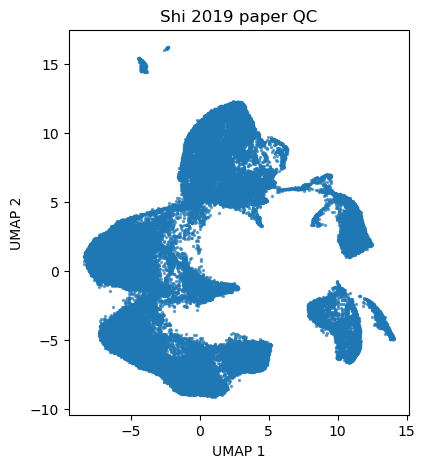

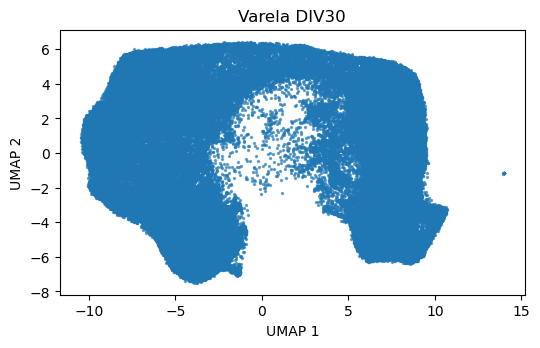

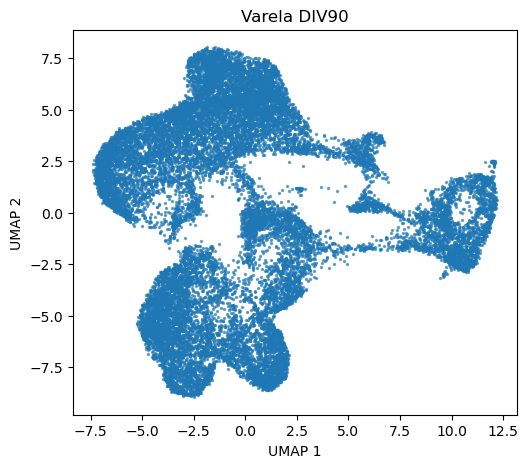

In [26]:
def plot_umap(adata, title, color_by=None, s=2, alpha=0.6):
    umap = adata.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=(6, 5))
    if color_by and color_by in adata.obs:
        values = adata.obs[color_by].astype("category")
        codes = values.cat.codes
        scatter = ax.scatter(umap[:, 0], umap[:, 1], c=codes, s=s, alpha=alpha, cmap="tab20")
        ax.set_title(f"{title} colored by {color_by}")
    else:
        ax.scatter(umap[:, 0], umap[:, 1], s=s, alpha=alpha)
        ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal", adjustable="box")
    return fig, ax

plot_umap(adatas["shi_2019_paper_qc"], "Shi 2019 paper QC")
plot_umap(adatas["varela_div30"], "Varela DIV30")
plot_umap(adatas["varela_div90"], "Varela DIV90")
plt.show()

## Working With One Object

Use the `adatas` dictionary for downstream analysis. Keys are:

- `shi_2019_paper_qc`
- `varela_div30`
- `varela_div90`

In [27]:
adata = adatas["varela_div30"]
print(adata)
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))

AnnData object with n_obs × n_vars = 90631 × 18082 backed at '/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/python_anndata/varela_div30.h5ad'
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters'
    var: 'feature_id'
    uns: 'conversion_manifest', 'seurat_assay', 'seurat_reduction', 'source_seurat_path'
    obsm: 'X_umap'
obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters']
var columns: ['feature_id']
